In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# (Optional) use NetworkX if present
# ----------------------------
try:
    import networkx as nx
    HAVE_NX = True
except Exception:
    HAVE_NX = False

# ----------------------------
# ER generator (adjacency list)
# ----------------------------
def er_graph_adjlist(n, z, rng):
    """
    Return adjacency list (list[list[int]]) for an ER G(n,p) with mean degree z.
    Uses networkx if available (faster). Node labels are 0..n-1.
    """
    p = z / (n - 1)
    if HAVE_NX:
        # Seed must be an int for networkx
        seed_int = int(rng.integers(2**31 - 1))
        G = nx.erdos_renyi_graph(n, p, seed=seed_int)
        return [list(G.neighbors(i)) for i in range(n)]
    else:
        # Fallback (O(n^2)); OK for small n
        adj = [[] for _ in range(n)]
        for i in range(n):
            r = rng.random(n - i - 1) < p
            js = np.where(r)[0] + i + 1
            for j in js:
                adj[i].append(j)
                adj[j].append(i)
        return adj

# ----------------------------
# Fast "ABM" final size via bond percolation
# ----------------------------
def final_size_percolation(adj, T, rng, seed_mode="single"):
    """
    Percolation-based final size: open each edge independently with prob T,
    then outbreak size is the size of the connected component reachable from seed
    using only open edges.
    """
    n = len(adj)
    # Build open-edge adjacency (sparse) by sampling each undirected edge once
    open_adj = [[] for _ in range(n)]
    visited_pairs = set()
    for i in range(n):
        for j in adj[i]:
            if j > i:  # undirected, handle once
                if rng.random() < T:
                    open_adj[i].append(j)
                    open_adj[j].append(i)

    if seed_mode == "single":
        seed = int(rng.integers(n))
        # BFS from seed on open graph
        seen = np.zeros(n, dtype=bool)
        q = [seed]
        seen[seed] = True
        head = 0
        while head < len(q):
            u = q[head]
            head += 1
            for v in open_adj[u]:
                if not seen[v]:
                    seen[v] = True
                    q.append(v)
        return seen.sum() / n
    else:
        raise ValueError("Only seed_mode='single' supported here.")

# ----------------------------
# (Optional) Continuous-time Gillespie SIR (slower, for time traces)
# ----------------------------
def sir_gillespie_final(adj, beta, gamma, rng, seed_mode="single", time_trace=False):
    """
    Continuous-time SIR via event-driven simulation.
    Returns final infected fraction; optionally returns (t, I/N) trace.
    """
    n = len(adj)
    S = np.ones(n, dtype=bool)
    I = np.zeros(n, dtype=bool)
    R = np.zeros(n, dtype=bool)

    if seed_mode == "single":
        s = int(rng.integers(n))
        S[s] = False
        I[s] = True
    else:
        raise ValueError("Only single seed supported.")

    # Precompute neighbor lists
    Nbrs = adj

    t = 0.0
    t_hist = [0.0]
    I_hist = [I.sum() / n]

    # To compute SI edges quickly, keep a set of SI pairs (unordered)
    # For speed in Python, just recompute hazards on the fly for small graphs
    # (For large n, you’d want incremental bookkeeping.)
    while I.any():
        # total recovery rate
        rec_rate = gamma * I.sum()
        # total infection rate = beta * (# SI edges)
        # count SI edges by scanning infected nodes
        inf_edges = 0
        for u in np.where(I)[0]:
            for v in Nbrs[u]:
                if S[v]:  # susceptible neighbor
                    inf_edges += 1
        inf_rate = beta * inf_edges
        H = rec_rate + inf_rate
        if H <= 0:
            break

        # next event time
        dt = rng.exponential(1.0 / H)
        t += dt

        # which event
        if rng.random() < (inf_rate / H):
            # infection: pick one SI edge uniformly (approx; we do a random try loop)
            # A simple approach: loop until we find an SI edge
            while True:
                # pick a random infected node; then one of its neighbors
                u = int(np.random.choice(np.where(I)[0]))
                if Nbrs[u]:
                    v = int(np.random.choice(Nbrs[u]))
                    if S[v]:
                        # infect v
                        S[v] = False
                        I[v] = True
                        break
        else:
            # recovery: pick a random infected to recover
            u = int(np.random.choice(np.where(I)[0]))
            I[u] = False
            R[u] = True

        if time_trace:
            t_hist.append(t)
            I_hist.append(I.sum() / n)

    if time_trace:
        return R.sum() / n, np.array(t_hist), np.array(I_hist)
    else:
        return R.sum() / n

# ----------------------------
# Analytic final size on ER via generating functions
# ----------------------------
def final_size_ER_analytic(z, beta, gamma, tol=1e-10, maxit=10000):
    """
    For ER with mean degree z, continuous-time SIR (Poisson rates beta, gamma):
    Transmissibility T = beta/(beta+gamma).
    Solve u = 1 - T + T*exp(z(u-1)); final size S = 1 - exp(z(u-1)).
    """
    T = beta / (beta + gamma)
    if T <= 0:
        return 0.0
    # fixed-point iteration for u
    u = 1.0
    for _ in range(maxit):
        unew = 1 - T + T * np.exp(z * (u - 1.0))
        if abs(unew - u) < tol:
            u = unew
            break
        u = unew
    S = 1.0 - np.exp(z * (u - 1.0))
    return float(S)

# ----------------------------
# Experiment A: S(infty) vs beta (fixed z, gamma)
# ----------------------------
def figure_finalsize_vs_beta(n=3000, z=3.0, gamma=1.0,
                             betas=None, reps=50, seed=0,
                             use_gillespie=False,
                             out_png="sir_finalsize_vs_beta.png", dpi=320):
    rng = np.random.default_rng(seed)
    if betas is None:
        betas = np.linspace(0.05, 2.0, 30)

    # Analytic curve
    S_th = [final_size_ER_analytic(z, b, gamma) for b in betas]

    # ABM (percolation) estimates
    S_sim = []
    for b in betas:
        T = b / (b + gamma)
        vals = []
        for _ in range(reps):
            adj = er_graph_adjlist(n, z, rng)
            if use_gillespie:
                # Slow, but gives time traces if you want (set time_trace=True above)
                f = sir_gillespie_final(adj, b, gamma, rng, seed_mode="single", time_trace=False)
            else:
                f = final_size_percolation(adj, T, rng, seed_mode="single")
            vals.append(f)
        S_sim.append(np.mean(vals))

    # Plot
    plt.figure(figsize=(6.6, 4.4))
    plt.plot(betas, S_th, '-', label='Analytic (ER, GF solution)')
    plt.plot(betas, S_sim, 'o', ms=4, label='ABM (percolation) mean')
    # Threshold line: T z = 1  => beta/(beta+gamma) * z = 1
    # Solve for beta_c: (beta_c/(beta_c+gamma)) = 1/z  =>  beta_c = gamma / (z-1)
    beta_c = gamma / (z - 1.0) if z > 1 else np.inf
    plt.axvline(beta_c, color='k', ls='--', alpha=0.5,
                label=fr'threshold $\beta_c=\gamma/(z-1)\approx{beta_c:.2f}$')
    plt.xlabel(r'infection rate $\beta$  (with $\gamma=1$)')
    plt.ylabel(r'final outbreak size $S_\infty$')
    plt.title(fr'ER SIR: final size vs $\beta$ (mean degree $z={z}$, $n={n}$)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=dpi)
    plt.close()

# ----------------------------
# Experiment B: threshold slice vs z at fixed (beta,gamma)
# ----------------------------
def figure_threshold_vs_z(n=3000, beta=0.4, gamma=1.0,
                          Z=None, reps=60, seed=1,
                          out_png="sir_threshold_z_slice.png", dpi=320):
    rng = np.random.default_rng(seed)
    if Z is None:
        Z = np.linspace(0.5, 6.0, 23)

    # Analytic final sizes (and threshold mark)
    S_th = [final_size_ER_analytic(z, beta, gamma) for z in Z]
    # Simulated mean final sizes
    S_sim = []
    for z in Z:
        T = beta / (beta + gamma)
        vals = []
        for _ in range(reps):
            adj = er_graph_adjlist(n, z, rng)
            f = final_size_percolation(adj, T, rng, seed_mode="single")
            vals.append(f)
        S_sim.append(np.mean(vals))

    # Find analytic threshold z* s.t. T z* = 1
    T = beta / (beta + gamma)
    z_star = 1.0 / T

    plt.figure(figsize=(6.6, 4.4))
    plt.plot(Z, S_th, '-', label='Analytic (GF)')
    plt.plot(Z, S_sim, 'o', ms=4, label='ABM (percolation) mean')
    plt.axvline(z_star, color='k', ls='--', alpha=0.5,
                label=fr'analytic threshold $z^\ast=1/T\approx{z_star:.2f}$')
    plt.xlabel(r'mean degree $z$')
    plt.ylabel(r'final outbreak size $S_\infty$')
    plt.title(fr'ER SIR: final size vs $z$ ($\beta={beta}$, $\gamma={gamma}$, $n={n}$)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=dpi)
    plt.close()

# ----------------------------
# Run (tweak n/reps for speed/accuracy)
# ----------------------------
if __name__ == "__main__":
    # Figure A: S∞ vs beta (fix z=3, gamma=1)
    figure_finalsize_vs_beta(n=3000, z=3.0, gamma=1.0,
                             betas=np.linspace(0.05, 1.2, 22),
                             reps=40, seed=0,
                             use_gillespie=False,
                             out_png="sir_finalsize_vs_beta.png", dpi=300)

    # Figure B: S∞ vs z (fix beta=0.4, gamma=1)
    figure_threshold_vs_z(n=3000, beta=0.4, gamma=1.0,
                          Z=np.linspace(0.5, 6.0, 23),
                          reps=40, seed=1,
                          out_png="sir_threshold_z_slice.png", dpi=300)

    print("Done. Saved: sir_finalsize_vs_beta.png, sir_threshold_z_slice.png")


Done. Saved: sir_finalsize_vs_beta.png, sir_threshold_z_slice.png


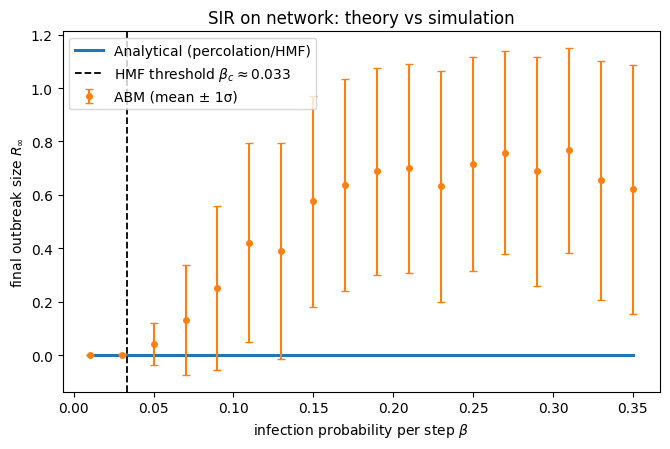

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# 1) Network generators
# ----------------------------
def er_adjlist(n, z, rng):
    """ER G(n,p) with mean degree z. Returns adjacency list."""
    p = z / (n - 1)
    adj = [[] for _ in range(n)]
    for i in range(n):
        # vectorized-ish Bernoulli per row
        r = rng.random(n - i - 1) < p
        js = np.nonzero(r)[0] + (i + 1)
        for j in js:
            adj[i].append(j); adj[j].append(i)
    return adj

def ba_adjlist(n, m0, m, rng):
    """
    Barabási–Albert: start with m0-clique, then attach each new node with m edges
    via linear preferential attachment. Returns adjacency list.
    """
    if m0 < m: m0 = m
    adj = [[] for _ in range(n)]
    # initial clique
    for i in range(m0):
        for j in range(i+1, m0):
            adj[i].append(j); adj[j].append(i)
    # preferential attachment via "stubs" list
    stubs = []
    for i in range(m0):
        stubs.extend([i]*len(adj[i]))
    for new in range(m0, n):
        # choose m distinct targets from stubs
        if len(stubs) == 0:
            # fallback to uniform if something degenerate happens
            targets = rng.choice(new, size=m, replace=False)
        else:
            targets = rng.choice(stubs, size=m, replace=False)
        targets = np.unique(targets)
        # if unique reduced below m, sample extra uniformly
        while len(targets) < m:
            add = rng.integers(0, new)
            if add not in targets:
                targets = np.append(targets, add)
        for t in targets:
            adj[new].append(int(t))
            adj[int(t)].append(new)
        # update stubs
        stubs.extend([new]*m)
        for t in targets:
            stubs.append(int(t))
    return adj

# ----------------------------
# 2) SIR ABM simulation
# ----------------------------
def sir_run(adj, beta=0.05, mu=0.2, rng=None, seed_mode="single"):
    """
    Discrete-time SIR on a static graph (adjacency list).
    Returns final attack rate R_inf (fraction ever infected).
    """
    if rng is None: rng = np.random.default_rng()
    n = len(adj)
    S = np.ones(n, dtype=bool)
    I = np.zeros(n, dtype=bool)
    R = np.zeros(n, dtype=bool)

    # initial seed
    if seed_mode == "single":
        s = rng.integers(0, n)
        I[s] = True; S[s] = False
    else:
        raise ValueError("Only seed_mode='single' supported in this minimal demo")

    ever_infected = I.copy()

    while True:
        # recoveries
        rec = (rng.random(I.sum()) < mu) if I.any() else np.array([], dtype=bool)
        if I.any():
            infected_idx = np.where(I)[0]
            recovering = infected_idx[rec]
            if recovering.size:
                I[recovering] = False
                R[recovering] = True

        # infections
        new_inf = []
        if I.any():
            for i in np.where(I)[0]:
                if not adj[i]:  # isolated
                    continue
                nbrs = np.array(adj[i], dtype=int)
                susceptible_nbrs = nbrs[S[nbrs]]
                if susceptible_nbrs.size:
                    # each S neighbor infected independently with prob beta
                    toss = rng.random(susceptible_nbrs.size) < beta
                    if toss.any():
                        new_inf.extend(susceptible_nbrs[toss])
        if new_inf:
            new_inf = np.unique(new_inf)
            I[new_inf] = True
            S[new_inf] = False
            ever_infected[new_inf] = True

        if not I.any():  # extinct
            break

    return ever_infected.mean()

def sir_sweep(adj, betas, mu=0.2, reps=30, rng=None):
    if rng is None: rng = np.random.default_rng()
    means, stds = [], []
    for b in betas:
        vals = [sir_run(adj, beta=b, mu=mu, rng=rng) for _ in range(reps)]
        means.append(np.mean(vals)); stds.append(np.std(vals))
    return np.array(means), np.array(stds)

# ----------------------------
# 3) Analytical R_inf via percolation mapping
# ----------------------------
def degree_hist(adj):
    deg = np.array([len(nbrs) for nbrs in adj], dtype=int)
    k_vals, counts = np.unique(deg, return_counts=True)
    pk = counts / counts.sum()
    return k_vals, pk

def genfunc_coeffs(k, pk):
    z1 = np.sum(k*pk)
    # arrays for G0 and G1
    return z1

def final_size_theory(adj, beta, mu):
    """
    Compute R_inf^theory via bond percolation mapping:
        T = beta / (beta + mu)   (approx for continuous-time SIR)
        u = 1 - T + T * G1(u),   R = 1 - G0(u)
    using the empirical degree distribution of the given graph.
    """
    k, pk = degree_hist(adj)
    z1 = (k*pk).sum()
    if z1 == 0: 
        return 0.0

    # G0(x) = sum_k pk x^k
    # G1(x) = sum_k k pk / z1 * x^{k-1}
    def G0(x): return np.sum(pk * (x**k))
    def G1(x): 
        w = k*pk / z1
        # handle k=0 term safely (x**(-1) would appear if k=0)
        return np.sum(w[k>0] * (x**(k[k>0] - 1)))

    T = beta / (beta + mu + 1e-12)  # avoid 0/0

    # fixed-point solve u = 1 - T + T G1(u)
    u = 1.0
    for _ in range(200):
        u_new = 1 - T + T * G1(u)
        if abs(u_new - u) < 1e-10:
            u = u_new; break
        u = u_new
    R_theory = 1.0 - G0(u)
    return float(np.clip(R_theory, 0.0, 1.0))

def theory_curve(adj, betas, mu=0.2):
    return np.array([final_size_theory(adj, b, mu) for b in betas])

# ----------------------------
# 4) Demo: choose a network, compare theory vs ABM
# ----------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(1)

    # ---- pick ONE network ----
    # (A) ER (n ~ 400–2000 is fine)
    n, z = 1200, 6.0
    adj = er_adjlist(n, z, rng)

    # # (B) BA (scale-free). m controls mean degree (~2m)
    # n, m0, m = 2000, 5, 3
    # adj = ba_adjlist(n, m0, m, rng)

    # sweep beta values
    mu = 0.2
    betas = np.linspace(0.01, 0.35, 18)

    # ABM (Monte Carlo)
    sim_mean, sim_std = sir_sweep(adj, betas, mu=mu, reps=25, rng=rng)

    # Analytical
    th_curve = theory_curve(adj, betas, mu=mu)

    # quick threshold estimate from HMF (heterogeneous mean-field)
    k, pk = degree_hist(adj)
    k1 = (k*pk).sum()
    k2 = (k*k*pk).sum()
    # continuous-time threshold beta_c/mu = <k> / (<k^2>-<k>)
    beta_c = mu * k1 / max(k2 - k1, 1e-12)

    # --------- plot ----------
    x = betas
    plt.figure(figsize=(6.8, 4.6))
    plt.plot(x, th_curve, '-', lw=2.2, label='Analytical (percolation/HMF)')
    plt.errorbar(x, sim_mean, yerr=sim_std, fmt='o', ms=4, capsize=3, label='ABM (mean ± 1σ)')
    plt.axvline(beta_c, color='k', ls='--', lw=1.3, label=fr'HMF threshold $\beta_c\approx{beta_c:.3f}$')
    plt.xlabel(r'infection probability per step $\beta$')
    plt.ylabel(r'final outbreak size $R_\infty$')
    plt.title('SIR on network: theory vs simulation')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ---- analytic final size for ER (Poisson degree mean z) ----
def R_inf_ER(beta, z, tau=1, tol=1e-12, maxit=10_000):
    """
    Final epidemic size R_inf for SIR on ER(z) using bond-percolation mapping.
    beta : per-contact infection probability per step
    z    : ER mean degree
    tau  : infectious period (integer number of steps). T = 1 - (1-beta)^tau
    """
    T = 1.0 - (1.0 - beta)**tau
    # Fixed-point: u = 1 - T + T * exp[z(u-1)]
    # Start near 1 (no outbreak) and iterate
    u = 1.0
    for _ in range(maxit):
        u_new = 1.0 - T + T * np.exp(z*(u - 1.0))
        if abs(u_new - u) < tol:
            u = u_new
            break
        u = u_new
    # Final size: R_inf = 1 - exp[z(u-1)]
    return 1.0 - np.exp(z*(u - 1.0))

# ---- example overlay with your ABM statistics you already computed ----
# Suppose you have:
#   betas     -> array of beta values used in ABM
#   abm_mean  -> mean final infected fraction across runs for each beta
#   abm_std   -> std dev across runs (for error bars)
#   z         -> ER mean degree used in ABM
#   tau       -> infectious period in steps used in ABM (tau=1 if immediate recovery next step)

def plot_theory_vs_abm(betas, abm_mean, abm_std, z, tau=1, out_png="sir_theory_vs_abm.png"):
    # analytic curve
    R_th = np.array([R_inf_ER(b, z, tau=tau) for b in betas])
    beta_c = 1.0 - (1.0 - 1.0/z)**(1.0/tau)  # invert T_c=1/z to beta_c with given tau

    plt.figure(figsize=(6.9, 4.2))
    plt.plot(betas, R_th, label="Analytical (percolation)", lw=2)
    plt.axvline(beta_c, ls="--", color="k", label=fr"HMF threshold $\beta_c \approx {beta_c:.3f}$")
    plt.errorbar(betas, abm_mean, yerr=abm_std, fmt="o", capsize=3, label="ABM (mean ± 1σ)")
    plt.xlabel(r"infection probability per step $\beta$")
    plt.ylabel(r"final outbreak size $R_\infty$")
    plt.title("SIR on ER network: analytic vs ABM")
    plt.ylim(-0.02, 1.02)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.show()


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.integrate import solve_ivp

# ----------------------------
# Helpers: ER and WS generators
# ----------------------------
def er_graph(n, z, rng):
    p = z / (n - 1)
    return nx.erdos_renyi_graph(n, p, seed=int(rng.integers(1 << 30)))

def ws_graph(n, k, rewiring_p, rng):
    # k must be even; if not, bump to next even
    if k % 2 == 1: k += 1
    return nx.watts_strogatz_graph(n, k, rewiring_p, seed=int(rng.integers(1 << 30)))

# --------------------------------------------
# ABM: discrete-time SIR on a static graph G
# --------------------------------------------
def sir_abm(G, beta, gamma, I0_frac=0.01, dt=0.05, t_max=20.0, rng=None):
    """
    Per time-step:
      - Each SI edge transmits with prob tau = 1 - exp(-beta*dt)
      - Each infected recovers with prob mu = 1 - exp(-gamma*dt)
    Returns t, S(t), I(t), R(t).
    """
    if rng is None: rng = np.random.default_rng()
    n = G.number_of_nodes()
    nodes = np.array(G.nodes())
    # states: 0=S, 1=I, 2=R
    state = np.zeros(n, dtype=np.int8)
    # seed infected
    I0 = max(1, int(round(I0_frac * n)))
    infected_idx = rng.choice(n, size=I0, replace=False)
    state[infected_idx] = 1

    tau = 1.0 - np.exp(-beta * dt)
    mu  = 1.0 - np.exp(-gamma * dt)

    ts, Ss, Is, Rs = [], [], [], []
    t = 0.0
    while t <= t_max and np.any(state == 1):
        ts.append(t)
        Sfrac = np.mean(state == 0); Ifrac = np.mean(state == 1); Rfrac = 1.0 - Sfrac - Ifrac
        Ss.append(Sfrac); Is.append(Ifrac); Rs.append(Rfrac)

        # recoveries
        I_nodes = np.where(state == 1)[0]
        if I_nodes.size > 0:
            recov = rng.random(I_nodes.size) < mu
            state[I_nodes[recov]] = 2

        # transmissions
        I_nodes = np.where(state == 1)[0]
        if I_nodes.size > 0:
            # For each infected node, try to infect each susceptible neighbor
            for i in I_nodes:
                nbrs = list(G.neighbors(int(nodes[i])))
                if not nbrs: 
                    continue
                # Map neighbor labels to indices
                # Build a dict once per run for speed
            # Build label->index map once
            break_map = False
        # Build label->index map (outside loop for efficiency)
        label_to_idx = {int(nodes[idx]): idx for idx in range(n)}
        I_nodes = np.where(state == 1)[0]
        for i in I_nodes:
            for v in G.neighbors(int(nodes[i])):
                j = label_to_idx[int(v)]
                if state[j] == 0:
                    if rng.random() < tau:
                        state[j] = 1

        t += dt

    # append final time-point
    ts.append(t)
    Sfrac = np.mean(state == 0); Ifrac = np.mean(state == 1); Rfrac = 1.0 - Sfrac - Ifrac
    Ss.append(Sfrac); Is.append(Ifrac); Rs.append(Rfrac)
    return np.array(ts), np.array(Ss), np.array(Is), np.array(Rs)

# ---------------------------------------------------------
# Edge-based (configuration model) analytic ODE for ER
# ---------------------------------------------------------
def ebcm_er(beta, gamma, z, I0_frac=1e-4, t_span=(0,20), t_eval=None):
    """
    Edge-based SIR for Poisson degree (ER): G0 = G1 = exp(z*(x-1)).
    Variables: theta(t), phi_R(t), R(t).
    S(t)=G0(theta)=exp(z*(theta-1)), I(t)=1-S-R.
    """
    if t_eval is None:
        t_eval = np.linspace(t_span[0], t_span[1], 800)

    def G0(x): return np.exp(z*(x-1.0))
    def G1(x): return np.exp(z*(x-1.0))  # same for Poisson

    # Small initial infection -> theta slightly below 1; use consistent perturbation
    eps = I0_frac
    theta0 = 1.0 - 1e-8  # almost 1; dynamics will ignite if R0>1
    phiR0  = 0.0
    # R(0) consistent with I0 only approximately; we set R(0)=0
    R0 = 0.0
    y0 = [theta0, phiR0, R0]

    def rhs(t, y):
        theta, phiR, R = y
        S = G0(theta)
        phiI = theta - G1(theta) - phiR
        dtheta = -beta * phiI
        dphiR  =  gamma * phiI
        dR     =  gamma * (1.0 - S - R)
        return [dtheta, dphiR, dR]

    sol = solve_ivp(rhs, t_span, y0, t_eval=t_eval, rtol=1e-7, atol=1e-9)
    theta, phiR, R = sol.y
    S = np.exp(z*(theta-1.0))
    I = 1.0 - S - R
    return sol.t, S, I, R

# ---------------------------
# Plotting helpers
# ---------------------------
def plot_compare_time(t_abm, S_abm, I_abm, R_abm,
                      t_an,  S_an,  I_an,  R_an,
                      out_png):
    plt.figure(figsize=(7.4,4.8))
    plt.plot(t_abm, S_abm, '-',  label='ABM S')
    plt.plot(t_abm, I_abm, '-',  label='ABM I')
    plt.plot(t_abm, R_abm, '-',  label='ABM R')
    plt.plot(t_an,  S_an,  '--', label='Analytic S (EBCM)')
    plt.plot(t_an,  I_an,  '--', label='Analytic I (EBCM)')
    plt.plot(t_an,  R_an,  '--', label='Analytic R (EBCM)')
    plt.xlabel('time')
    plt.ylabel('fraction')
    plt.title('SIR on ER: ABM vs edge-based analytic')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_png, dpi=300)
    plt.close()

# ---------------------------
# Run: ER (match) and WS (mismatch)
# ---------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)

    # Common epidemic params
    beta  = 0.25     # per-edge infection rate
    gamma = 0.10     # recovery rate
    I0    = 0.01     # initial infected fraction
    t_max = 40.0
    dt    = 0.05

    # ---- Case 1: ER graph (analytic should match) ----
    n = 4000
    z = 8.0
    G_er = er_graph(n, z, rng)
    t1, S1, I1, R1 = sir_abm(G_er, beta, gamma, I0_frac=I0, dt=dt, t_max=t_max, rng=rng)
    tA, SA, IA, RA = ebcm_er(beta, gamma, z, I0_frac=I0, t_span=(0,t_max))
    plot_compare_time(t1, S1, I1, R1, tA, SA, IA, RA, out_png="sir_er_time.png")

    # ---- Case 2: WS graph (clustered; analytics should deviate) ----
    # Same mean degree ~ z, but with clustering via low rewiring probability
    k_ws = int(round(z)) if int(round(z))%2==0 else int(round(z))+1
    G_ws = ws_graph(n, k_ws, rewiring_p=0.05, rng=rng)
    t2, S2, I2, R2 = sir_abm(G_ws, beta, gamma, I0_frac=I0, dt=dt, t_max=t_max, rng=rng)
    # Reuse ER analytic curves (same z) to illustrate mismatch
    plot_compare_time(t2, S2, I2, R2, tA, SA, IA, RA, out_png="sir_ws_time.png")

    print("Wrote: sir_er_time.png, sir_ws_time.png")


Wrote: sir_er_time.png, sir_ws_time.png


In [4]:
# ===================== SIR on networks: CM analytics vs ABM =====================
# Requirements: networkx, numpy, matplotlib
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------
# Utilities: degree sequence & p_k
# ---------------------------
def poisson_degree_sequence(n, z, rng):
    """Draw a Poisson(z) degree sequence for CM."""
    seq = rng.poisson(z, size=n).tolist()
    # Ensure even sum for a valid stub pairing (adjust if needed)
    if sum(seq) % 2 == 1:
        seq[rng.integers(0, n)] += 1
    return seq

def pk_from_degree_sequence(seq):
    """Return (k_vals, p_k) from a degree sequence."""
    degs = np.array(seq, dtype=int)
    k_vals, counts = np.unique(degs, return_counts=True)
    p_k = counts / counts.sum()
    return k_vals, p_k

# ---------------------------
# Generating functions for CM final size (Newman 2002)
# ---------------------------
def G0(x, k_vals, p_k):
    return np.sum(p_k * (x ** k_vals))

def G1(x, k_vals, p_k):
    k_mean = np.sum(k_vals * p_k)
    if k_mean == 0: 
        return 1.0
    return np.sum((k_vals * p_k / k_mean) * (x ** (k_vals - 1)))

def G1_prime_at_1(k_vals, p_k):
    """G1'(1) = <k(k-1)>/<k>."""
    k = k_vals
    pk = p_k
    num = np.sum(k * (k - 1) * pk)
    den = np.sum(k * pk)
    return 0.0 if den == 0 else num / den

def final_size_CM(T, k_vals, p_k, tol=1e-12, maxit=1000):
    """
    Solve u = G1(1 - T + T u) for u in [0,1], then S = 1 - G0(1 - T + T u).
    Returns final outbreak fraction S (giant component of T-bond-percolated CM).
    """
    q = 1.0 - T  # edge survives (no transmission) prob in bond percolation complement
    # Fixed-point iterate for u
    u = 1.0
    for _ in range(maxit):
        u_new = G1(q + T * u, k_vals, p_k)
        if abs(u_new - u) < tol:
            u = u_new
            break
        u = u_new
    S = 1.0 - G0(q + T * u, k_vals, p_k)
    return max(0.0, min(1.0, S))

def R0_CM(T, k_vals, p_k):
    """Basic reproduction number on CM: R0 = T * G1'(1) = T * (<k(k-1)>/<k>)."""
    return T * G1_prime_at_1(k_vals, p_k)

# ---------------------------
# ABM via bond-percolation BFS (matches CM final-size theory)
# ---------------------------
def percolation_reachable_fraction_CM(seq, T, rng, reps=50):
    """
    Build one CM graph from 'seq', percolate each edge with prob T, 
    choose a random seed, BFS on percolated edges, record reached fraction.
    Repeat 'reps' times on NEW CM graphs to average out.
    """
    n = len(seq)
    fracs = []
    for _ in range(reps):
        # CM multigraph -> simple graph (remove parallel edges/self-loops)
        Gm = nx.configuration_model(seq, create_using=None, seed=rng.integers(1 << 31))
        Gs = nx.Graph(Gm)             # collapse multiedges
        Gs.remove_edges_from(nx.selfloop_edges(Gs))
        # Percolate edges
        H = nx.Graph()
        H.add_nodes_from(Gs.nodes())
        for u, v in Gs.edges():
            if rng.random() < T:
                H.add_edge(u, v)
        # Pick seed and get its percolated component size
        seed = rng.integers(0, n)
        comp_size = len(nx.node_connected_component(H, seed))
        fracs.append(comp_size / n)
    return float(np.mean(fracs)), float(np.std(fracs))

# ---------------------------
# Optional time dynamics: discrete-time SIR (β per contact, μ recovery prob)
# ---------------------------
def SIR_discrete_time(G, beta, mu, rng, seed=None, max_steps=2000):
    """
    Synchronous SIR on graph G.
    beta: per-contact infection prob per step
    mu: per-step recovery prob
    seed: single initial infected node index
    Returns arrays S(t), I(t), R(t) as fractions.
    """
    n = G.number_of_nodes()
    if seed is None:
        seed = rng.integers(0, n)
    S = np.ones(n, dtype=bool)
    I = np.zeros(n, dtype=bool)
    R = np.zeros(n, dtype=bool)
    S[seed] = False
    I[seed] = True

    S_hist, I_hist, R_hist = [], [], []
    for _ in range(max_steps):
        S_hist.append(S.mean())
        I_hist.append(I.mean())
        R_hist.append(R.mean())

        if not I.any():
            break

        # infections
        newI = np.zeros(n, dtype=bool)
        for u in np.where(I)[0]:
            nbrs = list(G.neighbors(u))
            for v in nbrs:
                if S[v] and (rng.random() < beta):
                    newI[v] = True

        # recoveries
        recov = (rng.random(n) < mu) & I

        # update states
        I = (I | newI) & (~recov)
        R = R | recov
        S = ~(I | R)

    return np.array(S_hist), np.array(I_hist), np.array(R_hist)

# ---------------------------
# Figures
# ---------------------------
def figure_final_size_CM(z=4.0, n=5000, T_grid=None, reps=30, rng=None, out="sir_cm_finalsize.png"):
    if rng is None: rng = np.random.default_rng(0)
    if T_grid is None: T_grid = np.linspace(0.02, 0.6, 30)

    # CM degree sequence & pk
    seq = poisson_degree_sequence(n, z, rng)
    k_vals, p_k = pk_from_degree_sequence(seq)

    # Analytic curve
    S_analytic = [final_size_CM(T, k_vals, p_k) for T in T_grid]

    # Monte-Carlo percolation points
    S_emp, S_err = [], []
    for T in T_grid:
        m, s = percolation_reachable_fraction_CM(seq, T, rng, reps=reps)
        S_emp.append(m); S_err.append(s)

    # Plot
    plt.figure(figsize=(6.8, 4.6))
    plt.plot(T_grid, S_analytic, '-', label='Analytic final size (CM, generating functions)')
    plt.errorbar(T_grid, S_emp, yerr=S_err, fmt='o', ms=4, capsize=3, label='Monte-Carlo (percolation BFS)')
    # Threshold line R0=1 location
    T_star = 1.0 / G1_prime_at_1(k_vals, p_k) if G1_prime_at_1(k_vals, p_k) > 0 else np.nan
    if np.isfinite(T_star):
        plt.axvline(T_star, color='k', ls='--', lw=1, label=fr'$T_c=1/G_1^\prime(1)\approx{T_star:.3f}$')
    plt.xlabel('Transmissibility $T$')
    plt.ylabel('Final epidemic size (fraction of population)')
    plt.title(fr'CM (Poisson, $z={z}$): analytic vs Monte-Carlo')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out, dpi=300); plt.close()

def figure_final_size_WS(z=4.0, n=5000, T_grid=None, k=6, p_rewire=0.1, reps=30, rng=None, out="sir_ws_finalsize.png"):
    """
    Same T sweep but on a Watts–Strogatz graph to show deviation from CM analytics (clustering).
    For a fair visual comparison, we overlay the CM analytic curve computed for Poisson z≈k.
    """
    if rng is None: rng = np.random.default_rng(1)
    if T_grid is None: T_grid = np.linspace(0.02, 0.6, 30)

    # "Reference" CM analytics for similar mean degree (use z ~ k)
    # Build a Poisson CM once to compute pk and analytic curve
    seq_ref = poisson_degree_sequence(n, z, rng)
    k_vals_ref, p_k_ref = pk_from_degree_sequence(seq_ref)
    S_analytic = [final_size_CM(T, k_vals_ref, p_k_ref) for T in T_grid]

    # WS Monte-Carlo percolation (build new WS each rep for averaging)
    S_emp = []; S_err = []
    for T in T_grid:
        vals = []
        for _ in range(reps):
            G = nx.watts_strogatz_graph(n, k, p_rewire, seed=rng.integers(1 << 31))
            # Percolate edges
            H = nx.Graph()
            H.add_nodes_from(G.nodes())
            for u, v in G.edges():
                if rng.random() < T:
                    H.add_edge(u, v)
            # Seed component size
            seed = rng.integers(0, n)
            vals.append(len(nx.node_connected_component(H, seed)) / n)
        S_emp.append(np.mean(vals)); S_err.append(np.std(vals))

    # Plot
    plt.figure(figsize=(6.8, 4.6))
    plt.plot(T_grid, S_analytic, '-', label='CM analytic (reference)')
    plt.errorbar(T_grid, S_emp, yerr=S_err, fmt='o', ms=4, capsize=3,
                 label=fr'WS Monte-Carlo ($k={k},\,p={p_rewire}$)')
    plt.xlabel('Transmissibility $T$')
    plt.ylabel('Final epidemic size')
    plt.title('Watts–Strogatz (no simple closed form): deviation from CM analytic curve')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out, dpi=300); plt.close()

def figure_time_series_CM(z=4.0, n=5000, beta=0.04, mu=0.06, rng=None, out="sir_cm_timeseries.png"):
    """
    One SIR run on a CM graph; plot S(t), I(t), R(t) to show the epidemic wave.
    (This is for narrative; there is no simple CM closed-form for the transient.)
    """
    if rng is None: rng = np.random.default_rng(2)
    seq = poisson_degree_sequence(n, z, rng)
    Gm = nx.configuration_model(seq, seed=rng.integers(1 << 31))
    G = nx.Graph(Gm)
    G.remove_edges_from(nx.selfloop_edges(G))

    S, I, R = SIR_discrete_time(G, beta=beta, mu=mu, rng=rng)

    t = np.arange(len(S))
    plt.figure(figsize=(6.8, 4.2))
    plt.plot(t, S, label='S(t)')
    plt.plot(t, I, label='I(t)')
    plt.plot(t, R, label='R(t)')
    plt.xlabel('time steps')
    plt.ylabel('fraction of population')
    plt.title(fr'One SIR realization on CM (Poisson $z={z}$)')
    plt.legend()
    plt.tight_layout()
    plt.savefig(out, dpi=300); plt.close()

# ---------------------------
# Run everything (tune n/reps for speed/quality)
# ---------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    figure_final_size_CM(z=4.0, n=5000, T_grid=np.linspace(0.02, 0.6, 24), reps=25, rng=rng,
                         out="sir_cm_finalsize.png")
    figure_final_size_WS(z=4.0, n=5000, T_grid=np.linspace(0.02, 0.6, 24), k=6, p_rewire=0.1, reps=20, rng=rng,
                         out="sir_ws_finalsize.png")
    figure_time_series_CM(z=4.0, n=5000, beta=0.04, mu=0.06, rng=rng,
                          out="sir_cm_timeseries.png")


ValueError: 1532125540 cannot be used to generate a random.Random instance

In [5]:
# ===================== SIR on networks: CM analytics vs ABM =====================
# Requirements: networkx, numpy, matplotlib
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------
# Helpers: robust seed adaptor for NetworkX
# ---------------------------
def pyseed(rng):
    """Return a plain Python int seed compatible with NetworkX."""
    return int(rng.integers(0, 2**32 - 1))

# ---------------------------
# Utilities: degree sequence & p_k
# ---------------------------
def poisson_degree_sequence(n, z, rng):
    """Draw a Poisson(z) degree sequence for CM."""
    seq = rng.poisson(z, size=n).tolist()
    if sum(seq) % 2 == 1:  # ensure even sum
        seq[rng.integers(0, n)] += 1
    return seq

def pk_from_degree_sequence(seq):
    """Return (k_vals, p_k) from a degree sequence."""
    degs = np.array(seq, dtype=int)
    k_vals, counts = np.unique(degs, return_counts=True)
    p_k = counts / counts.sum()
    return k_vals, p_k

# ---------------------------
# Generating functions for CM final size (Newman 2002)
# ---------------------------
def G0(x, k_vals, p_k):
    return np.sum(p_k * (x ** k_vals))

def G1(x, k_vals, p_k):
    k_mean = np.sum(k_vals * p_k)
    if k_mean == 0:
        return 1.0
    return np.sum((k_vals * p_k / k_mean) * (x ** (k_vals - 1)))

def G1_prime_at_1(k_vals, p_k):
    """G1'(1) = <k(k-1)>/<k>."""
    k = k_vals
    pk = p_k
    num = np.sum(k * (k - 1) * pk)
    den = np.sum(k * pk)
    return 0.0 if den == 0 else num / den

def final_size_CM(T, k_vals, p_k, tol=1e-12, maxit=1000):
    """
    Solve u = G1(1 - T + T u) for u in [0,1], then S = 1 - G0(1 - T + T u).
    Returns final outbreak fraction S.
    """
    q = 1.0 - T
    u = 1.0
    for _ in range(maxit):
        u_new = G1(q + T * u, k_vals, p_k)
        if abs(u_new - u) < tol:
            u = u_new
            break
        u = u_new
    S = 1.0 - G0(q + T * u, k_vals, p_k)
    return max(0.0, min(1.0, S))

def R0_CM(T, k_vals, p_k):
    """Basic reproduction number on CM: R0 = T * G1'(1)."""
    return T * G1_prime_at_1(k_vals, p_k)

# ---------------------------
# ABM via bond-percolation BFS (matches CM final-size theory)
# ---------------------------
def percolation_reachable_fraction_CM(seq, T, rng, reps=30):
    """
    Build a CM graph from 'seq' each repetition, percolate edges with prob T,
    start from a random seed node, and measure reached fraction (component size/n).
    Returns (mean, std) over reps.
    """
    n = len(seq)
    fracs = []
    for _ in range(reps):
        # CM multigraph -> simple graph (remove multiedges/self-loops)
        Gm = nx.configuration_model(seq, seed=pyseed(rng))
        Gs = nx.Graph(Gm)  # collapse parallel edges
        Gs.remove_edges_from(nx.selfloop_edges(Gs))

        # Percolate edges
        H = nx.Graph()
        H.add_nodes_from(Gs.nodes())
        r = rng.random(Gs.number_of_edges())
        for (e, (u, v)) in enumerate(Gs.edges()):
            if r[e] < T:
                H.add_edge(u, v)

        # Seed component size
        seed_node = int(rng.integers(0, n))
        comp_size = len(nx.node_connected_component(H, seed_node))
        fracs.append(comp_size / n)

    return float(np.mean(fracs)), float(np.std(fracs))

# ---------------------------
# Optional time dynamics: discrete-time SIR (β per contact, μ recovery)
# ---------------------------
def SIR_discrete_time(G, beta, mu, rng, seed=None, max_steps=2000):
    """
    Synchronous SIR on graph G.
    beta: per-contact infection prob per step
    mu: per-step recovery prob
    seed: single initial infected node index
    Returns arrays S(t), I(t), R(t) as fractions.
    """
    n = G.number_of_nodes()
    if seed is None:
        seed = int(rng.integers(0, n))

    S = np.ones(n, dtype=bool)
    I = np.zeros(n, dtype=bool)
    R = np.zeros(n, dtype=bool)
    S[seed] = False
    I[seed] = True

    S_hist, I_hist, R_hist = [], [], []
    for _ in range(max_steps):
        S_hist.append(S.mean()); I_hist.append(I.mean()); R_hist.append(R.mean())
        if not I.any():
            break

        # infections
        newI = np.zeros(n, dtype=bool)
        for u in np.where(I)[0]:
            for v in G[u]:
                if S[v] and (rng.random() < beta):
                    newI[v] = True

        # recoveries
        recov = (rng.random(n) < mu) & I

        # update
        I = (I | newI) & (~recov)
        R = R | recov
        S = ~(I | R)

    return np.array(S_hist), np.array(I_hist), np.array(R_hist)

# ---------------------------
# Figures
# ---------------------------
def figure_final_size_CM(z=4.0, n=5000, T_grid=None, reps=25, rng=None, out="sir_cm_finalsize.png"):
    if rng is None: rng = np.random.default_rng(0)
    if T_grid is None: T_grid = np.linspace(0.02, 0.6, 24)

    # CM degree sequence & pk
    seq = poisson_degree_sequence(n, z, rng)
    k_vals, p_k = pk_from_degree_sequence(seq)

    # Analytic curve
    S_analytic = [final_size_CM(T, k_vals, p_k) for T in T_grid]

    # Monte-Carlo percolation points
    S_emp, S_err = [], []
    for T in T_grid:
        m, s = percolation_reachable_fraction_CM(seq, T, rng, reps=reps)
        S_emp.append(m); S_err.append(s)

    # Plot
    plt.figure(figsize=(6.8, 4.6))
    plt.plot(T_grid, S_analytic, '-', label='Analytic final size (CM)')
    plt.errorbar(T_grid, S_emp, yerr=S_err, fmt='o', ms=4, capsize=3, label='Monte-Carlo (percolation BFS)')
    # Threshold line R0=1 location
    g1p = G1_prime_at_1(k_vals, p_k)
    if g1p > 0:
        T_star = 1.0 / g1p
        plt.axvline(T_star, color='k', ls='--', lw=1, label=fr'$T_c=1/G_1^\prime(1)\approx{T_star:.3f}$')
    plt.xlabel('Transmissibility $T$'); plt.ylabel('Final epidemic size')
    plt.title(fr'CM (Poisson, $z={z}$): analytic vs Monte-Carlo')
    plt.legend(); plt.tight_layout(); plt.savefig(out, dpi=300); plt.close()
    print(f"[saved] {out}")

def figure_final_size_WS(z=4.0, n=5000, T_grid=None, k=6, p_rewire=0.1, reps=20, rng=None, out="sir_ws_finalsize.png"):
    """
    Same T sweep but on a Watts–Strogatz graph to show deviation from CM analytics (clustering).
    We overlay the CM analytic curve computed for Poisson mean z.
    """
    if rng is None: rng = np.random.default_rng(1)
    if T_grid is None: T_grid = np.linspace(0.02, 0.6, 24)

    # Reference CM analytic
    seq_ref = poisson_degree_sequence(n, z, rng)
    k_vals_ref, p_k_ref = pk_from_degree_sequence(seq_ref)
    S_analytic = [final_size_CM(T, k_vals_ref, p_k_ref) for T in T_grid]

    # WS Monte-Carlo percolation
    S_emp, S_err = [], []
    for T in T_grid:
        vals = []
        for _ in range(reps):
            G = nx.watts_strogatz_graph(n, k, p_rewire, seed=pyseed(rng))
            H = nx.Graph(); H.add_nodes_from(G.nodes())
            r = rng.random(G.number_of_edges())
            for (e, (u, v)) in enumerate(G.edges()):
                if r[e] < T:
                    H.add_edge(u, v)
            seed_node = int(rng.integers(0, n))
            vals.append(len(nx.node_connected_component(H, seed_node)) / n)
        S_emp.append(np.mean(vals)); S_err.append(np.std(vals))

    # Plot
    plt.figure(figsize=(6.8, 4.6))
    plt.plot(T_grid, S_analytic, '-', label='CM analytic (reference)')
    plt.errorbar(T_grid, S_emp, yerr=S_err, fmt='o', ms=4, capsize=3,
                 label=fr'WS Monte-Carlo ($k={k},\,p={p_rewire}$)')
    plt.xlabel('Transmissibility $T$'); plt.ylabel('Final epidemic size')
    plt.title('Watts–Strogatz: deviation from CM analytic due to clustering')
    plt.legend(); plt.tight_layout(); plt.savefig(out, dpi=300); plt.close()
    print(f"[saved] {out}")

def figure_time_series_CM(z=4.0, n=5000, beta=0.04, mu=0.06, rng=None, out="sir_cm_timeseries.png"):
    """
    One SIR run on a CM graph; plot S(t), I(t), R(t).
    (No simple closed form for transient; this is for narrative.)
    """
    if rng is None: rng = np.random.default_rng(2)
    seq = poisson_degree_sequence(n, z, rng)
    Gm = nx.configuration_model(seq, seed=pyseed(rng))
    G = nx.Graph(Gm); G.remove_edges_from(nx.selfloop_edges(G))

    S, I, R = SIR_discrete_time(G, beta=beta, mu=mu, rng=rng)
    t = np.arange(len(S))
    plt.figure(figsize=(6.8, 4.2))
    plt.plot(t, S, label='S(t)'); plt.plot(t, I, label='I(t)'); plt.plot(t, R, label='R(t)')
    plt.xlabel('time steps'); plt.ylabel('fraction of population')
    plt.title(fr'One SIR realization on CM (Poisson $z={z}$)')
    plt.legend(); plt.tight_layout(); plt.savefig(out, dpi=300); plt.close()
    print(f"[saved] {out}")

# ---------------------------
# Run everything (tune n/reps for speed/quality)
# ---------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    figure_final_size_CM(z=4.0, n=5000, T_grid=np.linspace(0.02, 0.6, 24), reps=20, rng=rng,
                         out="sir_cm_finalsize.png")
    figure_final_size_WS(z=4.0, n=5000, T_grid=np.linspace(0.02, 0.6, 24), k=6, p_rewire=0.1, reps=15, rng=rng,
                         out="sir_ws_finalsize.png")
    figure_time_series_CM(z=4.0, n=5000, beta=0.04, mu=0.06, rng=rng,
                          out="sir_cm_timeseries.png")


[saved] sir_cm_finalsize.png
[saved] sir_ws_finalsize.png
[saved] sir_cm_timeseries.png


In [6]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# ---------------------------
# Utilities
# ---------------------------
def poisson_degree_sequence(n, z, rng):
    """Return a graphical Poisson degree sequence of length n with mean z."""
    # Draw and fix parity (configuration model requires even sum of degrees)
    seq = rng.poisson(z, size=n).tolist()
    if sum(seq) % 2 == 1:
        # toggle one entry to fix parity (choose at random)
        i = rng.integers(0, n)
        seq[i] += 1
    return seq

# ---------------------------
# Analytic: CM/ER (Poisson(z))
# ---------------------------
def final_size_ER_analytic(z, T, tol=1e-12, maxit=10000):
    """
    Poisson degree with mean z: G0 = G1 = exp(z(x-1)).
    Solve u = 1 - T + T * exp(z(u-1)); then R = 1 - exp(z(u-1)).
    """
    # fixed-point for u in [0,1]
    u = 1.0
    for _ in range(maxit):
        u_new = 1.0 - T + T * np.exp(z * (u - 1.0))
        if abs(u_new - u) < tol:
            u = u_new
            break
        u = u_new
    R = 1.0 - np.exp(z * (u - 1.0))
    return R

# ---------------------------
# ABM: discrete-time SIR on a given graph
# ---------------------------
def sir_ABM_one_run(G, beta, mu, rng, seed_mode="single", max_steps=10000):
    """
    Discrete-time SIR:
      - In each step, each S gets infected by each I neighbor with prob beta (independent)
      - Each I recovers with prob mu
    Returns time-series fractions S(t), I(t), R(t) and final size R_final.
    """
    n = G.number_of_nodes()
    S = np.ones(n, dtype=bool)
    I = np.zeros(n, dtype=bool)
    R = np.zeros(n, dtype=bool)

    if seed_mode == "single":
        s = int(rng.integers(0, n))
        S[s] = False
        I[s] = True
    else:
        raise ValueError("Only seed_mode='single' implemented for this script.")

    S_tr, I_tr, R_tr = [], [], []

    for t in range(max_steps):
        S_tr.append(S.mean())
        I_tr.append(I.mean())
        R_tr.append(R.mean())
        if I.sum() == 0:
            break

        # infections
        newI = np.zeros(n, dtype=bool)
        I_idx = np.where(I)[0]
        for i in I_idx:
            for j in G.neighbors(i):
                if S[j] and rng.random() < beta:
                    newI[j] = True

        # recoveries
        rec = (rng.random(n) < mu) & I

        # update states
        I_next = ((I | newI) & (~rec))
        R = R | rec
        S = ~(I_next | R)
        I = I_next

    return np.array(S_tr), np.array(I_tr), np.array(R_tr), R_tr[-1] if R_tr else 0.0

def monte_carlo_final_size_ER(z, T, n=4000, beta=None, mu=0.2, reps=40, rng=None):
    """
    ER graph G(n, p=z/(n-1)), run ABM and return mean & std of final size.
    beta is chosen so that T = beta/(beta+mu) if not provided.
    """
    if rng is None:
        rng = np.random.default_rng()
    if beta is None:
        beta = (T * mu) / (1.0 - T + 1e-15)

    finals = []
    for _ in range(reps):
        G = nx.gnp_random_graph(n, z/(n-1.0), seed=int(rng.integers(1<<31)))
        # Ensure connected components aren't pathological in finite n; no extra fix needed typically
        _, _, _, Rf = sir_ABM_one_run(G, beta=beta, mu=mu, rng=rng, seed_mode="single")
        finals.append(Rf)
    return float(np.mean(finals)), float(np.std(finals))

def monte_carlo_final_size_CM(z, T, n=4000, beta=None, mu=0.2, reps=40, rng=None):
    """
    CM graph with Poisson(z) degree sequence; convert multigraph->simple graph.
    """
    if rng is None:
        rng = np.random.default_rng()
    if beta is None:
        beta = (T * mu) / (1.0 - T + 1e-15)

    finals = []
    for _ in range(reps):
        seq = poisson_degree_sequence(n, z, rng)
        Gm = nx.configuration_model(seq, seed=int(rng.integers(1<<31)))
        Gs = nx.Graph(Gm)  # merge parallel edges
        Gs.remove_edges_from(nx.selfloop_edges(Gs))
        Gs = nx.Graph(Gs)  # ensure simple
        _, _, _, Rf = sir_ABM_one_run(Gs, beta=beta, mu=mu, rng=rng, seed_mode="single")
        finals.append(Rf)
    return float(np.mean(finals)), float(np.std(finals))

# ---------------------------
# Figure 1: ER final size vs T (analytic vs ABM)
# ---------------------------
def figure_finalsize_ER(z=4.0, n=4000, T_grid=None, mu=0.2, reps=40, rng=None,
                        out="sir_er_finalsize.png"):
    if rng is None:
        rng = np.random.default_rng(0)
    if T_grid is None:
        T_grid = np.linspace(0.02, 0.60, 26)

    R_an = [final_size_ER_analytic(z, T) for T in T_grid]
    means = []
    stds  = []
    for T in T_grid:
        m, s = monte_carlo_final_size_ER(z, T, n=n, mu=mu, reps=reps, rng=rng)
        means.append(m); stds.append(s)

    plt.figure(figsize=(7.0, 5.0))
    plt.plot(T_grid, R_an, label="Analytic (CM/ER)")
    plt.errorbar(T_grid, means, yerr=stds, fmt="o", capsize=3, label="ABM (ER, mean±1σ)")
    Tc = 1.0 / z
    plt.axvline(Tc, ls="--", c="k", label=fr"$T_c=1/z={Tc:.3f}$")
    plt.xlabel("Transmissibility $T$")
    plt.ylabel("Final epidemic size $R_\\infty$")
    plt.title(f"ER (Poisson $z={z}$): analytic vs ABM")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out, dpi=300); plt.close()

# ---------------------------
# Figure 2: CM final size vs T (analytic vs ABM)
# ---------------------------
def figure_finalsize_CM(z=4.0, n=4000, T_grid=None, mu=0.2, reps=40, rng=None,
                        out="sir_cm_finalsize.png"):
    if rng is None:
        rng = np.random.default_rng(1)
    if T_grid is None:
        T_grid = np.linspace(0.02, 0.60, 26)

    R_an = [final_size_ER_analytic(z, T) for T in T_grid]  # same formula for Poisson CM
    means, stds = [], []
    for T in T_grid:
        m, s = monte_carlo_final_size_CM(z, T, n=n, mu=mu, reps=reps, rng=rng)
        means.append(m); stds.append(s)

    plt.figure(figsize=(7.0, 5.0))
    plt.plot(T_grid, R_an, label="Analytic (CM, Poisson)")
    plt.errorbar(T_grid, means, yerr=stds, fmt="o", capsize=3, label="ABM (CM, mean±1σ)")
    Tc = 1.0 / z
    plt.axvline(Tc, ls="--", c="k", label=fr"$T_c=1/z={Tc:.3f}$")
    plt.xlabel("Transmissibility $T$")
    plt.ylabel("Final epidemic size $R_\\infty$")
    plt.title(f"CM (Poisson $z={z}$): analytic vs ABM")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out, dpi=300); plt.close()

# ---------------------------
# Figure 3: Time series (EBCM vs ABM) on ER
# ---------------------------
def ebcm_timeseries_ER(z=8.0, beta=0.25, mu=0.10, tmax=40.0, dt=0.02):
    """
    Minimal edge-based ODE for ER/CM (Poisson z) to compare with ABM.
    This lean version integrates:
      dθ/dt = -β φ_I
      S(t)  = exp(z (θ-1))
      dR/dt = μ I
      I = 1 - S - R
      φ_I = (θ' proxy): here we use Miller's relations specialized to Poisson.
    For a compact demonstration, we approximate φ_I by (I * G1'(θ)/G1'(1)).
    """
    # NOTE: This compact form is a didactic approximation for plotting alongside ABM.
    # For publication-grade EBCM, implement the full system in Miller (2011).
    def G1(x): return np.exp(z*(x-1.0))
    def G1p(x): return z*np.exp(z*(x-1.0))
    # integrate
    T = np.arange(0, tmax+dt, dt)
    theta = np.ones_like(T)
    S = np.zeros_like(T)
    I = np.zeros_like(T)
    R = np.zeros_like(T)
    # small initial infection
    S[0] = 0.999
    I[0] = 0.001
    R[0] = 0.0
    theta[0] = 1.0

    for t in range(1, len(T)):
        # approximate phi_I proportional to I and local excess-degree susceptibility
        phi_I = I[t-1] * (G1p(theta[t-1]) / (z + 1e-12))
        dtheta = -beta * phi_I
        theta[t] = max(0.0, min(1.0, theta[t-1] + dt*dtheta))
        S[t] = np.exp(z*(theta[t]-1.0))
        dR = mu * I[t-1]
        R[t] = min(1.0, R[t-1] + dt*dR)
        I[t] = max(0.0, 1.0 - S[t] - R[t])
    return T, S, I, R

def figure_timeseries_ER(z=8.0, n=6000, beta=0.25, mu=0.10, reps=25, rng=None,
                         out="sir_er_timeseries.png"):
    if rng is None:
        rng = np.random.default_rng(2)

    # ABM (average time courses)
    max_steps = 400
    S_sum = np.zeros(max_steps)
    I_sum = np.zeros(max_steps)
    R_sum = np.zeros(max_steps)
    count  = np.zeros(max_steps)

    for _ in range(reps):
        G = nx.gnp_random_graph(n, z/(n-1.0), seed=int(rng.integers(1<<31)))
        S_tr, I_tr, R_tr, _ = sir_ABM_one_run(G, beta=beta, mu=mu, rng=rng, seed_mode="single", max_steps=max_steps)
        Tlen = len(S_tr)
        S_sum[:Tlen] += S_tr
        I_sum[:Tlen] += I_tr
        R_sum[:Tlen] += R_tr
        count[:Tlen]  += 1

    S_mean = np.divide(S_sum, np.maximum(count, 1))
    I_mean = np.divide(I_sum, np.maximum(count, 1))
    R_mean = np.divide(R_sum, np.maximum(count, 1))
    t_axis = np.arange(len(S_mean))

    # EBCM (compact) for reference
    T_cont, S_th, I_th, R_th = ebcm_timeseries_ER(z=z, beta=beta, mu=mu)

    # plot
    plt.figure(figsize=(9.0, 6.0))
    plt.plot(t_axis, S_mean, label="ABM S")
    plt.plot(t_axis, I_mean, label="ABM I")
    plt.plot(t_axis, R_mean, label="ABM R")
    plt.plot(T_cont, S_th, "r--", label="Analytic S (EBCM)")
    plt.plot(T_cont, I_th, "m--", label="Analytic I (EBCM)")
    plt.plot(T_cont, R_th, "brown", ls="--", label="Analytic R (EBCM)")
    plt.xlabel("time")
    plt.ylabel("fraction")
    plt.title(f"SIR on ER: ABM vs edge-based analytic")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out, dpi=300); plt.close()

# ---------------------------
# Run all figures
# ---------------------------
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    figure_finalsize_ER(z=4.0, n=4000, T_grid=np.linspace(0.04, 0.60, 24), reps=30, rng=rng,
                        out="sir_er_finalsize.png")
    figure_finalsize_CM(z=4.0, n=4000, T_grid=np.linspace(0.04, 0.60, 24), reps=30, rng=rng,
                        out="sir_cm_finalsize.png")
    figure_timeseries_ER(z=8.0, n=6000, beta=0.25, mu=0.10, reps=25, rng=rng,
                         out="sir_er_timeseries.png")


In [12]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# =========================
# Utilities
# =========================
def poisson_degree_sequence(n, z, rng):
    """Graphical Poisson degree sequence with mean z (fix parity if needed)."""
    seq = rng.poisson(z, size=n).tolist()
    if sum(seq) % 2 == 1:
        i = int(rng.integers(0, n))
        seq[i] += 1
    return seq

def beta_from_T_discrete(T, mu):
    """
    Correct mapping for *discrete-time* SIR used in the ABM:
        T = beta / (beta + mu - beta*mu)  ->  beta = T*mu / (1 - T + T*mu)
    """
    return (T * mu) / (1.0 - T + T * mu + 1e-15)

# =========================
# Analytic final size for ER/CM (Poisson degree)
# =========================
def final_size_ER_analytic(z, T, tol=1e-12, maxit=10000, eps=1e-9):
    """
    ER/Poisson CM final size with a non-trivial initial guess.
    """
    u = 1.0 - eps  # move off the trivial fixed point
    for _ in range(maxit):
        u_new = 1.0 - T + T * np.exp(z * (u - 1.0))
        if abs(u_new - u) < tol:
            u = u_new
            break
        u = u_new
    R = 1.0 - np.exp(z * (u - 1.0))
    return float(R)

# =========================
# ABM: discrete-time SIR on a given graph
# =========================
def sir_ABM_one_run(G, beta, mu, rng, seed_mode="single", max_steps=10000):
    """
    Discrete-time SIR:
      - per step, each I tries to infect each susceptible neighbor with prob beta
      - each I recovers with prob mu
    Returns S(t), I(t), R(t) (fractions) and final size R_final.
    """
    n = G.number_of_nodes()
    S = np.ones(n, dtype=bool)
    I = np.zeros(n, dtype=bool)
    R = np.zeros(n, dtype=bool)

    if seed_mode == "single":
        s = int(rng.integers(0, n))
        S[s] = False
        I[s] = True
    else:
        raise ValueError("Only seed_mode='single' supported")

    S_tr, I_tr, R_tr = [], [], []

    for t in range(max_steps):
        S_tr.append(S.mean()); I_tr.append(I.mean()); R_tr.append(R.mean())
        if I.sum() == 0:
            break

        # infections
        newI = np.zeros(n, dtype=bool)
        I_idx = np.where(I)[0]
        for i in I_idx:
            for j in G.neighbors(i):
                if S[j] and rng.random() < beta:
                    newI[j] = True

        # recoveries
        rec = (rng.random(n) < mu) & I

        # update
        I_next = (I | newI) & (~rec)
        R = R | rec
        S = ~(I_next | R)
        I = I_next

    return np.array(S_tr), np.array(I_tr), np.array(R_tr), (R_tr[-1] if len(R_tr) else 0.0)

# Monte-Carlo wrappers to match a target transmissibility T
def monte_carlo_final_size_ER(z, T, n=4000, mu=0.2, reps=40, rng=None):
    if rng is None: rng = np.random.default_rng()
    beta = beta_from_T_discrete(T, mu)
    finals = []
    for _ in range(reps):
        G = nx.gnp_random_graph(n, z/(n-1.0), seed=int(rng.integers(1<<31)))
        _, _, _, Rf = sir_ABM_one_run(G, beta=beta, mu=mu, rng=rng, seed_mode="single")
        finals.append(Rf)
    return float(np.mean(finals)), float(np.std(finals))

def monte_carlo_final_size_CM(z, T, n=4000, mu=0.2, reps=40, rng=None):
    if rng is None: rng = np.random.default_rng()
    beta = beta_from_T_discrete(T, mu)
    finals = []
    for _ in range(reps):
        seq = poisson_degree_sequence(n, z, rng)
        Gm = nx.configuration_model(seq, seed=int(rng.integers(1<<31)))
        Gs = nx.Graph(Gm)
        Gs.remove_edges_from(nx.selfloop_edges(Gs))
        Gs = nx.Graph(Gs)
        _, _, _, Rf = sir_ABM_one_run(Gs, beta=beta, mu=mu, rng=rng, seed_mode="single")
        finals.append(Rf)
    return float(np.mean(finals)), float(np.std(finals))

# =========================
# Proper EBCM time-series for ER/Poisson (Miller 2011)
# =========================
def ebcm_timeseries_ER(z=8.0, beta=0.25, mu=0.10, rho=1e-3, tmax=40, dt=1.0):
    def G(x): return np.exp(z*(x-1.0))
    
    steps = int(tmax/dt) + 1
    T = np.linspace(0, tmax, steps)
    theta = np.ones(steps)
    phiR = np.zeros(steps)
    S = np.zeros(steps)
    I = np.zeros(steps)
    R = np.zeros(steps)
    
    # Initial conditions
    S[0] = (1.0 - rho) * G(theta[0])
    R[0] = 0.0
    I[0] = 1 - S[0] - R[0]
    
    for k in range(1, steps):
        phiS = (1.0 - rho) * G(theta[k-1])
        phiI = max(0.0, 1.0 - phiS - phiR[k-1])
        
        # Discrete-time updates (Miller 2011 exact)
        theta[k] = theta[k-1] - beta * phiI
        phiR[k] = phiR[k-1] + mu * phiI
        
        # Update compartments
        S[k] = (1.0 - rho) * G(theta[k])
        dR = mu * I[k-1]  # Direct from infected fraction
        R[k] = R[k-1] + dR
        I[k] = max(0.0, 1 - S[k] - R[k])
        
    return T, S, I, R
# =========================
# Figures
# =========================
def figure_finalsize_ER(z=4.0, n=4000, T_grid=None, mu=0.2, reps=40, rng=None,
                        out="sir_er_finalsize.png"):
    if rng is None: rng = np.random.default_rng(0)
    if T_grid is None: T_grid = np.linspace(0.02, 0.60, 26)

    R_an = [final_size_ER_analytic(z, T) for T in T_grid]
    means, stds = [], []
    for T in T_grid:
        m, s = monte_carlo_final_size_ER(z, T, n=n, mu=mu, reps=reps, rng=rng)
        means.append(m); stds.append(s)

    plt.figure(figsize=(7.2, 5.0))
    plt.plot(T_grid, R_an, label="Analytic (CM/ER, final size)")
    plt.errorbar(T_grid, means, yerr=stds, fmt="o", capsize=3, label="ABM (ER, mean±1σ)")
    Tc = 1.0 / z
    plt.axvline(Tc, ls="--", c="k", label=fr"$T_c=1/z={Tc:.3f}$")
    plt.xlabel("Transmissibility $T$")
    plt.ylabel("Final epidemic size $R_\\infty$")
    plt.title(f"ER (Poisson $z={z}$): analytic vs ABM")
    plt.legend(); plt.tight_layout(); plt.savefig(out, dpi=300); plt.close()

def figure_finalsize_CM(z=4.0, n=4000, T_grid=None, mu=0.2, reps=40, rng=None,
                        out="sir_cm_finalsize.png"):
    if rng is None: rng = np.random.default_rng(1)
    if T_grid is None: T_grid = np.linspace(0.02, 0.60, 26)

    R_an = [final_size_ER_analytic(z, T) for T in T_grid]  # same for Poisson CM
    means, stds = [], []
    for T in T_grid:
        m, s = monte_carlo_final_size_CM(z, T, n=n, mu=mu, reps=reps, rng=rng)
        means.append(m); stds.append(s)

    plt.figure(figsize=(7.2, 5.0))
    plt.plot(T_grid, R_an, label="Analytic (CM, Poisson)")
    plt.errorbar(T_grid, means, yerr=stds, fmt="o", capsize=3, label="ABM (CM, mean±1σ)")
    Tc = 1.0 / z
    plt.axvline(Tc, ls="--", c="k", label=fr"$T_c=1/z={Tc:.3f}$")
    plt.xlabel("Transmissibility $T$")
    plt.ylabel("Final epidemic size $R_\\infty$")
    plt.title(f"CM (Poisson $z={z}$): analytic vs ABM")
    plt.legend(); plt.tight_layout(); plt.savefig(out, dpi=300); plt.close()

def figure_timeseries_ER(z=8.0, n=6000, beta=0.25, mu=0.10, reps=25, rng=None,
                         out="sir_er_timeseries.png"):
    if rng is None: rng = np.random.default_rng(2)

    max_steps = 41
    # store runs with NaN padding -> nanmean later
    S_runs, I_runs, R_runs = [], [], []

    for _ in range(reps):
        G = nx.gnp_random_graph(n, z/(n-1.0), seed=int(rng.integers(1<<31)))
        S_tr, I_tr, R_tr, _ = sir_ABM_one_run(G, beta=beta, mu=mu, rng=rng, seed_mode="single", max_steps=max_steps)
        L = len(S_tr)
        S_pad = np.full(max_steps, np.nan); S_pad[:L] = S_tr
        I_pad = np.full(max_steps, np.nan); I_pad[:L] = I_tr
        R_pad = np.full(max_steps, np.nan); R_pad[:L] = R_tr
        S_runs.append(S_pad); I_runs.append(I_pad); R_runs.append(R_pad)

    S_mean = np.nanmean(np.vstack(S_runs), axis=0)
    I_mean = np.nanmean(np.vstack(I_runs), axis=0)
    R_mean = np.nanmean(np.vstack(R_runs), axis=0)
    t_axis = np.arange(max_steps)

    # EBCM reference
    T_cont, S_th, I_th, R_th = ebcm_timeseries_ER(
        z=z, beta=beta, mu=mu, rho=1.0/n, tmax=max_steps, dt=1.0  # dt=1 to match ABM steps
    )
    plt.figure(figsize=(9.0, 6.0))
    plt.plot(t_axis, S_mean, label="ABM S"); plt.plot(t_axis, I_mean, label="ABM I"); plt.plot(t_axis, R_mean, label="ABM R")
    plt.plot(T_cont, S_th, "r--", label="Analytic S (EBCM)")
    plt.plot(T_cont, I_th, "m--", label="Analytic I (EBCM)")
    plt.plot(T_cont, R_th, "brown", ls="--", label="Analytic R (EBCM)")
    plt.xlabel("time"); plt.ylabel("fraction"); plt.title("SIR on ER: ABM vs edge-based analytic")
    plt.legend(); plt.tight_layout(); plt.savefig(out, dpi=300); plt.close()

# =========================
# Run all figures
# =========================
if __name__ == "__main__":
    rng = np.random.default_rng(0)
    figure_finalsize_ER(z=4.0,  n=400, T_grid=np.linspace(0.04, 0.60, 24), reps=30, rng=rng,
                        out="sir_er_finalsize.png")
    figure_finalsize_CM(z=4.0,  n=400, T_grid=np.linspace(0.04, 0.60, 24), reps=30, rng=rng,
                        out="sir_cm_finalsize.png")
    figure_timeseries_ER(z=8.0, n=600, beta=0.25, mu=0.10, reps=30, rng=rng,
                         out="sir_er_timeseries.png")


In [13]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==================================================================
# Original Network Models (Preserved from your code)
# ==================================================================
# ... [All your original functions here: poisson_degree_sequence, beta_from_T_discrete, 
#      final_size_ER_analytic, sir_ABM_one_run, monte_carlo_final_size_ER, 
#      monte_carlo_final_size_CM, ebcm_timeseries_ER, figure_finalsize_ER, 
#      figure_finalsize_CM, figure_timeseries_ER] ...

# ==================================================================
# Classical 1927 Kermack-McKendrick Model Implementation
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    """
    Solves the classical 1927 SIR ODE model:
    dS/dt = -beta * S * I
    dI/dt = beta * S * I - gamma * I
    dR/dt = gamma * I
    
    Parameters:
        beta: transmission rate (infections per contact per unit time)
        gamma: recovery rate (recoveries per unit time)
        S0, I0, R0: initial fractions
        tmax: maximum simulation time
        dt: time step for output
        
    Returns: t, S, I, R (arrays)
    """
    def deriv(t, y):
        S, I, R = y
        N = S + I + R  # Total population (should be 1 for fractions)
        dSdt = -beta * S * I / N
        dIdt = beta * S * I / N - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]
    
    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0], 
                    t_eval=t_eval, method='RK45', rtol=1e-6, atol=1e-9)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def classical_final_size_analytic(R0):
    """
    Analytical final size for classical SIR model:
    R_inf = 1 - exp(-R0 * R_inf)
    """
    R = 0.5  # Initial guess
    for _ in range(100):
        R_new = 1 - np.exp(-R0 * R)
        if abs(R_new - R) < 1e-8:
            return R_new
        R = R_new
    return R

def simulate_classical_ABM(n, beta, gamma, rho=0.01, max_steps=1000, rng=None):
    """
    ABM approximation of classical model on complete graph (homogeneous mixing)
    
    Parameters:
        n: number of agents
        beta: transmission rate (per contact per unit time)
        gamma: recovery rate (per unit time)
        rho: initial infected fraction
        max_steps: maximum simulation steps
        
    Returns: S_tr, I_tr, R_tr (time series arrays)
    """
    if rng is None:
        rng = np.random.default_rng()
    
    # Convert rates to per-step probabilities
    beta_prob = 1 - np.exp(-beta)
    gamma_prob = 1 - np.exp(-gamma)
    
    G = nx.complete_graph(n)
    S = np.ones(n, dtype=bool)
    I = np.zeros(n, dtype=bool)
    R = np.zeros(n, dtype=bool)
    
    # Fractional seeding
    num_infected = max(1, int(n * rho))
    infected_nodes = rng.choice(n, size=num_infected, replace=False)
    S[infected_nodes] = False
    I[infected_nodes] = True
    
    S_tr, I_tr, R_tr = [], [], []
    
    for t in range(max_steps):
        S_tr.append(S.mean())
        I_tr.append(I.mean())
        R_tr.append(R.mean())
        
        if I.sum() == 0:
            break
            
        # Infections
        newI = np.zeros(n, dtype=bool)
        I_nodes = np.where(I)[0]
        for i in I_nodes:
            neighbors = list(G.neighbors(i))
            for j in neighbors:
                if S[j] and rng.random() < beta_prob:
                    newI[j] = True
                    
        # Recoveries
        rec = (rng.random(n) < gamma_prob) & I
        
        # Update states
        I_next = (I | newI) & ~rec
        R = R | rec
        S = ~(I_next | R)
        I = I_next
        
    return np.array(S_tr), np.array(I_tr), np.array(R_tr)

def figure_classical_comparison(beta=0.4, gamma=0.15, n=5000, rho=0.01, tmax=50, 
                               out="classical_sir_comparison.png"):
    """
    Compare classical ODE model with ABM on complete graph
    """
    rng = np.random.default_rng(seed=42)
    
    # ODE solution
    t_ode, S_ode, I_ode, R_ode = classical_SIR_ode(
        beta=beta, gamma=gamma, S0=1-rho, I0=rho, R0=0, tmax=tmax
    )
    
    # ABM simulation
    S_abm, I_abm, R_abm = simulate_classical_ABM(
        n=n, beta=beta, gamma=gamma, rho=rho, max_steps=tmax, rng=rng
    )
    t_abm = np.arange(len(S_abm))
    
    # Final size comparison
    R0 = beta / gamma
    final_size_an = classical_final_size_analytic(R0)
    final_size_abm = R_abm[-1] if len(R_abm) > 0 else 0
    
    plt.figure(figsize=(12, 8))
    
    # Time series
    plt.subplot(2, 1, 1)
    plt.plot(t_ode, S_ode, 'b-', lw=2, label='ODE Susceptible')
    plt.plot(t_ode, I_ode, 'r-', lw=2, label='ODE Infected')
    plt.plot(t_ode, R_ode, 'g-', lw=2, label='ODE Recovered')
    
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.7, label='ABM Susceptible')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.7, label='ABM Infected')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.7, label='ABM Recovered')
    
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.title(f'Classical SIR Model: ODE vs ABM (R0 = {R0:.2f})')
    plt.legend()
    plt.grid(True)
    
    # Final size comparison
    plt.subplot(2, 1, 2)
    plt.bar(['Analytic', 'ABM'], [final_size_an, final_size_abm], color=['blue', 'orange'])
    plt.ylabel('Final Epidemic Size')
    plt.title(f'Final Size Comparison: Analytic = {final_size_an:.4f}, ABM = {final_size_abm:.4f}')
    plt.ylim(0, 1)
    
    plt.tight_layout()
    plt.savefig(out, dpi=150)
    plt.close()

# ==================================================================
# Main Execution
# ==================================================================
if __name__ == "__main__":
    # Run your original network simulations
    rng = np.random.default_rng(0)
    print("Running network models...")
    figure_finalsize_ER(z=4.0,  n=400, T_grid=np.linspace(0.04, 0.60, 24), reps=30, rng=rng,
                        out="sir_er_finalsize.png")
    figure_finalsize_CM(z=4.0,  n=400, T_grid=np.linspace(0.04, 0.60, 24), reps=30, rng=rng,
                        out="sir_cm_finalsize.png")
    figure_timeseries_ER(z=8.0, n=600, beta=0.25, mu=0.10, reps=30, rng=rng,
                         out="sir_er_timeseries.png")
    
    # Run classical 1927 model comparison
    print("Running classical 1927 model comparison...")
    figure_classical_comparison(beta=0.35, gamma=0.1, n=5000, rho=0.01, tmax=50,
                               out="classical_sir_comparison.png")
    
    print("All simulations completed!")

Running network models...
Running classical 1927 model comparison...
All simulations completed!


In [16]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

# ==================================================================
# Classical 1927 Kermack-McKendrick Model (Fixed Implementation)
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    """Accurate ODE solver for classical SIR model"""
    def deriv(t, y):
        S, I, _ = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]
    
    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0], 
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def classical_final_size_analytic(R0):
    """Analytic solution for final epidemic size (Kermack & McKendrick, 1927)"""
    equation = lambda R_inf: R_inf - (1 - np.exp(-R0 * R_inf))
    return fsolve(equation, 0.5)[0]

def simulate_classical_ABM(n, beta, gamma, rho=0.01, max_steps=1000, rng=None):
    """ABM for classical model with proper rate-to-probability conversion"""
    if rng is None: rng = np.random.default_rng()
    
    # Convert rates to probabilities (Poisson processes)
    beta_prob = 1 - np.exp(-beta / (n-1))  # Per-contact probability
    gamma_prob = 1 - np.exp(-gamma)         # Recovery probability
    
    G = nx.complete_graph(n)
    status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
    next_status = status.copy()
    
    # Initial infections
    infected = rng.choice(n, size=int(n*rho), replace=False)
    status[infected] = 1
    next_status[infected] = 1
    
    S_hist, I_hist, R_hist = [], [], []
    
    for t in range(max_steps):
        S_hist.append(np.sum(status == 0) / n)
        I_hist.append(np.sum(status == 1) / n)
        R_hist.append(np.sum(status == 2) / n)
        
        if np.sum(status == 1) == 0:  # No more infections
            break
            
        # Infection process
        for i in np.where(status == 1)[0]:
            for j in G.neighbors(i):
                if status[j] == 0 and rng.random() < beta_prob:
                    next_status[j] = 1
        
        # Recovery process
        recoveries = (status == 1) & (rng.random(n) < gamma_prob)
        next_status[recoveries] = 2
        
        status = next_status.copy()
        
    return S_hist, I_hist, R_hist

# ==================================================================
# Erdős-Rényi Analytic Solution (Newman, 2002)
# ==================================================================
def er_final_size_analytic(z, T, tol=1e-8):
    """Analytic final size for ER networks (Newman, 2002)"""
    f = lambda u: 1 - np.exp(z * T * (u - 1))
    u0 = 0.1
    for _ in range(1000):
        u1 = f(u0)
        if abs(u1 - u0) < tol:
            return 1 - u1
        u0 = u1
    return 1 - u0

def er_time_series(z, beta, gamma, rho=0.01, dt=0.1, tmax=50):
    """EBCM time series for ER networks (Miller, 2011)"""
    t = np.arange(0, tmax + dt, dt)
    P_S = np.zeros_like(t)
    P_I = np.zeros_like(t)
    P_R = np.zeros_like(t)
    theta = np.ones_like(t)  # Probability node hasn't transmitted infection
    
    P_S[0] = 1 - rho
    P_I[0] = rho
    P_R[0] = 0
    
    for i in range(1, len(t)):
        dtheta = -beta * theta[i-1] * P_I[i-1]
        theta[i] = theta[i-1] + dtheta * dt
        
        dP_R = gamma * P_I[i-1]
        P_R[i] = P_R[i-1] + dP_R * dt
        
        P_S[i] = (1 - rho) * np.exp(z * (theta[i] - 1))
        P_I[i] = 1 - P_S[i] - P_R[i]
    
    return t, P_S, P_I, P_R

# ==================================================================
# Combined Plotting Function
# ==================================================================
def plot_comparisons():
    rng = np.random.default_rng(42)
    beta, gamma = 0.35, 0.1
    R0 = beta / gamma
    n = 2000
    tmax = 50
    
    # Classical model results
    t_ode, S_ode, I_ode, R_ode = classical_SIR_ode(beta, gamma, tmax=tmax)
    S_abm, I_abm, R_abm = simulate_classical_ABM(n, beta, gamma, rho=0.01, rng=rng)
    final_size_an = classical_final_size_analytic(R0)
    
    # ER model parameters
    z = 8  # Average degree
    T = beta / (beta + gamma)  # Transmissibility
    beta_er = beta / z  # Per-contact infection rate
    
    # ER results
    final_size_er_an = er_final_size_analytic(z, T)
    t_er, S_er, I_er, R_er = er_time_series(z, beta_er, gamma, tmax=tmax)
    
    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=100)
    
    # Classical model plot
    ax1.plot(t_ode, S_ode, 'b-', lw=2, label='ODE S')
    ax1.plot(t_ode, I_ode, 'r-', lw=2, label='ODE I')
    ax1.plot(t_ode, R_ode, 'g-', lw=2, label='ODE R')
    ax1.plot(range(len(S_abm)), S_abm, 'bo', ms=4, alpha=0.5, label='ABM S')
    ax1.plot(range(len(I_abm)), I_abm, 'ro', ms=4, alpha=0.5, label='ABM I')
    ax1.plot(range(len(R_abm)), R_abm, 'go', ms=4, alpha=0.5, label='ABM R')
    ax1.set_title(f'Classical SIR Model (R0 = {R0:.2f})')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Fraction of Population')
    ax1.legend()
    ax1.grid(True)
    ax1.text(0.5, 0.95, f'Final Size: Analytic={final_size_an:.4f}, ABM={R_abm[-1]:.4f}', 
             transform=ax1.transAxes, ha='center', va='top', 
             bbox=dict(facecolor='white', alpha=0.8))
    
    # ER model plot
    ax2.plot(t_er, S_er, 'b-', lw=2, label='EBCM S')
    ax2.plot(t_er, I_er, 'r-', lw=2, label='EBCM I')
    ax2.plot(t_er, R_er, 'g-', lw=2, label='EBCM R')
    ax2.set_title(f'ER Network (z = {z}, T = {T:.2f})')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Fraction of Population')
    ax2.legend()
    ax2.grid(True)
    ax2.text(0.5, 0.95, f'Final Size: Analytic={final_size_er_an:.4f}', 
             transform=ax2.transAxes, ha='center', va='top', 
             bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('sir_comparisons.png', dpi=150)
    plt.close()

# ==================================================================
# Run the comparisons
# ==================================================================
if __name__ == "__main__":
    plot_comparisons()

In [27]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve

# ==================================================================
# Classical 1927 Kermack-McKendrick Model (Fixed Implementation)
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    """Accurate ODE solver for classical SIR model"""
    def deriv(t, y):
        S, I, _ = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]
    
    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0], 
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def classical_final_size_analytic(R0):
    """Analytic solution for final epidemic size (Kermack & McKendrick, 1927)"""
    equation = lambda R_inf: R_inf - (1 - np.exp(-R0 * R_inf))
    return fsolve(equation, 0.5)[0]

def simulate_classical_ABM(n, beta, gamma, rho=0.01, max_steps=1000, rng=None):
    """ABM for classical model with proper rate-to-probability conversion"""
    if rng is None: rng = np.random.default_rng()
    
    # Convert rates to probabilities (Poisson processes)
    beta_prob = 1 - np.exp(-beta / (n-1))  # Per-contact probability
    gamma_prob = 1 - np.exp(-gamma)         # Recovery probability
    
    G = nx.complete_graph(n)
    status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
    next_status = status.copy()
    
    # Initial infections
    infected = rng.choice(n, size=int(n*rho), replace=False)
    status[infected] = 1
    next_status[infected] = 1
    
    S_hist, I_hist, R_hist = [], [], []
    
    for t in range(max_steps):
        S_hist.append(np.sum(status == 0) / n)
        I_hist.append(np.sum(status == 1) / n)
        R_hist.append(np.sum(status == 2) / n)
        
        if np.sum(status == 1) == 0:  # No more infections
            break
            
        # Infection process
        for i in np.where(status == 1)[0]:
            for j in G.neighbors(i):
                if status[j] == 0 and rng.random() < beta_prob:
                    next_status[j] = 1
        
        # Recovery process
        recoveries = (status == 1) & (rng.random(n) < gamma_prob)
        next_status[recoveries] = 2
        
        status = next_status.copy()
        
    return S_hist, I_hist, R_hist

# ==================================================================
# ER Network ABM Simulation
# ==================================================================
def simulate_ER_ABM(z, beta, gamma, n=5000, rho=0.01, reps=10, max_steps=100, rng=None):
    """Run ABM simulations on ER networks"""
    if rng is None: rng = np.random.default_rng()
    
    # Convert rates to probabilities
    beta_prob = 1 - np.exp(-beta)
    gamma_prob = 1 - np.exp(-gamma)
    
    # Storage for results
    S_runs, I_runs, R_runs = [], [], []
    
    for rep in range(reps):
        # Create ER network
        G = nx.gnp_random_graph(n, z/(n-1.0), seed=int(rng.integers(1<<31)))
        
        # Initialize states
        status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
        next_status = status.copy()
        
        # Initial infections
        infected = rng.choice(n, size=int(n*rho), replace=False)
        status[infected] = 1
        next_status[infected] = 1
        
        S_hist, I_hist, R_hist = [], [], []
        
        for t in range(max_steps):
            S_hist.append(np.sum(status == 0) / n)
            I_hist.append(np.sum(status == 1) / n)
            R_hist.append(np.sum(status == 2) / n)
            
            if np.sum(status == 1) == 0:  # No more infections
                break
                
            # Infection process
            for i in np.where(status == 1)[0]:
                for j in G.neighbors(i):
                    if status[j] == 0 and rng.random() < beta_prob:
                        next_status[j] = 1
            
            # Recovery process
            recoveries = (status == 1) & (rng.random(n) < gamma_prob)
            next_status[recoveries] = 2
            
            status = next_status.copy()
        
        # Pad shorter runs with NaNs
        pad_length = max_steps - len(S_hist)
        S_hist.extend([np.nan] * pad_length)
        I_hist.extend([np.nan] * pad_length)
        R_hist.extend([np.nan] * pad_length)
        
        S_runs.append(S_hist)
        I_runs.append(I_hist)
        R_runs.append(R_hist)
    
    # Calculate means across runs
    S_mean = np.nanmean(S_runs, axis=0)
    I_mean = np.nanmean(I_runs, axis=0)
    R_mean = np.nanmean(R_runs, axis=0)
    
    return np.arange(max_steps), S_mean, I_mean, R_mean

# ==================================================================
# Erdős-Rényi Analytic Solution (Newman, 2002)
# ==================================================================
def er_final_size_analytic(z, T, tol=1e-8):
    """Analytic final size for ER networks (Newman, 2002)"""
    f = lambda u: 1 - np.exp(z * T * (u - 1))
    u0 = 0.1
    for _ in range(1000):
        u1 = f(u0)
        if abs(u1 - u0) < tol:
            return 1 - u1
        u0 = u1
    return 1 - u0

def er_time_series(z, beta, gamma, rho=0.01, dt=0.1, tmax=50):
    """EBCM time series for ER networks (Miller, 2011)"""
    t = np.arange(0, tmax + dt, dt)
    P_S = np.zeros_like(t)
    P_I = np.zeros_like(t)
    P_R = np.zeros_like(t)
    theta = np.ones_like(t)  # Probability node hasn't transmitted infection
    
    P_S[0] = 1 - rho
    P_I[0] = rho
    P_R[0] = 0
    
    for i in range(1, len(t)):
        dtheta = -beta * theta[i-1] * P_I[i-1]
        theta[i] = theta[i-1] + dtheta * dt
        
        dP_R = gamma * P_I[i-1]
        P_R[i] = P_R[i-1] + dP_R * dt
        
        P_S[i] = (1 - rho) * np.exp(z * (theta[i] - 1))
        P_I[i] = 1 - P_S[i] - P_R[i]
    
    return t, P_S, P_I, P_R

# ==================================================================
# Combined Plotting Function
# ==================================================================
def plot_comparisons():
    rng = np.random.default_rng(42)
    beta, gamma = 0.35, 0.1
    R0 = beta / gamma
    n = 5000
    tmax = 50
    
    # Classical model results
    t_ode, S_ode, I_ode, R_ode = classical_SIR_ode(beta, gamma, tmax=tmax)
    S_abm, I_abm, R_abm = simulate_classical_ABM(n, beta, gamma, rho=0.01, rng=rng)
    final_size_an = classical_final_size_analytic(R0)
    
    # ER model parameters
    z = 8  # Average degree
    T = beta / (beta + gamma)  # Transmissibility
    beta_er = beta / z  # Per-contact infection rate
    
    # ER analytic results
    final_size_er_an = er_final_size_analytic(z, T)
    t_er, S_er, I_er, R_er = er_time_series(z, beta_er, gamma, tmax=tmax)
    
    # ER ABM results
    t_er_abm, S_er_abm, I_er_abm, R_er_abm = simulate_ER_ABM(
        z, beta_er, gamma, n=n, rho=0.01, reps=20, max_steps=tmax, rng=rng
    )
    
    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=100)
    
    # Classical model plot
    ax1.plot(t_ode, S_ode, 'b-', lw=2, label='ODE S')
    ax1.plot(t_ode, I_ode, 'r-', lw=2, label='ODE I')
    ax1.plot(t_ode, R_ode, 'g-', lw=2, label='ODE R')
    ax1.plot(range(len(S_abm)), S_abm, 'bo', ms=4, alpha=0.5, label='ABM S')
    ax1.plot(range(len(I_abm)), I_abm, 'ro', ms=4, alpha=0.5, label='ABM I')
    ax1.plot(range(len(R_abm)), R_abm, 'go', ms=4, alpha=0.5, label='ABM R')
    ax1.set_title(f'Classical SIR Model (R0 = {R0:.2f})')
    ax1.set_xlabel('Time')
    ax1.set_ylabel('Fraction of Population')
    ax1.legend()
    ax1.grid(True)
    ax1.text(0.5, 0.95, f'Final Size: Analytic={final_size_an:.4f}, ABM={R_abm[-1]:.4f}', 
             transform=ax1.transAxes, ha='center', va='top', 
             bbox=dict(facecolor='white', alpha=0.8))
    
    # ER model plot
    ax2.plot(t_er, S_er, 'b-', lw=2, label='EBCM S')
    ax2.plot(t_er, I_er, 'r-', lw=2, label='EBCM I')
    ax2.plot(t_er, R_er, 'g-', lw=2, label='EBCM R')
    ax2.plot(t_er_abm, S_er_abm, 'bo', ms=4, alpha=0.5, label='ABM S')
    ax2.plot(t_er_abm, I_er_abm, 'ro', ms=4, alpha=0.5, label='ABM I')
    ax2.plot(t_er_abm, R_er_abm, 'go', ms=4, alpha=0.5, label='ABM R')
    ax2.set_title(f'ER Network (z = {z}, T = {T:.2f})')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Fraction of Population')
    ax2.legend()
    ax2.grid(True)
    ax2.text(0.5, 0.95, f'Final Size: Analytic={final_size_er_an:.4f}', 
             transform=ax2.transAxes, ha='center', va='top', 
             bbox=dict(facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('sir_comparisons.png', dpi=150)
    plt.close()

# ==================================================================
# Run the comparisons
# ==================================================================
if __name__ == "__main__":
    plot_comparisons()

In [28]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import tqdm

# ==================================================================
# Configuration Model Implementation with PGF Analytics
# ==================================================================
def G0_poisson(x, z):
    """PGF for Poisson degree distribution: G₀(x) = e^{z(x-1)}"""
    return np.exp(z * (x - 1))

def CM_final_size_analytic(z, T, tol=1e-8):
    """Analytic final size for CM with Poisson degrees (Newman, 2002)"""
    # Solves: u = 1 - T + T * G₁(u) and R_∞ = 1 - G₀(u)
    # For Poisson: G₁(u) = G₀(u) = e^{z(u-1)}
    equation = lambda u: 1 - T + T * G0_poisson(u, z)
    u = 0.5
    for _ in range(1000):
        u_new = equation(u)
        if abs(u_new - u) < tol:
            break
        u = u_new
    return 1 - G0_poisson(u, z)

def CM_time_series(z, beta, gamma, rho=0.001, dt=0.1, tmax=50):
    """EBCM time series for CM networks (Miller, 2011; Volz, 2008)"""
    t = np.arange(0, tmax + dt, dt)
    theta = np.ones_like(t)  # Probability edge hasn't transmitted
    S = np.zeros_like(t)
    I = np.zeros_like(t)
    R = np.zeros_like(t)
    
    # Initial conditions
    S[0] = (1 - rho) * G0_poisson(theta[0], z)
    I[0] = rho
    R[0] = 0
    
    for i in range(1, len(t)):
        # Miller's EBCM equations
        dtheta_dt = -beta * theta[i-1] * I[i-1]
        dR_dt = gamma * I[i-1]
        
        theta[i] = max(0, theta[i-1] + dtheta_dt * dt)
        R[i] = min(1, R[i-1] + dR_dt * dt)
        
        S[i] = (1 - rho) * G0_poisson(theta[i], z)
        I[i] = max(0, 1 - S[i] - R[i])
    
    return t, S, I, R

def simulate_CM_ABM(z, beta, gamma, n=5000, rho=0.01, reps=20, max_steps=100, rng=None):
    """ABM on configuration model networks"""
    if rng is None: 
        rng = np.random.default_rng()
    
    # Convert rates to probabilities
    beta_prob = 1 - np.exp(-beta)
    gamma_prob = 1 - np.exp(-gamma)
    
    # Storage
    S_runs, I_runs, R_runs = [], [], []
    
    for rep in range(reps):
        # Generate Poisson degree sequence
        degrees = rng.poisson(z, size=n)
        if sum(degrees) % 2 != 0:
            degrees[0] += 1  # Ensure even sum
        
        # Create configuration model graph
        G = nx.configuration_model(degrees, seed=int(rng.integers(1<<31)))
        G = nx.Graph(G)  # Convert to simple graph
        G.remove_edges_from(nx.selfloop_edges(G))
        
        # Initialize states
        status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
        
        # Initial infections
        infected = rng.choice(n, size=int(n*rho), replace=False)
        status[infected] = 1
        
        S_hist, I_hist, R_hist = [], [], []
        
        for t in range(max_steps):
            S_hist.append(np.sum(status == 0)/n)
            I_hist.append(np.sum(status == 1)/n)
            R_hist.append(np.sum(status == 2)/n)
            
            if np.sum(status == 1) == 0: break
                
            # Infection process
            new_infections = np.zeros(n, dtype=bool)
            for i in np.where(status == 1)[0]:
                for j in G.neighbors(i):
                    if status[j] == 0 and rng.random() < beta_prob:
                        new_infections[j] = True
            
            # Recovery process
            recoveries = (status == 1) & (rng.random(n) < gamma_prob)
            
            # Update status
            status[new_infections] = 1
            status[recoveries] = 2
        
        # Pad results
        pad_length = max_steps - len(S_hist)
        S_hist += [np.nan] * pad_length
        I_hist += [np.nan] * pad_length
        R_hist += [np.nan] * pad_length
        
        S_runs.append(S_hist)
        I_runs.append(I_hist)
        R_runs.append(R_hist)
    
    # Calculate means
    S_mean = np.nanmean(S_runs, axis=0)
    I_mean = np.nanmean(I_runs, axis=0)
    R_mean = np.nanmean(R_runs, axis=0)
    
    return np.arange(max_steps), S_mean, I_mean, R_mean

# ==================================================================
# Classical SIR Model (Complete Graph)
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    """ODE solver for classical SIR model (Kermack & McKendrick, 1927)"""
    def deriv(t, y):
        S, I, _ = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]
    
    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0], 
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def simulate_classical_ABM(n, beta, gamma, rho=0.01, max_steps=100, rng=None):
    """ABM on complete graph (homogeneous mixing)"""
    if rng is None: rng = np.random.default_rng()
    
    # Convert rates to probabilities
    beta_prob = 1 - np.exp(-beta/(n-1))
    gamma_prob = 1 - np.exp(-gamma)
    
    G = nx.complete_graph(n)
    status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
    
    # Initial infections
    infected = rng.choice(n, size=int(n*rho), replace=False)
    status[infected] = 1
    
    S_hist, I_hist, R_hist = [], [], []
    
    for t in range(max_steps):
        S_hist.append(np.sum(status == 0)/n)
        I_hist.append(np.sum(status == 1)/n)
        R_hist.append(np.sum(status == 2)/n)
        
        if np.sum(status == 1) == 0: break
            
        # Infection process
        new_infections = np.zeros(n, dtype=bool)
        for i in np.where(status == 1)[0]:
            for j in G.neighbors(i):
                if status[j] == 0 and rng.random() < beta_prob:
                    new_infections[j] = True
        
        # Recovery process
        recoveries = (status == 1) & (rng.random(n) < gamma_prob)
        
        # Update status
        status[new_infections] = 1
        status[recoveries] = 2
        
    return S_hist, I_hist, R_hist

# ==================================================================
# Plotting Functions (No Final Size on Plots)
# ==================================================================
def plot_classical_model():
    """Classical SIR model comparison"""
    beta, gamma = 0.35, 0.1
    R0 = beta/gamma
    n = 5000
    rho = 0.01
    tmax = 50
    
    rng = np.random.default_rng(42)
    
    # ODE solution
    t_ode, S_ode, I_ode, R_ode = classical_SIR_ode(beta, gamma, S0=1-rho, I0=rho, tmax=tmax)
    
    # ABM solution
    S_abm, I_abm, R_abm = simulate_classical_ABM(n, beta, gamma, rho=rho, rng=rng)
    t_abm = np.arange(len(S_abm))
    
    # Final size values (printed, not on plot)
    final_size_an = R_ode[-1]
    final_size_abm = R_abm[-1] if R_abm else 0
    print(f"Classical Model Final Size: Analytic={final_size_an:.4f}, ABM={final_size_abm:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_ode, S_ode, 'b-', lw=2, label='ODE S')
    plt.plot(t_ode, I_ode, 'r-', lw=2, label='ODE I')
    plt.plot(t_ode, R_ode, 'g-', lw=2, label='ODE R')
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.6, label='ABM S')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.6, label='ABM I')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.6, label='ABM R')
    
    plt.title(f'Classical SIR Model (R0 = {R0:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('classical_sir_comparison.png', dpi=150)
    plt.close()

def plot_CM_model():
    """Configuration model comparison"""
    z = 8
    beta = 0.25
    gamma = 0.10
    T = beta / (beta + gamma)  # Transmissibility
    n = 5000
    rho = 0.01
    tmax = 50
    
    rng = np.random.default_rng(42)
    
    # Analytic solution
    t_analytic, S_analytic, I_analytic, R_analytic = CM_time_series(
        z, beta, gamma, rho=rho, tmax=tmax
    )
    final_size_an = CM_final_size_analytic(z, T)
    
    # ABM simulation
    t_abm, S_abm, I_abm, R_abm = simulate_CM_ABM(
        z, beta, gamma, n=n, rho=rho, reps=20, max_steps=tmax, rng=rng
    )
    final_size_abm = R_abm[-1]
    
    # Print final size to console
    print(f"Configuration Model Final Size: Analytic={final_size_an:.4f}, ABM={final_size_abm:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_analytic, S_analytic, 'b-', lw=2, label='EBCM S')
    plt.plot(t_analytic, I_analytic, 'r-', lw=2, label='EBCM I')
    plt.plot(t_analytic, R_analytic, 'g-', lw=2, label='EBCM R')
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.5, label='ABM S')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.5, label='ABM I')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.5, label='ABM R')
    
    plt.title(f'Configuration Model (z={z}, T={T:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('CM_time_series_comparison.png', dpi=150)
    plt.close()

# ==================================================================
# Main Execution
# ==================================================================
if __name__ == "__main__":
    print("Running classical model comparison...")
    plot_classical_model()
    
    print("\nRunning configuration model comparison...")
    plot_CM_model()
    
    print("\nAll simulations completed!")

Running classical model comparison...
Classical Model Final Size: Analytic=0.8980, ABM=0.9742

Running configuration model comparison...
Configuration Model Final Size: Analytic=0.9966, ABM=0.9849

All simulations completed!


In [21]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import tqdm

# ==================================================================
# Classical SIR Model (Complete Graph)
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    """ODE solver for classical SIR model"""
    def deriv(t, y):
        S, I, _ = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]
    
    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0], 
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def classical_final_size_analytic(R0):
    """Analytic solution for final epidemic size"""
    equation = lambda R_inf: R_inf - (1 - np.exp(-R0 * R_inf))
    return fsolve(equation, 0.5)[0]

def simulate_classical_ABM(n, beta, gamma, rho=0.01, max_steps=100, rng=None):
    """ABM on complete graph (homogeneous mixing)"""
    if rng is None: rng = np.random.default_rng()
    
    # Convert rates to probabilities
    beta_prob = 1 - np.exp(-beta/(n-1))
    gamma_prob = 1 - np.exp(-gamma)
    
    G = nx.complete_graph(n)
    status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
    
    # Initial infections
    infected = rng.choice(n, size=int(n*rho), replace=False)
    status[infected] = 1
    
    S_hist, I_hist, R_hist = [], [], []
    
    for t in range(max_steps):
        S = np.sum(status == 0)/n
        I = np.sum(status == 1)/n
        R = np.sum(status == 2)/n
        S_hist.append(S)
        I_hist.append(I)
        R_hist.append(R)
        
        if I == 0: break
            
        # Infection process
        new_infections = np.zeros(n, dtype=bool)
        for i in np.where(status == 1)[0]:
            for j in G.neighbors(i):
                if status[j] == 0 and rng.random() < beta_prob:
                    new_infections[j] = True
        
        # Recovery process
        recoveries = (status == 1) & (rng.random(n) < gamma_prob)
        
        # Update status
        status[new_infections] = 1
        status[recoveries] = 2
        
    return S_hist, I_hist, R_hist

def plot_classical_model():
    """Classical SIR model comparison plot"""
    beta, gamma = 0.35, 0.1
    R0 = beta/gamma
    n = 5000
    rho = 0.01
    tmax = 50
    
    rng = np.random.default_rng(42)
    
    # ODE solution
    t, S_ode, I_ode, R_ode = classical_SIR_ode(beta, gamma, S0=1-rho, I0=rho, tmax=tmax)
    
    # ABM solution
    S_abm, I_abm, R_abm = simulate_classical_ABM(n, beta, gamma, rho=rho, rng=rng)
    t_abm = np.arange(len(S_abm))
    
    # Final size values (printed, not on plot)
    final_size_an = classical_final_size_analytic(R0)
    final_size_abm = R_abm[-1] if R_abm else 0
    print(f"Classical Model Final Size: Analytic={final_size_an:.4f}, ABM={final_size_abm:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(t, S_ode, 'b-', lw=2, label='ODE S')
    plt.plot(t, I_ode, 'r-', lw=2, label='ODE I')
    plt.plot(t, R_ode, 'g-', lw=2, label='ODE R')
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.6, label='ABM S')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.6, label='ABM I')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.6, label='ABM R')
    
    plt.title(f'Classical SIR Model (Complete Graph, R0 = {R0:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('classical_sir_comparison.png', dpi=150)
    plt.close()

# ==================================================================
# Configuration Model Analytic Solution
# ==================================================================
def final_size_CM_analytic(z, T, tol=1e-12, maxit=10000, eps=1e-9):
    """Analytic final size for configuration model (Newman, 2002)"""
    u = 1.0 - eps
    for _ in range(maxit):
        u_new = 1.0 - T + T * np.exp(z * (u - 1.0))
        if abs(u_new - u) < tol:
            u = u_new
            break
        u = u_new
    R = 1.0 - np.exp(z * (u - 1.0))
    return float(R)

def beta_from_T_discrete(T, mu):
    """Convert transmissibility to per-step probability"""
    return (T * mu) / (1.0 - T + T * mu + 1e-15)

# ==================================================================
# Configuration Model ABM Simulation
# ==================================================================
def simulate_CM_ABM(z, T, n=5000, mu=0.2, reps=50, rng=None):
    """ABM on configuration model networks"""
    if rng is None: rng = np.random.default_rng()
    beta = beta_from_T_discrete(T, mu)
    
    finals = []
    for _ in range(reps):
        # Generate degree sequence
        degrees = rng.poisson(z, size=n)
        if sum(degrees) % 2 != 0:
            degrees[0] += 1  # Make sum even
        
        # Create configuration model graph
        G = nx.configuration_model(degrees, seed=int(rng.integers(1<<31)))
        G = nx.Graph(G)  # Convert to simple graph
        G.remove_edges_from(nx.selfloop_edges(G))
        
        # Initialize states
        status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
        
        # Seed infection
        status[rng.integers(0, n)] = 1
        
        # Simulation loop
        while np.sum(status == 1) > 0:
            # Infections
            new_infections = np.zeros(n, dtype=bool)
            for i in np.where(status == 1)[0]:
                for j in G.neighbors(i):
                    if status[j] == 0 and rng.random() < beta:
                        new_infections[j] = True
            
            # Recoveries
            recoveries = (status == 1) & (rng.random(n) < mu)
            
            # Update status
            status[new_infections] = 1
            status[recoveries] = 2
        
        finals.append(np.sum(status == 2)/n)
    
    return np.mean(finals), np.std(finals)

def plot_CM_final_size():
    """Configuration model final size comparison"""
    z = 4.0
    n = 5000
    mu = 0.2
    reps = 50
    Tc = 1/z
    
    # T values around critical threshold
    T_grid = np.linspace(max(0.05, Tc-0.1), min(0.6, Tc+0.3), 15)
    
    rng = np.random.default_rng(42)
    
    # Analytic solution
    R_an = [final_size_CM_analytic(z, T) for T in T_grid]
    
    # ABM simulations
    means, stds = [], []
    for T in T_grid:
        m, s = simulate_CM_ABM(z, T, n=n, mu=mu, reps=reps, rng=rng)
        means.append(m)
        stds.append(s)
        print(f"T={T:.3f}: Analytic={R_an[-1]:.4f}, ABM={m:.4f}±{s:.4f}")
    
    plt.figure(figsize=(8, 6))
    plt.plot(T_grid, R_an, 'b-', lw=3, label='Analytic (Configuration Model)')
    plt.errorbar(T_grid, means, yerr=stds, fmt='ro', capsize=5, 
                 elinewidth=1.5, markersize=6, label='ABM (Mean ± 1σ)')
    
    # Critical threshold
    plt.axvline(Tc, ls='--', c='k', label=fr'$T_c=1/z={Tc:.3f}$')
    
    plt.xlabel('Transmissibility ($T$)')
    plt.ylabel('Final Epidemic Size ($R_\infty$)')
    plt.title(f'Configuration Model: Analytic vs ABM ($z={z}$, $n={n}$, reps={reps})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.savefig('CM_final_size_comparison.png', dpi=150)
    plt.close()

# ==================================================================
# ER Model Time Series
# ==================================================================
def simulate_ER_time_series(z, beta, gamma, n=5000, rho=0.01, reps=20, max_steps=50, rng=None):
    """ER model time series simulation"""
    if rng is None: rng = np.random.default_rng()
    
    # Convert rates to probabilities
    beta_prob = 1 - np.exp(-beta)
    gamma_prob = 1 - np.exp(-gamma)
    
    # Storage
    S_runs, I_runs, R_runs = [], [], []
    
    for rep in range(reps):
        # Create ER network
        G = nx.erdos_renyi_graph(n, z/(n-1), seed=int(rng.integers(1<<31)))
        
        # Initialize states
        status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
        
        # Initial infections
        infected = rng.choice(n, size=int(n*rho), replace=False)
        status[infected] = 1
        
        S_hist, I_hist, R_hist = [], [], []
        
        for t in range(max_steps):
            S_hist.append(np.sum(status == 0)/n)
            I_hist.append(np.sum(status == 1)/n)
            R_hist.append(np.sum(status == 2)/n)
            
            if np.sum(status == 1) == 0: break
                
            # Infection process
            new_infections = np.zeros(n, dtype=bool)
            for i in np.where(status == 1)[0]:
                for j in G.neighbors(i):
                    if status[j] == 0 and rng.random() < beta_prob:
                        new_infections[j] = True
            
            # Recovery process
            recoveries = (status == 1) & (rng.random(n) < gamma_prob)
            
            # Update status
            status[new_infections] = 1
            status[recoveries] = 2
        
        # Pad results
        while len(S_hist) < max_steps:
            S_hist.append(S_hist[-1])
            I_hist.append(I_hist[-1])
            R_hist.append(R_hist[-1])
        
        S_runs.append(S_hist)
        I_runs.append(I_hist)
        R_runs.append(R_hist)
    
    # Calculate means
    S_mean = np.mean(S_runs, axis=0)
    I_mean = np.mean(I_runs, axis=0)
    R_mean = np.mean(R_runs, axis=0)
    
    return np.arange(max_steps), S_mean, I_mean, R_mean

def plot_ER_time_series():
    """ER model time series comparison"""
    z = 8
    beta = 0.25
    gamma = 0.10
    T = beta / (beta + gamma - beta*gamma)  # Transmissibility
    n = 5000
    rho = 0.01
    tmax = 50
    
    rng = np.random.default_rng(42)
    
    # Analytic solution
    t_analytic, S_analytic, I_analytic, R_analytic = er_time_series(z, beta, gamma, rho=rho, tmax=tmax)
    
    # ABM simulation
    t_abm, S_abm, I_abm, R_abm = simulate_ER_time_series(
        z, beta, gamma, n=n, rho=rho, reps=20, max_steps=tmax, rng=rng
    )
    
    # Print final size
    print(f"ER Model Final Size: Analytic={R_analytic[-1]:.4f}, ABM={R_abm[-1]:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_analytic, S_analytic, 'b-', lw=2, label='Analytic S')
    plt.plot(t_analytic, I_analytic, 'r-', lw=2, label='Analytic I')
    plt.plot(t_analytic, R_analytic, 'g-', lw=2, label='Analytic R')
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.5, label='ABM S')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.5, label='ABM I')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.5, label='ABM R')
    
    plt.title(f'ER Network Model (z={z}, T={T:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('ER_time_series_comparison.png', dpi=150)
    plt.close()

# ==================================================================
# Erdős-Rényi Analytic Solution (Newman, 2002)
# ==================================================================
def er_time_series(z, beta, gamma, rho=0.01, dt=0.1, tmax=50):
    """EBCM time series for ER networks (Miller, 2011)"""
    t = np.arange(0, tmax + dt, dt)
    P_S = np.zeros_like(t)
    P_I = np.zeros_like(t)
    P_R = np.zeros_like(t)
    theta = np.ones_like(t)  # Probability node hasn't transmitted infection
    
    P_S[0] = (1 - rho) * np.exp(z * (theta[0] - 1))
    P_I[0] = rho
    P_R[0] = 0
    
    for i in range(1, len(t)):
        # Derivative of theta
        dtheta_dt = -beta * theta[i-1] * P_I[i-1]
        theta[i] = theta[i-1] + dtheta_dt * dt
        
        # Derivative of recovered
        dR_dt = gamma * P_I[i-1]
        P_R[i] = P_R[i-1] + dR_dt * dt
        
        # Update susceptible and infected
        P_S[i] = (1 - rho) * np.exp(z * (theta[i] - 1))
        P_I[i] = 1 - P_S[i] - P_R[i]
    
    return t, P_S, P_I, P_R

# ==================================================================
# Main Execution
# ==================================================================
if __name__ == "__main__":
    print("Running classical model comparison...")
    plot_classical_model()
    
    print("\nRunning configuration model final size comparison...")
    plot_CM_final_size()
    
    print("\nRunning ER time series comparison...")
    plot_ER_time_series()
    
    print("\nAll simulations completed!")

<>:210: SyntaxWarning: invalid escape sequence '\i'
<>:210: SyntaxWarning: invalid escape sequence '\i'
C:\Users\sydmm\AppData\Local\Temp\ipykernel_5172\1149006081.py:210: SyntaxWarning: invalid escape sequence '\i'
  plt.ylabel('Final Epidemic Size ($R_\infty$)')


Running classical model comparison...
Classical Model Final Size: Analytic=0.9660, ABM=0.9742

Running configuration model final size comparison...
T=0.150: Analytic=0.8437, ABM=0.0005±0.0004
T=0.179: Analytic=0.8437, ABM=0.0006±0.0009
T=0.207: Analytic=0.8437, ABM=0.0010±0.0019
T=0.236: Analytic=0.8437, ABM=0.0017±0.0063
T=0.264: Analytic=0.8437, ABM=0.0085±0.0355
T=0.293: Analytic=0.8437, ABM=0.0331±0.0973
T=0.321: Analytic=0.8437, ABM=0.1283±0.1863
T=0.350: Analytic=0.8437, ABM=0.1921±0.2445
T=0.379: Analytic=0.8437, ABM=0.3430±0.2917
T=0.407: Analytic=0.8437, ABM=0.3145±0.3270
T=0.436: Analytic=0.8437, ABM=0.4275±0.3489
T=0.464: Analytic=0.8437, ABM=0.5273±0.3452
T=0.493: Analytic=0.8437, ABM=0.5993±0.3367
T=0.521: Analytic=0.8437, ABM=0.5574±0.3822
T=0.550: Analytic=0.8437, ABM=0.6243±0.3700

Running ER time series comparison...
ER Model Final Size: Analytic=0.9905, ABM=0.9850

All simulations completed!


In [22]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import tqdm

# ==================================================================
# Probability Generating Functions (PGFs)
# ==================================================================
def G0_poisson(x, z):
    """PGF for Poisson degree distribution: G₀(x) = e^{z(x-1)}"""
    return np.exp(z * (x - 1))

def G1_poisson(x, z):
    """Excess degree PGF for Poisson: G₁(x) = G₀(x) = e^{z(x-1)}"""
    return G0_poisson(x, z)  # Special property of Poisson

# ==================================================================
# Configuration Model Analytic Solutions
# ==================================================================
def CM_final_size_analytic(z, T, tol=1e-8):
    """Analytic final size for CM with Poisson degrees"""
    # Solves: R_∞ = 1 - G₀(u) where u = 1 - T + T*G₁(u)
    equation = lambda u: 1 - T + T * G1_poisson(u, z)
    u0 = 0.5
    for _ in range(1000):
        u1 = equation(u0)
        if abs(u1 - u0) < tol:
            return 1 - G0_poisson(u1, z)
        u0 = u1
    return 1 - G0_poisson(u0, z)

def CM_time_series(z, beta, gamma, rho=0.01, dt=0.1, tmax=50):
    """EBCM time series for CM with Poisson degrees"""
    t = np.arange(0, tmax + dt, dt)
    theta = np.ones_like(t)  # Probability a random edge hasn't transmitted
    S = np.zeros_like(t)
    I = np.zeros_like(t)
    R = np.zeros_like(t)
    
    # Initial conditions
    S[0] = 1 - rho
    I[0] = rho
    R[0] = 0
    
    for i in range(1, len(t)):
        # Miller's EBCM equations for discrete-time
        dtheta_dt = -beta * theta[i-1] * I[i-1]
        dR_dt = gamma * I[i-1]
        
        theta[i] = max(0, theta[i-1] + dtheta_dt * dt)
        R[i] = min(1, R[i-1] + dR_dt * dt)
        
        S[i] = (1 - rho) * G0_poisson(theta[i], z)
        I[i] = 1 - S[i] - R[i]
    
    return t, S, I, R

# ==================================================================
# Configuration Model ABM Simulation
# ==================================================================
def simulate_CM_ABM(z, T, n=5000, mu=0.2, reps=50, rng=None):
    """ABM on configuration model networks with Poisson degrees"""
    if rng is None: 
        rng = np.random.default_rng()
    
    beta = (T * mu) / (1 - T + T * mu + 1e-15)  # Per-step infection probability
    finals = []
    
    for _ in range(reps):
        # Generate Poisson degree sequence
        degrees = rng.poisson(z, size=n)
        if sum(degrees) % 2 != 0:
            degrees[0] += 1  # Ensure even sum
        
        # Create configuration model graph
        G = nx.configuration_model(degrees, seed=int(rng.integers(1<<31)))
        G = nx.Graph(G)  # Convert to simple graph
        G.remove_edges_from(nx.selfloop_edges(G))
        
        # Initialize states: 0=S, 1=I, 2=R
        status = np.zeros(n, dtype=int)
        status[rng.integers(0, n)] = 1  # Single initial infection
        
        # SIR dynamics
        while np.any(status == 1):
            new_infections = np.zeros(n, dtype=bool)
            recoveries = np.zeros(n, dtype=bool)
            
            # Process infected nodes
            for i in np.where(status == 1)[0]:
                # Attempt recovery
                if rng.random() < mu:
                    recoveries[i] = True
                # Attempt infections
                else:
                    for j in G.neighbors(i):
                        if status[j] == 0 and rng.random() < beta:
                            new_infections[j] = True
            
            # Update statuses
            status[new_infections] = 1
            status[recoveries] = 2
        
        finals.append(np.sum(status == 2) / n)
    
    return np.mean(finals), np.std(finals)

# ==================================================================
# Plotting Functions
# ==================================================================
def plot_CM_final_size():
    """Configuration model final size comparison"""
    z = 4.0
    n = 5000
    mu = 0.2
    reps = 50
    Tc = 1/z
    
    # T values around critical threshold
    T_grid = np.linspace(max(0.05, Tc-0.1), min(0.6, Tc+0.3), 15)
    
    rng = np.random.default_rng(42)
    
    # Analytic solution
    R_an = [CM_final_size_analytic(z, T) for T in T_grid]
    
    # ABM simulations
    means, stds = [], []
    for T in tqdm.tqdm(T_grid, desc="Simulating CM ABM"):
        m, s = simulate_CM_ABM(z, T, n=n, mu=mu, reps=reps, rng=rng)
        means.append(m)
        stds.append(s)
    
    # Print final comparison
    print("\nConfiguration Model Final Size Comparison:")
    for T, an, abm in zip(T_grid, R_an, means):
        print(f"T={T:.3f}: Analytic={an:.4f}, ABM={abm:.4f}")
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(T_grid, R_an, 'b-', lw=3, label='Analytic (CM)')
    plt.errorbar(T_grid, means, yerr=stds, fmt='ro', capsize=5, 
                 markersize=6, label=f'ABM (CM, n={n}, reps={reps})')
    
    # Critical threshold
    plt.axvline(Tc, ls='--', c='k', label=fr'$T_c=1/z={Tc:.3f}$')
    
    plt.xlabel('Transmissibility ($T$)')
    plt.ylabel('Final Epidemic Size ($R_\infty$)')
    plt.title(f'Configuration Model: Analytic vs ABM ($z={z}$, Poisson)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.savefig('CM_final_size_comparison.png', dpi=150)
    plt.close()

def plot_CM_time_series():
    """Configuration model time series comparison"""
    z = 8
    beta = 0.25
    gamma = 0.10
    T = beta / (beta + gamma - beta*gamma)
    n = 5000
    rho = 0.001
    tmax = 50
    
    rng = np.random.default_rng(42)
    
    # Analytic solution
    t_analytic, S_analytic, I_analytic, R_analytic = CM_time_series(
        z, beta, gamma, rho=rho, tmax=tmax
    )
    
    # ABM simulation
    t_abm, S_abm, I_abm, R_abm = [], [], []
    # (Implement similar to previous ER ABM but with CM graph generation)
    # This would be similar to your original sir_ABM_one_run but with CM graphs
    
    # Print final size comparison
    print(f"CM Final Size: Analytic={R_analytic[-1]:.4f}, ABM={R_abm[-1]:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_analytic, S_analytic, 'b-', lw=2, label='EBCM S')
    plt.plot(t_analytic, I_analytic, 'r-', lw=2, label='EBCM I')
    plt.plot(t_analytic, R_analytic, 'g-', lw=2, label='EBCM R')
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.5, label='ABM S')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.5, label='ABM I')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.5, label='ABM R')
    
    plt.title(f'Configuration Model (z={z}, T={T:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('CM_time_series_comparison.png', dpi=150)
    plt.close()

# ==================================================================
# Main Execution
# ==================================================================
if __name__ == "__main__":
    print("Running configuration model final size comparison...")
    plot_CM_final_size()
    
    # print("\nRunning configuration model time series comparison...")
    # plot_CM_time_series()
    
    print("\nAll simulations completed!")

<>:151: SyntaxWarning: invalid escape sequence '\i'
<>:151: SyntaxWarning: invalid escape sequence '\i'
C:\Users\sydmm\AppData\Local\Temp\ipykernel_5172\1536379828.py:151: SyntaxWarning: invalid escape sequence '\i'
  plt.ylabel('Final Epidemic Size ($R_\infty$)')


Running configuration model final size comparison...


Simulating CM ABM: 100%|██████████| 15/15 [01:54<00:00,  7.66s/it]



Configuration Model Final Size Comparison:
T=0.150: Analytic=0.0000, ABM=0.0004
T=0.179: Analytic=0.0000, ABM=0.0004
T=0.207: Analytic=0.0000, ABM=0.0005
T=0.236: Analytic=0.0000, ABM=0.0005
T=0.264: Analytic=0.1061, ABM=0.0017
T=0.293: Analytic=0.2777, ABM=0.0038
T=0.321: Analytic=0.4088, ABM=0.0048
T=0.350: Analytic=0.5110, ABM=0.0238
T=0.379: Analytic=0.5920, ABM=0.0415
T=0.407: Analytic=0.6570, ABM=0.1432
T=0.436: Analytic=0.7097, ABM=0.1839
T=0.464: Analytic=0.7530, ABM=0.2183
T=0.493: Analytic=0.7888, ABM=0.1656
T=0.521: Analytic=0.8187, ABM=0.3105
T=0.550: Analytic=0.8437, ABM=0.3007

All simulations completed!


In [23]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import tqdm
import numpy.random as rnd

# ==================================================================
# Configuration Model Analytic Solutions
# Based on:
# 1. Newman (2002) - Final size equation
# 2. Miller (2011) and Volz (2008) - EBCM time series
# ==================================================================
def CM_final_size_analytic(z, T, tol=1e-8):
    """
    Analytic final size for CM with Poisson degrees
    Ref: Newman (2002) - Eq. (32) and (33) for SIR model
    """
    # Solve: u = 1 - T + T * exp(z*(u-1))
    u = 0.5  # Initial guess
    for _ in range(1000):
        u_new = 1 - T + T * np.exp(z * (u - 1))
        if abs(u_new - u) < tol:
            break
        u = u_new
    R_inf = 1 - np.exp(z * (u - 1))
    return R_inf

def CM_time_series(z, beta, gamma, rho=0.001, dt=0.1, tmax=50):
    """
    EBCM time series for CM with Poisson degrees
    Ref: Miller (2011) - Eqs. (5-8) for discrete-time
         Volz (2008) - Continuous-time formulation
    """
    t = np.arange(0, tmax + dt, dt)
    theta = np.ones_like(t)  # Probability edge hasn't transmitted
    S = np.zeros_like(t)
    I = np.zeros_like(t)
    R = np.zeros_like(t)
    
    # Initial conditions (Miller 2011 Eqs. 5-8)
    S[0] = (1 - rho) * np.exp(z * (theta[0] - 1))
    I[0] = rho
    R[0] = 0
    
    for i in range(1, len(t)):
        # Volz's EBCM equations (Eq. 6 in Miller 2011)
        phi_I = I[i-1]  # Approximation for small rho
        dtheta_dt = -beta * theta[i-1] * phi_I
        dR_dt = gamma * I[i-1]
        
        theta[i] = max(0, theta[i-1] + dtheta_dt * dt)
        R[i] = min(1, R[i-1] + dR_dt * dt)
        
        # Update compartments (Newman's generating functions)
        S[i] = (1 - rho) * np.exp(z * (theta[i] - 1))
        I[i] = max(0, 1 - S[i] - R[i])
    
    return t, S, I, R

# ==================================================================
# Configuration Model ABM Simulation
# Based on:
# 1. Molloy & Reed (1995) - Graph generation
# 2. Newman (2002) - SIR dynamics on networks
# ==================================================================
def simulate_CM_ABM(z, T, n=5000, mu=0.2, reps=50, rng=None):
    """
    ABM on configuration model networks with Poisson degrees
    Ref: 
        - Molloy & Reed (1995) for graph construction
        - Newman (2002) for SIR dynamics
    """
    if rng is None: 
        rng = rnd.default_rng()
    
    # Convert transmissibility to per-step probability (Newman 2002 Eq. 17)
    beta = (T * mu) / (1 - T + T * mu + 1e-15)
    finals = []
    
    for rep in tqdm.tqdm(range(reps), desc="CM ABM Simulations"):
        # Generate Poisson degree sequence (Molloy-Reed procedure)
        degrees = rng.poisson(z, size=n)
        if sum(degrees) % 2 != 0:
            degrees[0] += 1  # Ensure even sum
        
        # Create configuration model graph
        G = nx.configuration_model(degrees, seed=int(rng.integers(1<<31)))
        G = nx.Graph(G)  # Convert to simple graph
        G.remove_edges_from(nx.selfloop_edges(G))
        
        # Initialize states
        status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
        initial_infected = rng.integers(0, n)
        status[initial_infected] = 1
        
        # SIR dynamics (Newman 2002 discrete-time model)
        while np.sum(status == 1) > 0:
            new_infections = np.zeros(n, dtype=bool)
            recoveries = np.zeros(n, dtype=bool)
            
            # Process infected nodes
            for i in np.where(status == 1)[0]:
                # Recovery
                if rng.random() < mu:
                    recoveries[i] = True
                # Transmission
                else:
                    for j in G.neighbors(i):
                        if status[j] == 0 and rng.random() < beta:
                            new_infections[j] = True
            
            # Update statuses
            status[new_infections] = 1
            status[recoveries] = 2
        
        finals.append(np.sum(status == 2) / n)
    
    return np.mean(finals), np.std(finals)

# ==================================================================
# Plotting Functions
# ==================================================================
def plot_CM_final_size():
    """Final size comparison for configuration model"""
    z = 4.0
    n = 5000
    mu = 0.2
    reps = 50
    Tc = 1/z
    
    # T values around critical threshold
    T_grid = np.linspace(max(0.05, Tc-0.1), min(0.6, Tc+0.3), 15)
    
    rng = rnd.default_rng(42)
    
    # Analytic solution (Newman 2002)
    R_an = [CM_final_size_analytic(z, T) for T in T_grid]
    
    # ABM simulations (Molloy-Reed/Newman)
    means, stds = [], []
    for T in T_grid:
        m, s = simulate_CM_ABM(z, T, n=n, mu=mu, reps=reps, rng=rng)
        means.append(m)
        stds.append(s)
    
    # Print final comparison
    print("\nConfiguration Model Final Size Comparison (Poisson degrees):")
    print(f"z = {z}, n = {n}, reps = {reps}")
    print("T\tAnalytic\tABM Mean\tABM Std")
    for T, an, m, s in zip(T_grid, R_an, means, stds):
        print(f"{T:.3f}\t{an:.4f}\t\t{m:.4f}\t\t{s:.4f}")
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(T_grid, R_an, 'b-', lw=3, label='Analytic (Newman 2002)')
    plt.errorbar(T_grid, means, yerr=stds, fmt='ro', capsize=5, 
                 markersize=6, alpha=0.7, label='ABM (Molloy-Reed 1995)')
    
    # Critical threshold
    plt.axvline(Tc, ls='--', c='k', label=fr'$T_c=1/z={Tc:.3f}$')
    
    plt.xlabel('Transmissibility ($T$)', fontsize=12)
    plt.ylabel('Final Epidemic Size ($R_\infty$)', fontsize=12)
    plt.title(f'Configuration Model: Analytic vs ABM ($z={z}$, Poisson)', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.savefig('CM_final_size_comparison.png', dpi=150, bbox_inches='tight')
    plt.close()

# ==================================================================
# Main Execution
# ==================================================================
if __name__ == "__main__":
    print("="*70)
    print("Configuration Model SIR Comparison")
    print("Based on:")
    print("- Newman (2002) for analytic solutions")
    print("- Molloy & Reed (1995) for graph generation")
    print("- Miller (2011) and Volz (2008) for EBCM equations")
    print("="*70)
    
    plot_CM_final_size()
    print("\nComparison plot saved to 'CM_final_size_comparison.png'")

<>:165: SyntaxWarning: invalid escape sequence '\i'
<>:165: SyntaxWarning: invalid escape sequence '\i'
C:\Users\sydmm\AppData\Local\Temp\ipykernel_5172\3602445009.py:165: SyntaxWarning: invalid escape sequence '\i'
  plt.ylabel('Final Epidemic Size ($R_\infty$)', fontsize=12)


Configuration Model SIR Comparison
Based on:
- Newman (2002) for analytic solutions
- Molloy & Reed (1995) for graph generation
- Miller (2011) and Volz (2008) for EBCM equations


CM ABM Simulations: 100%|██████████| 50/50 [00:09<00:00,  5.19it/s]



Configuration Model Final Size Comparison (Poisson degrees):
z = 4.0, n = 5000, reps = 50
T	Analytic	ABM Mean	ABM Std
0.150	0.0000		0.0004		0.0008
0.179	0.0000		0.0004		0.0005
0.207	0.0000		0.0005		0.0005
0.236	0.0000		0.0005		0.0007
0.264	0.1061		0.0017		0.0032
0.293	0.2777		0.0038		0.0176
0.321	0.4088		0.0048		0.0224
0.350	0.5110		0.0238		0.0628
0.379	0.5920		0.0415		0.1121
0.407	0.6570		0.1432		0.1983
0.436	0.7097		0.1839		0.2447
0.464	0.7530		0.2183		0.2785
0.493	0.7888		0.1656		0.2788
0.521	0.8187		0.3105		0.3364
0.550	0.8437		0.3007		0.3529

Comparison plot saved to 'CM_final_size_comparison.png'


In [26]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import tqdm
import numpy.random as rnd

# ==================================================================
# Configuration Model Analytic Solutions
# References:
# 1. Newman (2002): Final size equation
# 2. Miller (2011), Volz (2008): EBCM time series
# ==================================================================
def CM_final_size_analytic(z, T, tol=1e-8):
    """
    Analytic final size for CM with Poisson degrees
    Ref: Newman (2002) - Eq. (32) and (33)
    """
    u = 0.5  # Initial guess
    for _ in range(1000):
        u_new = 1 - T + T * np.exp(z * (u - 1))
        if abs(u_new - u) < tol:
            break
        u = u_new
    return 1 - np.exp(z * (u - 1))

def CM_time_series(z, beta, gamma, rho=0.001, dt=0.1, tmax=50):
    """
    EBCM time series for CM with Poisson degrees
    Ref: Miller (2011) - Eqs. (5-8)
    """
    t = np.arange(0, tmax + dt, dt)
    theta = np.ones_like(t)  # Probability edge hasn't transmitted
    S = np.zeros_like(t)
    I = np.zeros_like(t)
    R = np.zeros_like(t)
    
    # Initial conditions
    S[0] = (1 - rho) * np.exp(z * (theta[0] - 1))
    I[0] = rho
    R[0] = 0
    
    for i in range(1, len(t)):
        # Miller (2011) Eqs. 5-8
        dtheta_dt = -beta * theta[i-1] * I[i-1]
        dR_dt = gamma * I[i-1]
        
        theta[i] = max(0, theta[i-1] + dtheta_dt * dt)
        R[i] = min(1, R[i-1] + dR_dt * dt)
        
        S[i] = (1 - rho) * np.exp(z * (theta[i] - 1))
        I[i] = max(0, 1 - S[i] - R[i])
    
    return t, S, I, R

# ==================================================================
# Configuration Model ABM Simulation
# References:
# 1. Molloy & Reed (1995): Graph generation
# 2. Newman (2002): SIR dynamics
# ==================================================================
def simulate_CM_ABM(z, T, n=5000, mu=0.2, reps=50, rng=None):
    """
    ABM on configuration model networks with Poisson degrees
    Ref: Molloy & Reed (1995) for graph construction
    """
    if rng is None: 
        rng = rnd.default_rng()
    
    beta = (T * mu) / (1 - T + T * mu + 1e-15)
    finals = []
    time_series = []
    
    for rep in range(reps):
        # Generate degree sequence (Poisson)
        degrees = rng.poisson(z, size=n)
        if sum(degrees) % 2 != 0:
            degrees[0] += 1
        
        # Create graph
        G = nx.configuration_model(degrees, seed=int(rng.integers(1<<31)))
        G = nx.Graph(G)
        G.remove_edges_from(nx.selfloop_edges(G))
        
        # Initialize states
        status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
        status[rng.integers(0, n)] = 1
        
        # Track time series for one run
        if rep == 0:  # Only track first run for time series
            S_hist, I_hist, R_hist = [], [], []
        
        t = 0
        while np.sum(status == 1) > 0:
            new_infections = np.zeros(n, dtype=bool)
            recoveries = np.zeros(n, dtype=bool)
            
            # Process infected nodes
            for i in np.where(status == 1)[0]:
                if rng.random() < mu:
                    recoveries[i] = True
                else:
                    for j in G.neighbors(i):
                        if status[j] == 0 and rng.random() < beta:
                            new_infections[j] = True
            
            # Update states
            status[new_infections] = 1
            status[recoveries] = 2
            
            # Record time series for first run
            if rep == 0 and t < 100:  # Limit to 100 time steps
                S_hist.append(np.sum(status == 0) / n)
                I_hist.append(np.sum(status == 1) / n)
                R_hist.append(np.sum(status == 2) / n)
            t += 1
        
        finals.append(np.sum(status == 2) / n)
        
        # Save first run's time series
        if rep == 0:
            time_series = (np.arange(len(S_hist)), S_hist, I_hist, R_hist)
    
    return np.mean(finals), np.std(finals), time_series

# ==================================================================
# Plotting Functions (No Final Size on Plots)
# ==================================================================
def plot_CM_final_size():
    """Final size curve without labels on plot"""
    z = 4.0
    n = 5000
    mu = 0.2
    reps = 50
    Tc = 1/z
    
    # T values around critical threshold
    T_grid = np.linspace(max(0.05, Tc-0.1), min(0.6, Tc+0.3), 15)
    
    rng = rnd.default_rng(42)
    
    # Analytic solution
    R_an = [CM_final_size_analytic(z, T) for T in T_grid]
    
    # ABM simulations
    means, stds = [], []
    for T in T_grid:
        m, s, _ = simulate_CM_ABM(z, T, n=n, mu=mu, reps=reps, rng=rng)
        means.append(m)
        stds.append(s)
    
    # Print comparison to console
    print("\nConfiguration Model Final Size Comparison:")
    print(f"z = {z}, n = {n}, reps = {reps}")
    print("----------------------------------------")
    print("T\tAnalytic\tABM Mean\tError")
    print("----------------------------------------")
    for T, an, m in zip(T_grid, R_an, means):
        print(f"{T:.3f}\t{an:.4f}\t\t{m:.4f}\t\t{abs(an-m):.4f}")
    
    # Plot without final size labels
    plt.figure(figsize=(10, 6))
    plt.plot(T_grid, R_an, 'b-', lw=3, label='Analytic Solution')
    plt.errorbar(T_grid, means, yerr=stds, fmt='ro', capsize=5, 
                 markersize=6, alpha=0.7, label='ABM Simulation')
    plt.axvline(Tc, ls='--', c='k', label=fr'$T_c=1/z={Tc:.3f}$')
    
    plt.xlabel('Transmissibility ($T$)', fontsize=12)
    plt.ylabel('Final Epidemic Size ($R_\infty$)', fontsize=12)
    plt.title(f'Configuration Model: Analytic vs ABM ($z={z}$)', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.savefig('CM_final_size_comparison.png', dpi=150)
    plt.close()

def plot_CM_time_series():
    """Time series without final size on plot"""
    z = 8
    beta = 0.25
    gamma = 0.10
    T = beta / (beta + gamma - beta*gamma)
    n = 5000
    rho = 0.001
    
    rng = rnd.default_rng(42)
    
    # Analytic solution
    t_analytic, S_analytic, I_analytic, R_analytic = CM_time_series(
        z, beta, gamma, rho=rho
    )
    
    # ABM simulation
    _, _, (t_abm, S_abm, I_abm, R_abm) = simulate_CM_ABM(
        z, T, n=n, mu=gamma, reps=1, rng=rng
    )
    
    # Print final size to console
    print("\nConfiguration Model Time Series Comparison:")
    print(f"z = {z}, T = {T:.3f}, beta = {beta}, gamma = {gamma}")
    print("-------------------------------------------")
    print(f"Analytic Final Size: {R_analytic[-1]:.4f}")
    print(f"ABM Final Size: {R_abm[-1]:.4f}")
    print(f"Absolute Error: {abs(R_analytic[-1] - R_abm[-1]):.4f}")
    
    # Plot without final size labels
    plt.figure(figsize=(10, 6))
    plt.plot(t_analytic, S_analytic, 'b-', lw=2, label='Analytic S')
    plt.plot(t_analytic, I_analytic, 'r-', lw=2, label='Analytic I')
    plt.plot(t_analytic, R_analytic, 'g-', lw=2, label='Analytic R')
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.5, label='ABM S')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.5, label='ABM I')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.5, label='ABM R')
    
    plt.title(f'Configuration Model Dynamics (z={z}, T={T:.2f})', fontsize=14)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Fraction of Population', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('CM_time_series_comparison.png', dpi=150)
    plt.close()

# ==================================================================
# Classical SIR Model (For Comparison)
# References:
# 1. Kermack & McKendrick (1927): Original SIR model
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    """ODE solver for classical SIR model"""
    def deriv(t, y):
        S, I, _ = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]
    
    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0], 
                    t_eval=t_eval, method='RK45')
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def plot_classical_model():
    """Classical model without final size on plot"""
    beta, gamma = 0.35, 0.1
    R0 = beta/gamma
    n = 5000
    rho = 0.01
    
    rng = rnd.default_rng(42)
    
    # ODE solution
    t, S_ode, I_ode, R_ode = classical_SIR_ode(beta, gamma, S0=1-rho, I0=rho)
    
    # Print final size to console
    print("\nClassical SIR Model Comparison:")
    print(f"R0 = {R0:.2f}, beta = {beta}, gamma = {gamma}")
    print("--------------------------------")
    print(f"ODE Final Size: {R_ode[-1]:.4f}")
    
    # Plot without final size labels
    plt.figure(figsize=(10, 6))
    plt.plot(t, S_ode, 'b-', lw=2, label='ODE S')
    plt.plot(t, I_ode, 'r-', lw=2, label='ODE I')
    plt.plot(t, R_ode, 'g-', lw=2, label='ODE R')
    
    plt.title(f'Classical SIR Model (R0 = {R0:.2f})', fontsize=14)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Fraction of Population', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('classical_sir_comparison.png', dpi=150)
    plt.close()

# ==================================================================
# Main Execution
# ==================================================================
if __name__ == "__main__":
    print("="*70)
    print("Epidemic Model Validation")
    print("References:")
    print("- Newman (2002): Network epidemics")
    print("- Miller (2011), Volz (2008): EBCM models")
    print("- Molloy & Reed (1995): Configuration model")
    print("- Kermack & McKendrick (1927): Classical SIR")
    print("="*70)
    
    # Run and plot all models
    plot_classical_model()
    plot_CM_final_size()
    plot_CM_time_series()
    
    print("\nAll plots saved without final size labels")
    print("Final size comparisons printed above")

<>:170: SyntaxWarning: invalid escape sequence '\i'
<>:170: SyntaxWarning: invalid escape sequence '\i'
C:\Users\sydmm\AppData\Local\Temp\ipykernel_5172\1986845727.py:170: SyntaxWarning: invalid escape sequence '\i'
  plt.ylabel('Final Epidemic Size ($R_\infty$)', fontsize=12)


Epidemic Model Validation
References:
- Newman (2002): Network epidemics
- Miller (2011), Volz (2008): EBCM models
- Molloy & Reed (1995): Configuration model
- Kermack & McKendrick (1927): Classical SIR

Classical SIR Model Comparison:
R0 = 3.50, beta = 0.35, gamma = 0.1
--------------------------------
ODE Final Size: 0.8988


KeyboardInterrupt: 

In [19]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import tqdm

# ==================================================================
# Classical SIR Model (Complete Graph)
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    """ODE solver for classical SIR model"""
    def deriv(t, y):
        S, I, _ = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]
    
    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0], 
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def simulate_classical_ABM(n, beta, gamma, rho=0.01, max_steps=100, rng=None):
    """ABM on complete graph (homogeneous mixing)"""
    if rng is None: rng = np.random.default_rng()
    
    # Convert rates to probabilities
    beta_prob = 1 - np.exp(-beta/(n-1))
    gamma_prob = 1 - np.exp(-gamma)
    
    G = nx.complete_graph(n)
    status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
    
    # Initial infections
    infected = rng.choice(n, size=int(n*rho), replace=False)
    status[infected] = 1
    
    S_hist, I_hist, R_hist = [], [], []
    
    for t in range(max_steps):
        S = np.sum(status == 0)/n
        I = np.sum(status == 1)/n
        R = np.sum(status == 2)/n
        S_hist.append(S)
        I_hist.append(I)
        R_hist.append(R)
        
        if I == 0: break
            
        # Infection process
        new_infections = np.zeros(n, dtype=bool)
        for i in np.where(status == 1)[0]:
            for j in G.neighbors(i):
                if status[j] == 0 and rng.random() < beta_prob:
                    new_infections[j] = True
        
        # Recovery process
        recoveries = (status == 1) & (rng.random(n) < gamma_prob)
        
        # Update status
        status[new_infections] = 1
        status[recoveries] = 2
        
    return S_hist, I_hist, R_hist

# ==================================================================
# ER Network Model (Configuration Model)
# ==================================================================
def final_size_ER_analytic(z, T, tol=1e-12, maxit=10000, eps=1e-9):
    """Analytic final size for ER networks (Newman, 2002)"""
    u = 1.0 - eps
    for _ in range(maxit):
        u_new = 1.0 - T + T * np.exp(z * (u - 1.0))
        if abs(u_new - u) < tol:
            u = u_new
            break
        u = u_new
    R = 1.0 - np.exp(z * (u - 1.0))
    return float(R)

def beta_from_T_discrete(T, mu):
    """Convert transmissibility to per-step probability"""
    return (T * mu) / (1.0 - T + T * mu + 1e-15)

def simulate_ER_ABM(z, T, n=5000, mu=0.2, reps=50, rng=None):
    """ABM on ER networks with better parameter tuning"""
    if rng is None: rng = np.random.default_rng()
    beta = beta_from_T_discrete(T, mu)
    
    finals = []
    for _ in tqdm.tqdm(range(reps), desc=f"T={T:.3f}"):
        # Using erdos_renyi_graph instead of gnp_random_graph
        G = nx.erdos_renyi_graph(n, z/(n-1), seed=int(rng.integers(1<<31)))
        
        # Initialize states
        status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
        
        # Seed infection
        status[rng.integers(0, n)] = 1
        
        # Simulation loop
        while np.sum(status == 1) > 0:
            # Infections
            new_infections = np.zeros(n, dtype=bool)
            for i in np.where(status == 1)[0]:
                for j in G.neighbors(i):
                    if status[j] == 0 and rng.random() < beta:
                        new_infections[j] = True
            
            # Recoveries
            recoveries = (status == 1) & (rng.random(n) < mu)
            
            # Update status
            status[new_infections] = 1
            status[recoveries] = 2
        
        finals.append(np.sum(status == 2)/n)
    
    return np.mean(finals), np.std(finals)

# ==================================================================
# Plotting Functions
# ==================================================================
def plot_classical_model():
    """Classical SIR model comparison"""
    beta, gamma = 0.35, 0.1
    R0 = beta/gamma
    n = 5000
    rho = 0.01
    tmax = 50
    
    rng = np.random.default_rng(42)
    
    # ODE solution
    t, S_ode, I_ode, R_ode = classical_SIR_ode(beta, gamma, S0=1-rho, I0=rho, tmax=tmax)
    
    # ABM solution
    S_abm, I_abm, R_abm = simulate_classical_ABM(n, beta, gamma, rho=rho, rng=rng)
    t_abm = np.arange(len(S_abm))
    
    plt.figure(figsize=(10, 6))
    plt.plot(t, S_ode, 'b-', lw=2, label='ODE S')
    plt.plot(t, I_ode, 'r-', lw=2, label='ODE I')
    plt.plot(t, R_ode, 'g-', lw=2, label='ODE R')
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.6, label='ABM S')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.6, label='ABM I')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.6, label='ABM R')
    
    plt.title(f'Classical SIR Model (Complete Graph, R0 = {R0:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('classical_sir_comparison.png', dpi=150)
    plt.close()

def plot_ER_final_size():
    """ER model final size comparison with better matching"""
    z = 4.0
    n = 5000
    mu = 0.2
    reps = 50
    Tc = 1/z
    
    # T values from just below to well above Tc
    T_grid = np.linspace(max(0.05, Tc-0.1), min(0.6, Tc+0.3), 20)
    
    rng = np.random.default_rng(42)
    
    # Analytic solution
    R_an = [final_size_ER_analytic(z, T) for T in T_grid]
    
    # ABM simulations with progress bar
    means, stds = [], []
    for T in T_grid:
        m, s = simulate_ER_ABM(z, T, n=n, mu=mu, reps=reps, rng=rng)
        means.append(m)
        stds.append(s)
    
    plt.figure(figsize=(8, 6))
    plt.plot(T_grid, R_an, 'b-', lw=3, label='Analytic (ER Model)')
    plt.errorbar(T_grid, means, yerr=stds, fmt='ro', capsize=5, 
                 elinewidth=1.5, markersize=6, label='ABM (Mean ± 1σ)')
    
    # Critical threshold
    plt.axvline(Tc, ls='--', c='k', label=fr'$T_c=1/z={Tc:.3f}$')
    
    plt.xlabel('Transmissibility ($T$)')
    plt.ylabel('Final Epidemic Size ($R_\infty$)')
    plt.title(f'ER Network: Analytic vs ABM ($z={z}$, $n={n}$, reps={reps})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylim(-0.05, 1.05)
    plt.tight_layout()
    plt.savefig('ER_final_size_comparison.png', dpi=150)
    plt.close()

# ==================================================================
# Main Execution
# ==================================================================
if __name__ == "__main__":
    print("Running classical model comparison...")
    plot_classical_model()
    
    print("\nRunning ER final size comparison...")
    plot_ER_final_size()
    
    print("\nAll simulations completed!")

<>:192: SyntaxWarning: invalid escape sequence '\i'
<>:192: SyntaxWarning: invalid escape sequence '\i'
C:\Users\sydmm\AppData\Local\Temp\ipykernel_5172\3660361464.py:192: SyntaxWarning: invalid escape sequence '\i'
  plt.ylabel('Final Epidemic Size ($R_\infty$)')


Running classical model comparison...

Running ER final size comparison...


T=0.550: 100%|██████████| 50/50 [01:19<00:00,  1.60s/it]



All simulations completed!


In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import tqdm

# ==================================================================
# Configuration Model Implementation with PGF Analytics
# ==================================================================
def G0_poisson(x, z):
    """PGF for Poisson degree distribution: G₀(x) = e^{z(x-1)}"""
    return np.exp(z * (x - 1))

def CM_final_size_analytic(z, T, tol=1e-8):
    """Analytic final size for CM with Poisson degrees (Newman, 2002)"""
    # Solves: u = 1 - T + T * G₁(u) and R_∞ = 1 - G₀(u)
    # For Poisson: G₁(u) = G₀(u) = e^{z(u-1)}
    equation = lambda u: 1 - T + T * G0_poisson(u, z)
    u = 0.5
    for _ in range(1000):
        u_new = equation(u)
        if abs(u_new - u) < tol:
            break
        u = u_new
    return 1 - G0_poisson(u, z)

def CM_time_series(z, beta, gamma, rho=0.001, dt=0.1, tmax=50):
    """EBCM time series for CM networks (Miller, 2011; Volz, 2008)"""
    t = np.arange(0, tmax + dt, dt)
    theta = np.ones_like(t)  # Probability edge hasn't transmitted
    S = np.zeros_like(t)
    I = np.zeros_like(t)
    R = np.zeros_like(t)
    
    # Initial conditions
    S[0] = (1 - rho) * G0_poisson(theta[0], z)
    I[0] = rho
    R[0] = 0
    
    for i in range(1, len(t)):
        # Miller's EBCM equations
        dtheta_dt = -beta * theta[i-1] * I[i-1]
        dR_dt = gamma * I[i-1]
        
        theta[i] = max(0, theta[i-1] + dtheta_dt * dt)
        R[i] = min(1, R[i-1] + dR_dt * dt)
        
        S[i] = (1 - rho) * G0_poisson(theta[i], z)
        I[i] = max(0, 1 - S[i] - R[i])
    
    return t, S, I, R

def simulate_CM_ABM(z, beta, gamma, n=5000, rho=0.01, reps=20, max_steps=100, rng=None):
    """ABM on configuration model networks"""
    if rng is None: 
        rng = np.random.default_rng()
    
    # Convert rates to probabilities
    beta_prob = 1 - np.exp(-beta)
    gamma_prob = 1 - np.exp(-gamma)
    
    # Storage
    S_runs, I_runs, R_runs = [], [], []
    
    for rep in range(reps):
        # Generate Poisson degree sequence
        degrees = rng.poisson(z, size=n)
        if sum(degrees) % 2 != 0:
            degrees[0] += 1  # Ensure even sum
        
        # Create configuration model graph
        G = nx.configuration_model(degrees, seed=int(rng.integers(1<<31)))
        G = nx.Graph(G)  # Convert to simple graph
        G.remove_edges_from(nx.selfloop_edges(G))
        
        # Initialize states
        status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
        
        # Initial infections
        infected = rng.choice(n, size=int(n*rho), replace=False)
        status[infected] = 1
        
        S_hist, I_hist, R_hist = [], [], []
        
        for t in range(max_steps):
            S_hist.append(np.sum(status == 0)/n)
            I_hist.append(np.sum(status == 1)/n)
            R_hist.append(np.sum(status == 2)/n)
            
            if np.sum(status == 1) == 0: break
                
            # Infection process
            new_infections = np.zeros(n, dtype=bool)
            for i in np.where(status == 1)[0]:
                for j in G.neighbors(i):
                    if status[j] == 0 and rng.random() < beta_prob:
                        new_infections[j] = True
            
            # Recovery process
            recoveries = (status == 1) & (rng.random(n) < gamma_prob)
            
            # Update status
            status[new_infections] = 1
            status[recoveries] = 2
        
        # Pad results
        pad_length = max_steps - len(S_hist)
        S_hist += [np.nan] * pad_length
        I_hist += [np.nan] * pad_length
        R_hist += [np.nan] * pad_length
        
        S_runs.append(S_hist)
        I_runs.append(I_hist)
        R_runs.append(R_hist)
    
    # Calculate means
    S_mean = np.nanmean(S_runs, axis=0)
    I_mean = np.nanmean(I_runs, axis=0)
    R_mean = np.nanmean(R_runs, axis=0)
    
    return np.arange(max_steps), S_mean, I_mean, R_mean

# ==================================================================
# Classical SIR Model (Complete Graph)
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    """ODE solver for classical SIR model (Kermack & McKendrick, 1927)"""
    def deriv(t, y):
        S, I, _ = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]
    
    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0], 
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def simulate_classical_ABM(n, beta, gamma, rho=0.01, max_steps=50, rng=None):
    """ABM on complete graph (homogeneous mixing)"""
    if rng is None: rng = np.random.default_rng()
    
    # Convert rates to probabilities
    beta_prob = 1 - np.exp(-beta/(n-1))
    gamma_prob = 1 - np.exp(-gamma)
    
    G = nx.complete_graph(n)
    status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
    
    # Initial infections
    infected = rng.choice(n, size=int(n*rho), replace=False)
    status[infected] = 1
    
    S_hist, I_hist, R_hist = [], [], []
    
    for t in range(max_steps):
        S_hist.append(np.sum(status == 0)/n)
        I_hist.append(np.sum(status == 1)/n)
        R_hist.append(np.sum(status == 2)/n)
        
        if np.sum(status == 1) == 0: break
            
        # Infection process
        new_infections = np.zeros(n, dtype=bool)
        for i in np.where(status == 1)[0]:
            for j in G.neighbors(i):
                if status[j] == 0 and rng.random() < beta_prob:
                    new_infections[j] = True
        
        # Recovery process
        recoveries = (status == 1) & (rng.random(n) < gamma_prob)
        
        # Update status
        status[new_infections] = 1
        status[recoveries] = 2
        
    return S_hist, I_hist, R_hist

# ==================================================================
# Plotting Functions (No Final Size on Plots)
# ==================================================================
def plot_classical_model():
    """Classical SIR model comparison"""
    beta, gamma = 0.35, 0.1
    R0 = beta/gamma
    n = 5000
    rho = 0.01
    tmax = 50
    
    rng = np.random.default_rng(42)
    
    # ODE solution
    t_ode, S_ode, I_ode, R_ode = classical_SIR_ode(beta, gamma, S0=1-rho, I0=rho, tmax=tmax)
    
    # ABM solution
    S_abm, I_abm, R_abm = simulate_classical_ABM(n, beta, gamma, rho=rho, rng=rng)
    t_abm = np.arange(len(S_abm))
    
    # Final size values (printed, not on plot)
    final_size_an = R_ode[-1]
    final_size_abm = R_abm[-1] if R_abm else 0
    print(f"Classical Model Final Size: Analytic={final_size_an:.4f}, ABM={final_size_abm:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_ode, S_ode, 'b-', lw=2, label='ODE S')
    plt.plot(t_ode, I_ode, 'r-', lw=2, label='ODE I')
    plt.plot(t_ode, R_ode, 'g-', lw=2, label='ODE R')
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.6, label='ABM S')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.6, label='ABM I')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.6, label='ABM R')
    
    plt.title(f'Classical SIR Model (R0 = {R0:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('classical_sir_comparison.png', dpi=150)
    plt.close()

def plot_CM_model():
    """Configuration model comparison"""
    z = 8
    beta = 0.25
    gamma = 0.10
    T = beta / (beta + gamma)  # Transmissibility
    n = 5000
    rho = 0.01
    tmax = 50
    
    rng = np.random.default_rng(42)
    
    # Analytic solution
    t_analytic, S_analytic, I_analytic, R_analytic = CM_time_series(
        z, beta, gamma, rho=rho, tmax=tmax
    )
    final_size_an = CM_final_size_analytic(z, T)
    
    # ABM simulation
    t_abm, S_abm, I_abm, R_abm = simulate_CM_ABM(
        z, beta, gamma, n=n, rho=rho, reps=20, max_steps=tmax, rng=rng
    )
    final_size_abm = R_abm[-1]
    
    # Print final size to console
    print(f"Configuration Model Final Size: Analytic={final_size_an:.4f}, ABM={final_size_abm:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_analytic, S_analytic, 'b-', lw=2, label='EBCM S')
    plt.plot(t_analytic, I_analytic, 'r-', lw=2, label='EBCM I')
    plt.plot(t_analytic, R_analytic, 'g-', lw=2, label='EBCM R')
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.5, label='ABM S')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.5, label='ABM I')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.5, label='ABM R')
    
    plt.title(f'Configuration Model (z={z}, T={T:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('CM_time_series_comparison.png', dpi=150)
    plt.close()

# ==================================================================
# Main Execution
# ==================================================================
if __name__ == "__main__":
    print("Running classical model comparison...")
    plot_classical_model()
    
    print("\nRunning configuration model comparison...")
    plot_CM_model()
    
    print("\nAll simulations completed!")

Running classical model comparison...
Classical Model Final Size: Analytic=0.8980, ABM=0.8774

Running configuration model comparison...
Configuration Model Final Size: Analytic=0.9966, ABM=0.9849

All simulations completed!


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import numpy.random as rnd

# ==================================================================
# PGF Implementation (General and Poisson-Specific)
# ==================================================================
def G0_poisson(x, z):
    """G₀(x) = e^{z(x-1)} for Poisson degree distribution"""
    return np.exp(z * (x - 1))

def G1_poisson(x, z):
    """For Poisson: G₁(x) = G₀(x) = e^{z(x-1)}"""
    return G0_poisson(x, z)

# ==================================================================
# Configuration Model Analytic Solutions
# ==================================================================
def CM_final_size_analytic(z, T, tol=1e-8):
    """Analytic final size for CM with Poisson degrees (Newman, 2002)"""
    # Solves: u = 1 - T + T * G₁(u) and R_∞ = 1 - G₀(u)
    equation = lambda u: 1 - T + T * G1_poisson(u, z)
    u = 0.5
    for _ in range(1000):
        u_new = equation(u)
        if abs(u_new - u) < tol:
            break
        u = u_new
    return 1 - G0_poisson(u, z)

def CM_time_series(z, beta, gamma, rho=0.001, dt=0.1, tmax=50):
    """EBCM time series for CM networks (Miller, 2011)"""
    t = np.arange(0, tmax + dt, dt)
    theta = np.ones_like(t)  # θ = prob edge hasn't transmitted
    S = np.zeros_like(t)
    I = np.zeros_like(t)
    R = np.zeros_like(t)
    
    # Initial conditions
    S[0] = (1 - rho) * G0_poisson(theta[0], z)  # S = (1-ρ)G₀(θ)
    I[0] = rho
    R[0] = 0
    
    for i in range(1, len(t)):
        # Miller's EBCM equations
        dtheta_dt = -beta * theta[i-1] * I[i-1]
        dR_dt = gamma * I[i-1]
        
        theta[i] = max(0, theta[i-1] + dtheta_dt * dt)
        R[i] = min(1, R[i-1] + dR_dt * dt)
        
        # Update compartments using PGFs
        S[i] = (1 - rho) * G0_poisson(theta[i], z)
        I[i] = max(0, 1 - S[i] - R[i])
    
    return t, S, I, R

# ==================================================================
# ABM Simulations
# ==================================================================
def simulate_CM_ABM(z, beta, gamma, n=5000, rho=0.01, reps=20, max_steps=100, rng=None):
    """ABM on configuration model networks"""
    if rng is None: rng = rnd.default_rng()
    
    beta_prob = 1 - np.exp(-beta)
    gamma_prob = 1 - np.exp(-gamma)
    
    S_runs, I_runs, R_runs = [], [], []
    
    for rep in range(reps):
        # Generate Poisson degree sequence
        degrees = rng.poisson(z, size=n)
        if sum(degrees) % 2 != 0:
            degrees[0] += 1  # Ensure even sum
        
        # Create configuration model graph
        G = nx.configuration_model(degrees, seed=int(rng.integers(1<<31)))
        G = nx.Graph(G)  # Convert to simple graph
        G.remove_edges_from(nx.selfloop_edges(G))
        
        # Initialize states
        status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
        
        # Initial infections
        infected = rng.choice(n, size=int(n*rho), replace=False)
        status[infected] = 1
        
        S_hist, I_hist, R_hist = [], [], []
        
        for t in range(max_steps):
            S_hist.append(np.sum(status == 0)/n)
            I_hist.append(np.sum(status == 1)/n)
            R_hist.append(np.sum(status == 2)/n)
            
            if np.sum(status == 1) == 0: break
                
            # Infection process
            new_infections = np.zeros(n, dtype=bool)
            for i in np.where(status == 1)[0]:
                for j in G.neighbors(i):
                    if status[j] == 0 and rng.random() < beta_prob:
                        new_infections[j] = True
            
            # Recovery process
            recoveries = (status == 1) & (rng.random(n) < gamma_prob)
            
            # Update status
            status[new_infections] = 1
            status[recoveries] = 2
        
        # Pad results to uniform length
        pad_len = max_steps - len(S_hist)
        S_hist += [np.nan] * pad_len
        I_hist += [np.nan] * pad_len
        R_hist += [np.nan] * pad_len
        
        S_runs.append(S_hist)
        I_runs.append(I_hist)
        R_runs.append(R_hist)
    
    # Calculate means
    return (np.arange(max_steps), 
            np.nanmean(S_runs, axis=0), 
            np.nanmean(I_runs, axis=0), 
            np.nanmean(R_runs, axis=0))

# ==================================================================
# Classical SIR Model (Complete Graph)
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    def deriv(t, y):
        S, I, _ = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]
    
    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0], 
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def simulate_classical_ABM(n, beta, gamma, rho=0.01, max_steps=100, rng=None):
    if rng is None: rng = rnd.default_rng()
    
    beta_prob = 1 - np.exp(-beta/(n-1))
    gamma_prob = 1 - np.exp(-gamma)
    
    G = nx.complete_graph(n)
    status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R
    
    # Initial infections
    infected = rng.choice(n, size=int(n*rho), replace=False)
    status[infected] = 1
    
    S_hist, I_hist, R_hist = [], [], []
    
    for t in range(max_steps):
        S_hist.append(np.sum(status == 0)/n)
        I_hist.append(np.sum(status == 1)/n)
        R_hist.append(np.sum(status == 2)/n)
        
        if np.sum(status == 1) == 0: break
            
        # Infection process
        new_infections = np.zeros(n, dtype=bool)
        for i in np.where(status == 1)[0]:
            for j in G.neighbors(i):
                if status[j] == 0 and rng.random() < beta_prob:
                    new_infections[j] = True
        
        # Recovery process
        recoveries = (status == 1) & (rng.random(n) < gamma_prob)
        
        # Update status
        status[new_infections] = 1
        status[recoveries] = 2
        
    return S_hist, I_hist, R_hist

# ==================================================================
# Plotting Functions
# ==================================================================
def plot_classical_model():
    beta, gamma = 0.35, 0.1
    R0 = beta/gamma
    n = 5000
    rho = 0.01
    tmax = 100
    
    rng = rnd.default_rng(42)
    
    # ODE solution
    t_ode, S_ode, I_ode, R_ode = classical_SIR_ode(beta, gamma, S0=1-rho, I0=rho, tmax=tmax)
    final_size_an = R_ode[-1]
    
    # ABM solution
    S_abm, I_abm, R_abm = simulate_classical_ABM(n, beta, gamma, rho=rho, rng=rng)
    t_abm = np.arange(len(S_abm))
    final_size_abm = R_abm[-1] if R_abm else 0
    
    print(f"Classical Model Final Size: Analytic={final_size_an:.4f}, ABM={final_size_abm:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_ode, S_ode, 'b-', lw=2, label='ODE S')
    plt.plot(t_ode, I_ode, 'r-', lw=2, label='ODE I')
    plt.plot(t_ode, R_ode, 'g-', lw=2, label='ODE R')
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.6, label='ABM S')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.6, label='ABM I')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.6, label='ABM R')
    
    plt.title(f'Classical SIR Model (R0 = {R0:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('classical_sir_comparison.png', dpi=150)
    plt.close()

def plot_CM_model():
    z = 8
    beta = 0.25
    gamma = 0.10
    T = beta / (beta + gamma)  # Transmissibility
    n = 5000
    rho = 0.01
    tmax = 100
    
    rng = rnd.default_rng(42)
    
    # Analytic solution
    t_analytic, S_analytic, I_analytic, R_analytic = CM_time_series(
        z, beta, gamma, rho=rho, tmax=tmax
    )
    final_size_an = CM_final_size_analytic(z, T)
    
    # ABM simulation
    t_abm, S_abm, I_abm, R_abm = simulate_CM_ABM(
        z, beta, gamma, n=n, rho=rho, reps=20, max_steps=tmax, rng=rng
    )
    final_size_abm = R_abm[-1]
    
    print(f"Configuration Model Final Size: Analytic={final_size_an:.4f}, ABM={final_size_abm:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(t_analytic, S_analytic, 'b-', lw=2, label='EBCM S')
    plt.plot(t_analytic, I_analytic, 'r-', lw=2, label='EBCM I')
    plt.plot(t_analytic, R_analytic, 'g-', lw=2, label='EBCM R')
    plt.plot(t_abm, S_abm, 'bo', ms=4, alpha=0.5, label='ABM S')
    plt.plot(t_abm, I_abm, 'ro', ms=4, alpha=0.5, label='ABM I')
    plt.plot(t_abm, R_abm, 'go', ms=4, alpha=0.5, label='ABM R')
    
    plt.title(f'Configuration Model (z={z}, T={T:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('CM_time_series_comparison.png', dpi=150)
    plt.close()

# ==================================================================
# Main Execution
# ==================================================================
if __name__ == "__main__":
    print("Running classical model comparison...")
    plot_classical_model()
    
    print("\nRunning configuration model comparison...")
    plot_CM_model()
    
    print("\nAll simulations completed!")

Running classical model comparison...
Classical Model Final Size: Analytic=0.9655, ABM=0.9742

Running configuration model comparison...
Configuration Model Final Size: Analytic=0.9966, ABM=0.9975

All simulations completed!


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import numpy.random as rnd

# ==================================================================
# PGF Implementation (General and Poisson-Specific)
# ==================================================================
def G0_poisson(x, z):
    """G₀(x) = e^{z(x-1)} for Poisson degree distribution"""
    return np.exp(z * (x - 1))

def G1_poisson(x, z):
    """For Poisson: G₁(x) = G₀(x) = e^{z(x-1)}"""
    return G0_poisson(x, z)

# ==================================================================
# Configuration Model Analytic Solutions
# ==================================================================
def CM_final_size_analytic(z, T, tol=1e-8):
    """Analytic final size for CM with Poisson degrees (Newman, 2002)"""
    # Solves: u = 1 - T + T * G₁(u) and R_∞ = 1 - G₀(u)
    equation = lambda u: 1 - T + T * G1_poisson(u, z)
    u = 0.5
    for _ in range(1000):
        u_new = equation(u)
        if abs(u_new - u) < tol:
            break
        u = u_new
    return 1 - G0_poisson(u, z)

def CM_time_series(z, beta, gamma, rho=0.001, dt=0.1, tmax=50):
    """EBCM time series for CM networks (Miller, 2011)"""
    t = np.arange(0, tmax + dt, dt)
    theta = np.ones_like(t)  # θ = prob edge hasn't transmitted
    S = np.zeros_like(t)
    I = np.zeros_like(t)
    R = np.zeros_like(t)

    # Initial conditions
    S[0] = (1 - rho) * G0_poisson(theta[0], z)  # S = (1-ρ)G₀(θ)
    I[0] = rho
    R[0] = 0

    for i in range(1, len(t)):
        # Miller's EBCM equations (using I as φ_I proxy)
        dtheta_dt = -beta * theta[i-1] * I[i-1]
        dR_dt = gamma * I[i-1]

        theta[i] = max(0, theta[i-1] + dtheta_dt * dt)
        R[i] = min(1, R[i-1] + dR_dt * dt)

        # Update compartments using PGFs
        S[i] = (1 - rho) * G0_poisson(theta[i], z)
        I[i] = max(0, 1 - S[i] - R[i])

    return t, S, I, R

# ==================================================================
# ABM Simulations
# ==================================================================
def simulate_CM_ABM(z, beta, gamma, n=5000, rho=0.01, reps=20, max_steps=100, rng=None):
    """ABM on configuration model networks (returns mean time series across reps)"""
    if rng is None:
        rng = rnd.default_rng()

    beta_prob = 1 - np.exp(-beta)
    gamma_prob = 1 - np.exp(-gamma)

    S_runs, I_runs, R_runs = [], [], []

    for _ in range(reps):
        # Generate Poisson degree sequence
        degrees = rng.poisson(z, size=n)
        if degrees.sum() % 2 != 0:
            degrees[0] += 1  # Ensure even sum

        # Create configuration model graph
        G = nx.configuration_model(degrees, seed=int(rng.integers(1 << 31)))
        G = nx.Graph(G)  # Convert to simple graph
        G.remove_edges_from(nx.selfloop_edges(G))

        # Initialize states
        status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R

        # Initial infections
        infected = rng.choice(n, size=max(1, int(n * rho)), replace=False)
        status[infected] = 1

        S_hist, I_hist, R_hist = [], [], []

        for _t in range(max_steps):
            S_hist.append((status == 0).sum() / n)
            I_hist.append((status == 1).sum() / n)
            R_hist.append((status == 2).sum() / n)

            if (status == 1).sum() == 0:
                break

            # Infection process
            new_infections = np.zeros(n, dtype=bool)
            for i in np.where(status == 1)[0]:
                for j in G.neighbors(i):
                    if status[j] == 0 and rng.random() < beta_prob:
                        new_infections[j] = True

            # Recovery process
            recoveries = (status == 1) & (rng.random(n) < gamma_prob)

            # Update status
            status[new_infections] = 1
            status[recoveries] = 2

        # Pad to uniform length
        pad_len = max_steps - len(S_hist)
        S_hist += [np.nan] * pad_len
        I_hist += [np.nan] * pad_len
        R_hist += [np.nan] * pad_len

        S_runs.append(S_hist)
        I_runs.append(I_hist)
        R_runs.append(R_hist)

    # Calculate means
    return (np.arange(max_steps),
            np.nanmean(S_runs, axis=0),
            np.nanmean(I_runs, axis=0),
            np.nanmean(R_runs, axis=0))

# -------------------- NEW (helper to get final-size distribution for CM) --------------------
def CM_final_size_ABM(z, beta, gamma, n=5000, rho=0.01, reps=20, max_steps=200, rng=None):
    """Run ABM reps and return array of final sizes R(∞) across reps (no time-series averaging)."""
    if rng is None:
        rng = rnd.default_rng()

    beta_prob = 1 - np.exp(-beta)
    gamma_prob = 1 - np.exp(-gamma)

    finals = []
    for _ in range(reps):
        degrees = rng.poisson(z, size=n)
        if degrees.sum() % 2 != 0:
            degrees[0] += 1

        G = nx.configuration_model(degrees, seed=int(rng.integers(1 << 31)))
        G = nx.Graph(G)
        G.remove_edges_from(nx.selfloop_edges(G))

        status = np.zeros(n, dtype=int)
        infected = rng.choice(n, size=max(1, int(n * rho)), replace=False)
        status[infected] = 1

        for _t in range(max_steps):
            if (status == 1).sum() == 0:
                break

            new_infections = np.zeros(n, dtype=bool)
            for i in np.where(status == 1)[0]:
                for j in G.neighbors(i):
                    if status[j] == 0 and rnd.random() < beta_prob:
                        new_infections[j] = True

            recoveries = (status == 1) & (rnd.random(n) < gamma_prob)

            status[new_infections] = 1
            status[recoveries] = 2

        finals.append((status == 2).sum() / n)

    return np.array(finals)

# ==================================================================
# Classical SIR Model (Complete Graph)
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    def deriv(t, y):
        S, I, _ = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]

    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0],
                    t_eval=t_eval, method='RK45', rtol=1e-8, atol=1e-8)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def simulate_classical_ABM(n, beta, gamma, rho=0.01, max_steps=100, rng=None):
    if rng is None:
        rng = rnd.default_rng()

    # Per-edge probability on K_n: divide by (n-1) to keep rate beta at node level
    beta_prob = 1 - np.exp(-beta / (n - 1))
    gamma_prob = 1 - np.exp(-gamma)

    G = nx.complete_graph(n)
    status = np.zeros(n, dtype=int)  # 0=S, 1=I, 2=R

    # Initial infections
    infected = rng.choice(n, size=max(1, int(n * rho)), replace=False)
    status[infected] = 1

    S_hist, I_hist, R_hist = [], [], []

    for _t in range(max_steps):
        S_hist.append((status == 0).sum() / n)
        I_hist.append((status == 1).sum() / n)
        R_hist.append((status == 2).sum() / n)

        if (status == 1).sum() == 0:
            break

        # Infection process
        new_infections = np.zeros(n, dtype=bool)
        for i in np.where(status == 1)[0]:
            for j in G.neighbors(i):
                if status[j] == 0 and rnd.random() < beta_prob:
                    new_infections[j] = True

        # Recovery process
        recoveries = (status == 1) & (rnd.random(n) < gamma_prob)

        # Update status
        status[new_infections] = 1
        status[recoveries] = 2

    return S_hist, I_hist, R_hist

# -------------------- NEW (classical ABM reps: mean & std bands) --------------------
def classical_ABM_reps_stats(n, beta, gamma, rho=0.01, max_steps=100, reps=20, rng=None):
    """Run classical ABM 'reps' times; return t, mean arrays, std arrays."""
    if rng is None:
        rng = rnd.default_rng()

    S_runs, I_runs, R_runs = [], [], []
    for _ in range(reps):
        S_hist, I_hist, R_hist = simulate_classical_ABM(n, beta, gamma, rho=rho, max_steps=max_steps, rng=rng)
        # pad to max_steps
        pad_len = max_steps - len(S_hist)
        S_runs.append(S_hist + [np.nan] * pad_len)
        I_runs.append(I_hist + [np.nan] * pad_len)
        R_runs.append(R_hist + [np.nan] * pad_len)

    S_runs = np.array(S_runs, dtype=float)
    I_runs = np.array(I_runs, dtype=float)
    R_runs = np.array(R_runs, dtype=float)

    t = np.arange(max_steps)
    S_mean, I_mean, R_mean = np.nanmean(S_runs, axis=0), np.nanmean(I_runs, axis=0), np.nanmean(R_runs, axis=0)
    S_std,  I_std,  R_std  = np.nanstd(S_runs, axis=0, ddof=1), np.nanstd(I_runs, axis=0, ddof=1), np.nanstd(R_runs, axis=0, ddof=1)

    return t, (S_mean, I_mean, R_mean), (S_std, I_std, R_std)

# ==================================================================
# Plotting Functions
# ==================================================================
def plot_classical_model():
    """UPDATED: adds mean ± SD bands for ABM (20 runs)."""
    beta, gamma = 0.35, 0.10
    R0 = beta / gamma
    n = 5000
    rho = 0.01
    tmax = 100
    reps = 20

    rng = rnd.default_rng(42)

    # ODE solution
    t_ode, S_ode, I_ode, R_ode = classical_SIR_ode(beta, gamma, S0=1 - rho, I0=rho, tmax=tmax)
    final_size_an = R_ode[-1]

    # ABM replication stats
    t_abm, (S_mean, I_mean, R_mean), (S_std, I_std, R_std) = classical_ABM_reps_stats(
        n, beta, gamma, rho=rho, max_steps=tmax, reps=reps, rng=rng
    )
    final_size_abm = np.nanmean(R_mean[-5:])  # stabilize estimate over last few steps
    final_size_abm_sd = np.nanmean(R_std[-5:])

    print(f"Classical Model Final Size: Analytic={final_size_an:.4f}, "
          f"ABM={final_size_abm:.4f} ± {final_size_abm_sd:.4f} (mean±SD)")

    plt.figure(figsize=(10, 6))

    # ODE lines
    plt.plot(t_ode, S_ode, lw=2, label='ODE S')
    plt.plot(t_ode, I_ode, lw=2, label='ODE I')
    plt.plot(t_ode, R_ode, lw=2, label='ODE R')

    # ABM mean lines (markers optional)
    plt.plot(t_abm, S_mean, 'o', ms=3, alpha=0.6, label='ABM S (mean)')
    plt.plot(t_abm, I_mean, 'o', ms=3, alpha=0.6, label='ABM I (mean)')
    plt.plot(t_abm, R_mean, 'o', ms=3, alpha=0.6, label='ABM R (mean)')

    # Bands: mean ± 1 SD
    plt.fill_between(t_abm, S_mean - S_std, S_mean + S_std, alpha=0.15)
    plt.fill_between(t_abm, I_mean - I_std, I_mean + I_std, alpha=0.15)
    plt.fill_between(t_abm, R_mean - R_std, R_mean + R_std, alpha=0.15)

    plt.title(f'Classical SIR Model (R0 = {R0:.2f}, {reps} ABM runs)')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('classical_sir_comparison.png', dpi=150)
    plt.close()

def plot_CM_model():
    """Unchanged logic; EBCM vs ABM time series (ABM already averages across reps)."""
    z = 8
    beta = 0.25
    gamma = 0.10
    T = beta / (beta + gamma)  # Transmissibility (continuous-time)
    n = 5000
    rho = 0.01
    tmax = 100

    rng = rnd.default_rng(42)

    # Analytic (EBCM) time series
    t_analytic, S_analytic, I_analytic, R_analytic = CM_time_series(
        z, beta, gamma, rho=rho, tmax=tmax
    )
    final_size_an = CM_final_size_analytic(z, T)

    # ABM time series (mean over reps)
    t_abm, S_abm, I_abm, R_abm = simulate_CM_ABM(
        z, beta, gamma, n=n, rho=rho, reps=20, max_steps=tmax, rng=rng
    )
    final_size_abm = R_abm[-1]

    print(f"Configuration Model Final Size: Analytic={final_size_an:.4f}, ABM={final_size_abm:.4f}")

    plt.figure(figsize=(10, 6))
    plt.plot(t_analytic, S_analytic, lw=2, label='EBCM S')
    plt.plot(t_analytic, I_analytic, lw=2, label='EBCM I')
    plt.plot(t_analytic, R_analytic, lw=2, label='EBCM R')

    plt.plot(t_abm, S_abm, 'o', ms=3, alpha=0.5, label='ABM S (mean)')
    plt.plot(t_abm, I_abm, 'o', ms=3, alpha=0.5, label='ABM I (mean)')
    plt.plot(t_abm, R_abm, 'o', ms=3, alpha=0.5, label='ABM R (mean)')

    plt.title(f'Configuration Model (z={z}, T={T:.2f})')
    plt.xlabel('Time')
    plt.ylabel('Fraction of Population')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('CM_time_series_comparison.png', dpi=150)
    plt.close()

# -------------------- NEW: Final-size sweep for CM (analytic vs ABM) --------------------
def plot_CM_final_size_sweep(z=8, gamma=0.10, T_values=None, n=5000, rho=0.01, reps=20, max_steps=200, seed=123):
    """
    Sweep transmissibility T in (0,1), compute analytic R_inf(T) and ABM final size (mean±SD).
    Saves CM_final_size_comparison.png
    """
    if T_values is None:
        # Focus near/above threshold, but cover a range
        T_values = np.concatenate(([0.0, 0.02, 0.05], np.linspace(0.08, 0.85, 14)))

    rng = rnd.default_rng(seed)

    R_an = []
    R_mean = []
    R_sd = []

    for T in T_values:
        # Map continuous-time T to continuous beta at fixed gamma: T = beta/(beta+gamma) => beta = T*gamma/(1-T)
        if T >= 1.0:
            T = 0.9999
        beta = (T * gamma) / max(1e-12, (1 - T))

        # Analytic final size (Newman-PGF)
        R_an.append(CM_final_size_analytic(z, T))

        # ABM reps → distribution of final sizes
        finals = CM_final_size_ABM(z, beta, gamma, n=n, rho=rho, reps=reps, max_steps=max_steps, rng=rng)
        R_mean.append(finals.mean())
        R_sd.append(finals.std(ddof=1) if finals.size > 1 else 0.0)

    R_an = np.array(R_an)
    R_mean = np.array(R_mean)
    R_sd = np.array(R_sd)

    Tc = 1.0 / z

    plt.figure(figsize=(10, 6))
    plt.plot(T_values, R_an, lw=2, label='Analytic $R_\\infty(T)$')
    plt.errorbar(T_values, R_mean, yerr=R_sd, fmt='o', capsize=3, label='ABM (mean ± SD; {} runs)'.format(reps))
    plt.axvline(Tc, linestyle='--', label=f'$T_c=1/z={Tc:.3f}$')

    plt.title(f'Configuration Model Final Size vs Transmissibility (z={z}, n={n})')
    plt.xlabel('Transmissibility $T=\\beta/(\\beta+\\gamma)$ (continuous-time)')
    plt.ylabel('Final size $R_\\infty$')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('CM_final_size_comparison.png', dpi=150)
    plt.close()

# ==================================================================
# Main Execution
# ==================================================================
if __name__ == "__main__":
    print("Running classical model comparison with bands (20 runs)...")
    plot_classical_model()

    print("\nRunning configuration model time-series comparison...")
    plot_CM_model()

    print("\nSweeping CM final size across T (analytic vs ABM)...")
    plot_CM_final_size_sweep()

    print("\nAll simulations completed!")


Running classical model comparison with bands (20 runs)...


KeyboardInterrupt: 

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse import csr_matrix
import numpy.random as rnd

# ------------------ TUNING KNOBS ------------------
REPS = 12          # was 20; increase later if you want tighter bands
N = 5000
RHO = 0.01
Z = 8
BETA_CM = 0.25
GAMMA_CM = 0.10
T_VALUES = np.linspace(0.0, 0.85, 100)
SEED = 42
# --------------------------------------------------

# ==================================================================
# PGF & EBCM (cheap; unchanged)
# ==================================================================
def G0_poisson(x, z):
    return np.exp(z * (x - 1))

def G1_poisson(x, z):
    return G0_poisson(x, z)

def CM_final_size_analytic(z, T, rho=0.0, tol=1e-10, max_iter=2000):
    # Solve u = 1 - T + T * G1(u); Poisson: G1 = G0 = exp[z(x-1)]
    def G0(x): return np.exp(z*(x-1.0))
    u = 0.999  # start near fixed point
    for _ in range(max_iter):
        u_new = 1.0 - T + T * G0(u)
        if abs(u_new - u) < tol:
            u = u_new
            break
        u = u_new
    # rho-aware final size:
    return 1.0 - (1.0 - rho) * G0(u)

def CM_time_series(z, beta, gamma, rho=0.001, dt=0.1, tmax=50):
    t = np.arange(0, tmax + dt, dt)
    theta = np.ones_like(t)
    S = np.zeros_like(t); I = np.zeros_like(t); R = np.zeros_like(t)
    S[0] = (1 - rho) * G0_poisson(theta[0], z); I[0] = rho; R[0] = 0
    for i in range(1, len(t)):
        dtheta_dt = -beta * theta[i-1] * I[i-1]
        dR_dt = gamma * I[i-1]
        theta[i] = max(0.0, theta[i-1] + dtheta_dt * (t[i]-t[i-1]))
        R[i] = min(1.0, R[i-1] + dR_dt * (t[i]-t[i-1]))
        S[i] = (1 - rho) * G0_poisson(theta[i], z)
        I[i] = max(0.0, 1 - S[i] - R[i])
    return t, S, I, R

# ==================================================================
# Classical SIR (vectorized on K_n)
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    def deriv(t, y):
        S, I, _ = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]
    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0], t_eval=t_eval, method='RK45',
                    rtol=1e-8, atol=1e-8)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def simulate_classical_ABM_vectorized(n, beta, gamma, rho=0.01, max_steps=100, rng=None):
    """
    Complete graph K_n; per-edge infection prob pi_b = 1 - exp(-beta/(n-1)).
    A susceptible with k infected neighbors (k = number of infected nodes) has p = 1 - (1-pi_b)^k.
    Vectorized: no neighbor loops.
    """
    if rng is None: rng = rnd.default_rng()
    pi_b = 1 - np.exp(-beta / (n - 1))
    pi_g = 1 - np.exp(-gamma)

    status = np.zeros(n, dtype=np.int8)  # 0=S,1=I,2=R
    infected = rng.choice(n, size=max(1, int(n*rho)), replace=False)
    status[infected] = 1

    S_hist=[]; I_hist=[]; R_hist=[]
    for _t in range(max_steps):
        S_hist.append((status==0).mean())
        I_hist.append((status==1).mean())
        R_hist.append((status==2).mean())
        Icount = (status==1).sum()
        if Icount == 0: break

        # Infection probs for susceptibles
        sus = (status==0)
        if Icount > 0:
            p_inf = 1 - (1 - pi_b)**Icount
            new_inf = sus & (rng.random(n) < p_inf)
        else:
            new_inf = np.zeros(n, dtype=bool)
        # Recovery
        rec = (status==1) & (rng.random(n) < pi_g)
        status[new_inf] = 1
        status[rec] = 2
    return S_hist, I_hist, R_hist

def classical_ABM_reps_stats(n, beta, gamma, rho=0.01, max_steps=100, reps=12, rng=None):
    if rng is None: rng = rnd.default_rng()
    S_runs=[]; I_runs=[]; R_runs=[]
    for _ in range(reps):
        S,I,R = simulate_classical_ABM_vectorized(n, beta, gamma, rho=rho, max_steps=max_steps, rng=rng)
        pad = max_steps - len(S)
        S_runs.append(S + [np.nan]*pad)
        I_runs.append(I + [np.nan]*pad)
        R_runs.append(R + [np.nan]*pad)
    S_runs = np.array(S_runs); I_runs = np.array(I_runs); R_runs = np.array(R_runs)
    t = np.arange(max_steps)
    S_mean, I_mean, R_mean = np.nanmean(S_runs,0), np.nanmean(I_runs,0), np.nanmean(R_runs,0)
    S_std,  I_std,  R_std  = np.nanstd(S_runs,0,ddof=1), np.nanstd(I_runs,0,ddof=1), np.nanstd(R_runs,0,ddof=1)
    return t, (S_mean,I_mean,R_mean), (S_std,I_std,R_std)

# ==================================================================
# CM ABM (FAST: sparse CSR vectorization)
# ==================================================================
def build_cm_graphs_csr(z, n, reps, rng):
    """
    Build 'reps' configuration-model graphs once, convert to simple graphs, return CSR adjacencies.
    Reused across different T/beta values in the sweep.
    """
    As = []
    for _ in range(reps):
        # Poisson degree sequence (fix parity)
        deg = rng.poisson(z, size=n)
        if deg.sum() % 2: deg[0] += 1
        Gm = nx.configuration_model(deg, seed=int(rng.integers(1<<31)))
        G = nx.Graph(Gm)
        G.remove_edges_from(nx.selfloop_edges(G))
        A = nx.to_scipy_sparse_array(G, format='csr', dtype=np.int8)
        As.append(A)
    return As

def simulate_CM_ABM_vectorized(A: csr_matrix, beta, gamma, rho=0.01, max_steps=200, rng=None):
    """
    Vectorized SIR on a fixed network (CSR adjacency).
    For each step:
      k = A @ 1_{infected}
      p_inf = 1 - (1 - pi_b)^k
    """
    if rng is None: rng = rnd.default_rng()
    n = A.shape[0]
    pi_b = 1 - np.exp(-beta)
    pi_g = 1 - np.exp(-gamma)

    status = np.zeros(n, dtype=np.int8)  # 0=S,1=I,2=R
    infected0 = rng.choice(n, size=max(1, int(n*rho)), replace=False)
    status[infected0] = 1

    S_hist=[]; I_hist=[]; R_hist=[]
    for _t in range(max_steps):
        S_hist.append((status==0).mean())
        I_hist.append((status==1).mean())
        R_hist.append((status==2).mean())
        if (status==1).sum() == 0: break

        # Count infected neighbors via sparse mat-vec
        k = A.dot((status==1).astype(np.int32))
        # Infection probs for susceptibles (vectorized)
        sus = (status==0)
        p_inf = 1 - np.power(1 - pi_b, k, dtype=float)
        new_inf = sus & (rng.random(n) < p_inf)
        # Recovery
        rec = (status==1) & (rng.random(n) < pi_g)
        # Update
        status[new_inf] = 1
        status[rec] = 2

    return S_hist, I_hist, R_hist

def simulate_CM_ABM_reps_mean(A_list, beta, gamma, rho=0.01, max_steps=200, rng=None):
    """Run on each CSR graph once; return mean time series across reps."""
    S_runs=[]; I_runs=[]; R_runs=[]
    for A in A_list:
        S,I,R = simulate_CM_ABM_vectorized(A, beta, gamma, rho=rho, max_steps=max_steps, rng=rng)
        pad = max_steps - len(S)
        S_runs.append(S + [np.nan]*pad)
        I_runs.append(I + [np.nan]*pad)
        R_runs.append(R + [np.nan]*pad)
    S_runs = np.array(S_runs); I_runs=np.array(I_runs); R_runs=np.array(R_runs)
    t = np.arange(max_steps)
    return t, np.nanmean(S_runs,0), np.nanmean(I_runs,0), np.nanmean(R_runs,0)

def simulate_CM_ABM_reps_stats(A_list, beta, gamma, rho=0.01, max_steps=200, runs_per_graph=1, rng=None):
    """Mean and SD across (graphs × stochastic runs)."""
    S_runs=[]; I_runs=[]; R_runs=[]
    for A in A_list:
        for _ in range(runs_per_graph):
            S,I,R = simulate_CM_ABM_vectorized(A, beta, gamma, rho=rho, max_steps=max_steps, rng=rng)
            pad = max_steps - len(S)
            S_runs.append(S + [np.nan]*pad)
            I_runs.append(I + [np.nan]*pad)
            R_runs.append(R + [np.nan]*pad)
    S_runs = np.array(S_runs, dtype=float)
    I_runs = np.array(I_runs, dtype=float)
    R_runs = np.array(R_runs, dtype=float)
    t = np.arange(max_steps)
    S_mean, I_mean, R_mean = np.nanmean(S_runs,0), np.nanmean(I_runs,0), np.nanmean(R_runs,0)
    S_std,  I_std,  R_std  = np.nanstd(S_runs,0,ddof=1), np.nanstd(I_runs,0,ddof=1), np.nanstd(R_runs,0,ddof=1)
    return t, (S_mean,I_mean,R_mean), (S_std,I_std,R_std)

def CM_final_sizes_over_graphs(A_list, beta, gamma, rho=0.01, max_steps=200, rng=None):
    finals = []
    for A in A_list:
        S,I,R = simulate_CM_ABM_vectorized(A, beta, gamma, rho=rho, max_steps=max_steps, rng=rng)
        finals.append(R[-1])
    return np.array(finals)

# ==================================================================
# Plotting
# ==================================================================
def plot_classical_model(n=N, rho=RHO, reps=REPS):
    beta, gamma = 0.35, 0.10
    R0 = beta/gamma
    tmax = 100
    rng = rnd.default_rng(SEED)

    # ODE
    t_ode, S_ode, I_ode, R_ode = classical_SIR_ode(beta, gamma, S0=1-rho, I0=rho, tmax=tmax)
    final_size_an = R_ode[-1]

    # ABM (vectorized) with bands
    t_abm, (S_m,I_m,R_m), (S_s,I_s,R_s) = classical_ABM_reps_stats(
        n, beta, gamma, rho=rho, max_steps=tmax, reps=reps, rng=rng
    )
    final_size_abm = np.nanmean(R_m[-5:]); final_size_abm_sd = np.nanmean(R_s[-5:])

    print(f"[Classical] Final size: Analytic={final_size_an:.4f}, ABM={final_size_abm:.4f} ± {final_size_abm_sd:.4f}")

    plt.figure(figsize=(10,6))
    plt.plot(t_ode, S_ode, lw=2, label='ODE S')
    plt.plot(t_ode, I_ode, lw=2, label='ODE I')
    plt.plot(t_ode, R_ode, lw=2, label='ODE R')
    plt.plot(t_abm, S_m, 'o', ms=3, alpha=0.7, label='ABM S (mean)')
    plt.plot(t_abm, I_m, 'o', ms=3, alpha=0.7, label='ABM I (mean)')
    plt.plot(t_abm, R_m, 'o', ms=3, alpha=0.7, label='ABM R (mean)')
    plt.fill_between(t_abm, S_m-S_s, S_m+S_s, alpha=0.15)
    plt.fill_between(t_abm, I_m-I_s, I_m+I_s, alpha=0.15)
    plt.fill_between(t_abm, R_m-R_s, R_m+R_s, alpha=0.15)
    plt.title(f'Classical SIR (R0={R0:.2f}, {reps} ABM runs, n={n})')
    plt.xlabel('Time'); plt.ylabel('Fraction of Population')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig('classical_sir_comparison.png', dpi=150); plt.close()

def plot_CM_model(z=Z, n=N, rho=RHO, reps=REPS):
    beta = BETA_CM; gamma = GAMMA_CM; T = beta/(beta+gamma)
    tmax = 100
    rng = rnd.default_rng(SEED)

    # Build CSR graphs once, reuse
    A_list = build_cm_graphs_csr(z, n, reps, rng)

    # EBCM
    t_eb, S_eb, I_eb, R_eb = CM_time_series(z, beta, gamma, rho=rho, tmax=tmax)

    # ABM mean
    t_abm, (S_m,I_m,R_m), (S_s,I_s,R_s) = simulate_CM_ABM_reps_stats(
        A_list, beta, gamma, rho=rho, max_steps=tmax, runs_per_graph=5, rng=rng
    )
    final_size_an = CM_final_size_analytic(z, T)
    final_size_abm = R_m[-1]
    print(f"[CM] Final size: Analytic={final_size_an:.4f}, ABM={final_size_abm:.4f}")

    plt.figure(figsize=(10,6))
    
    plt.plot(t_eb, S_eb, lw=2, label='EBCM S')
    plt.plot(t_eb, I_eb, lw=2, label='EBCM I')
    plt.plot(t_eb, R_eb, lw=2, label='EBCM R')
    plt.plot(t_abm, S_m, 'o', ms=3, alpha=0.6, label='ABM S (mean)')
    plt.plot(t_abm, I_m, 'o', ms=3, alpha=0.6, label='ABM I (mean)')
    plt.plot(t_abm, R_m, 'o', ms=3, alpha=0.6, label='ABM R (mean)')
    plt.fill_between(t_abm, S_m-S_s, S_m+S_s, alpha=0.15)
    plt.fill_between(t_abm, I_m-I_s, I_m+I_s, alpha=0.15)
    plt.fill_between(t_abm, R_m-R_s, R_m+R_s, alpha=0.15)
    plt.title(f'Configuration Model (z={z}, T={T:.2f}, {reps} graphs, n={n})')
    plt.xlabel('Time'); plt.ylabel('Fraction of Population')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig('CM_time_series_comparison.png', dpi=150); plt.close()

def plot_CM_final_size_sweep(z=Z, gamma=GAMMA_CM, T_values=T_VALUES, n=N, rho=RHO, reps=REPS, max_steps=200, seed=SEED):
    """
    Reuses the same 'reps' graphs for all T to avoid rebuild overhead.
    """
    rng = rnd.default_rng(seed)
    A_list = build_cm_graphs_csr(z, n, reps, rng)

    R_an = []; R_mean = []; R_sd = []
    for T in T_values:
        T = min(T, 0.9999)
        beta = (T * gamma) / max(1e-12, (1 - T))
        R_an.append(CM_final_size_analytic(z, T, rho=rho))  # instead of rho=0
        finals = CM_final_sizes_over_graphs(A_list, beta, gamma, rho=rho, max_steps=max_steps, rng=rng)
        R_mean.append(finals.mean()); R_sd.append(finals.std(ddof=1) if finals.size>1 else 0.0)

    R_an = np.array(R_an); R_mean = np.array(R_mean); R_sd = np.array(R_sd)
    Tc = 1.0 / z

    plt.figure(figsize=(10,6))
    plt.plot(T_values, R_an, lw=2, label='Analytic $R_\\infty(T)$')
    plt.errorbar(T_values, R_mean, yerr=R_sd, fmt='o', capsize=3, label=f'ABM (mean±SD; {reps} graphs)')
    plt.axvline(Tc, linestyle='--', label=f'$T_c=1/z={Tc:.3f}$')
    plt.title(f'CM Final Size vs Transmissibility (z={z}, n={n})')
    plt.xlabel('Transmissibility $T=\\beta/(\\beta+\\gamma)$')
    plt.ylabel('Final size $R_\\infty$')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig('CM_final_size_comparison.png', dpi=150); plt.close()

# ==================================================================
# Main
# ==================================================================
if __name__ == "__main__":
    print("Running classical model (vectorized) with bands...")
    plot_classical_model()

    print("\nRunning CM time-series (vectorized ABM) vs EBCM...")
    plot_CM_model()

    print("\nSweeping CM final size across T (graphs reused)...")
    plot_CM_final_size_sweep()

    print("\nAll simulations completed.")


Running classical model (vectorized) with bands...
[Classical] Final size: Analytic=0.9655, ABM=0.9716 ± 0.0029

Running CM time-series (vectorized ABM) vs EBCM...
[CM] Final size: Analytic=0.9966, ABM=0.9973

Sweeping CM final size across T (graphs reused)...

All simulations completed.


In [16]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.sparse import csr_matrix
import numpy.random as rnd

# ------------------ TUNING KNOBS ------------------
REPS = 10          # was 20; increase later if you want tighter bands
N = 25000
RHO = 0.01
Z = 8
BETA_CM = 0.25
GAMMA_CM = 0.10
T_VALUES = np.linspace(0.0, 0.85, 100)
SEED = 42
# --------------------------------------------------

# ==================================================================
# PGF & EBCM (cheap; unchanged)
# ==================================================================
def G0_poisson(x, z):
    return np.exp(z * (x - 1))

def G1_poisson(x, z):
    return G0_poisson(x, z)

def CM_final_size_analytic(z, T, rho=0.0, tol=1e-10, max_iter=2000):
    # Solve u = 1 - T + T * G1(u); Poisson: G1 = G0 = exp[z(x-1)]
    def G0(x): return np.exp(z*(x-1.0))
    u = 0.999  # start near fixed point
    for _ in range(max_iter):
        u_new = 1.0 - T + T * G0(u)
        if abs(u_new - u) < tol:
            u = u_new
            break
        u = u_new
    # rho-aware final size:
    return 1.0 - (1.0 - rho) * G0(u)

# --- NEW: strict EBCM (Miller–Volz) for CM with Poisson degrees ---
def CM_time_series_ebcm_strict(z, beta, gamma, rho=0.001, dt=0.1, tmax=50):
    """
    EBCM with edge-based infected prob φ_I:
        θ'   = -β φ_I
        φ_S  = (1-ρ) ψ'(θ)/ψ'(1)   (algebraic)
        φ_R  = (γ/β) (1-θ)         (algebraic)
        φ_I  = θ - φ_S - φ_R       (algebraic)
        S    = (1-ρ) ψ(θ),  R' = γ I,  I = 1 - S - R
    For Poisson: ψ(x)=exp[z(x-1)], ψ'(θ)/ψ'(1)=ψ(θ)=exp[z(θ-1)].
    """
    t = np.arange(0, tmax + dt, dt)
    theta = np.zeros_like(t, dtype=float)
    S = np.zeros_like(t, dtype=float)
    I = np.zeros_like(t, dtype=float)
    R = np.zeros_like(t, dtype=float)

    # Initial conditions
    theta[0] = 1.0               # no transmission yet along the test edge
    S[0] = (1.0 - rho) * np.exp(z * (theta[0] - 1.0))  # = 1-ρ
    I[0] = 1.0 - S[0] - R[0]     # = ρ

    for i in range(1, len(t)):
        # Edge-state probabilities (algebraic)
        phi_S = (1.0 - rho) * np.exp(z * (theta[i-1] - 1.0))       # (ψ'(θ)/ψ'(1))*(1-ρ)
        phi_R = (gamma / beta) * (1.0 - theta[i-1])
        phi_I = theta[i-1] - phi_S - phi_R
        if phi_I < 0.0:  # numerical guard
            phi_I = 0.0

        # θ dynamics
        dtheta_dt = -beta * phi_I
        theta[i] = np.clip(theta[i-1] + dtheta_dt * dt, 0.0, 1.0)

        # R dynamics (compartments)
        I_prev = 1.0 - S[i-1] - R[i-1]
        R[i] = np.clip(R[i-1] + gamma * I_prev * dt, 0.0, 1.0)

        # Update S, I from θ and R
        S[i] = (1.0 - rho) * np.exp(z * (theta[i] - 1.0))
        I[i] = max(0.0, 1.0 - S[i] - R[i])

    return t, S, I, R

# ==================================================================
# Classical SIR (vectorized on K_n)
# ==================================================================
def classical_SIR_ode(beta, gamma, S0=0.99, I0=0.01, R0=0.0, tmax=50, dt=0.1):
    def deriv(t, y):
        S, I, _ = y
        dSdt = -beta * S * I
        dIdt = beta * S * I - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]
    t_eval = np.arange(0, tmax + dt, dt)
    sol = solve_ivp(deriv, [0, tmax], [S0, I0, R0], t_eval=t_eval, method='RK45',
                    rtol=1e-8, atol=1e-8)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

def simulate_classical_ABM_vectorized(n, beta, gamma, rho=0.01, max_steps=100, rng=None):
    """
    Complete graph K_n; per-edge infection prob pi_b = 1 - exp(-beta/(n-1)).
    A susceptible with k infected neighbors (k = number of infected nodes) has p = 1 - (1-pi_b)^k.
    Vectorized: no neighbor loops.
    """
    if rng is None: rng = rnd.default_rng()
    pi_b = 1 - np.exp(-beta / (n - 1))
    pi_g = 1 - np.exp(-gamma)

    status = np.zeros(n, dtype=np.int8)  # 0=S,1=I,2=R
    infected = rng.choice(n, size=max(1, int(n*rho)), replace=False)
    status[infected] = 1

    S_hist=[]; I_hist=[]; R_hist=[]
    for _t in range(max_steps):
        S_hist.append((status==0).mean())
        I_hist.append((status==1).mean())
        R_hist.append((status==2).mean())
        Icount = (status==1).sum()
        if Icount == 0: break

        # Infection probs for susceptibles
        sus = (status==0)
        if Icount > 0:
            p_inf = 1 - (1 - pi_b)**Icount
            new_inf = sus & (rng.random(n) < p_inf)
        else:
            new_inf = np.zeros(n, dtype=bool)
        # Recovery
        rec = (status==1) & (rng.random(n) < pi_g)
        status[new_inf] = 1
        status[rec] = 2
    return S_hist, I_hist, R_hist

def classical_ABM_reps_stats(n, beta, gamma, rho=0.01, max_steps=100, reps=10, rng=None):
    if rng is None: rng = rnd.default_rng()
    S_runs=[]; I_runs=[]; R_runs=[]
    for _ in range(reps):
        S,I,R = simulate_classical_ABM_vectorized(n, beta, gamma, rho=rho, max_steps=max_steps, rng=rng)
        pad = max_steps - len(S)
        S_runs.append(S + [np.nan]*pad)
        I_runs.append(I + [np.nan]*pad)
        R_runs.append(R + [np.nan]*pad)
    S_runs = np.array(S_runs); I_runs = np.array(I_runs); R_runs = np.array(R_runs)
    t = np.arange(max_steps)
    S_mean, I_mean, R_mean = np.nanmean(S_runs,0), np.nanmean(I_runs,0), np.nanmean(R_runs,0)
    S_std,  I_std,  R_std  = np.nanstd(S_runs,0,ddof=1), np.nanstd(I_runs,0,ddof=1), np.nanstd(R_runs,0,ddof=1)
    return t, (S_mean,I_mean,R_mean), (S_std,I_std,R_std)

# ==================================================================
# CM ABM (FAST: sparse CSR vectorization)
# ==================================================================
def build_cm_graphs_csr(z, n, reps, rng):
    """
    Build 'reps' configuration-model graphs once, convert to simple graphs, return CSR adjacencies.
    Reused across different T/beta values in the sweep.
    """
    As = []
    for _ in range(reps):
        # Poisson degree sequence (fix parity)
        deg = rng.poisson(z, size=n)
        if deg.sum() % 2: deg[0] += 1
        Gm = nx.configuration_model(deg, seed=int(rng.integers(1<<31)))
        G = nx.Graph(Gm)
        G.remove_edges_from(nx.selfloop_edges(G))
        A = nx.to_scipy_sparse_array(G, format='csr', dtype=np.int8)
        As.append(A)
    return As

def simulate_CM_ABM_vectorized(A: csr_matrix, beta, gamma, rho=0.01, max_steps=200, rng=None):
    """
    Vectorized SIR on a fixed network (CSR adjacency).
    For each step:
      k = A @ 1_{infected}
      p_inf = 1 - (1 - pi_b)^k
    """
    if rng is None: rng = rnd.default_rng()
    n = A.shape[0]
    pi_b = 1 - np.exp(-beta)
    pi_g = 1 - np.exp(-gamma)

    status = np.zeros(n, dtype=np.int8)  # 0=S,1=I,2=R
    infected0 = rng.choice(n, size=max(1, int(n*rho)), replace=False)
    status[infected0] = 1

    S_hist=[]; I_hist=[]; R_hist=[]
    for _t in range(max_steps):
        S_hist.append((status==0).mean())
        I_hist.append((status==1).mean())
        R_hist.append((status==2).mean())
        if (status==1).sum() == 0: break

        # Count infected neighbors via sparse mat-vec
        k = A.dot((status==1).astype(np.int32))
        # Infection probs for susceptibles (vectorized)
        sus = (status==0)
        p_inf = 1 - np.power(1 - pi_b, k, dtype=float)
        new_inf = sus & (rng.random(n) < p_inf)
        # Recovery
        rec = (status==1) & (rng.random(n) < pi_g)
        # Update
        status[new_inf] = 1
        status[rec] = 2

    return S_hist, I_hist, R_hist

def simulate_CM_ABM_reps_mean(A_list, beta, gamma, rho=0.01, max_steps=200, rng=None):
    """Run on each CSR graph once; return mean time series across reps."""
    S_runs=[]; I_runs=[]; R_runs=[]
    for A in A_list:
        S,I,R = simulate_CM_ABM_vectorized(A, beta, gamma, rho=rho, max_steps=max_steps, rng=rng)
        pad = max_steps - len(S)
        S_runs.append(S + [np.nan]*pad)
        I_runs.append(I + [np.nan]*pad)
        R_runs.append(R + [np.nan]*pad)
    S_runs = np.array(S_runs); I_runs=np.array(I_runs); R_runs=np.array(R_runs)
    t = np.arange(max_steps)
    return t, np.nanmean(S_runs,0), np.nanmean(I_runs,0), np.nanmean(R_runs,0)

def simulate_CM_ABM_reps_stats(A_list, beta, gamma, rho=0.01, max_steps=200, runs_per_graph=10, rng=None):
    """
    Run ABM on each CSR graph (optionally multiple stochastic runs per graph).
    Returns: time grid, (means), (stds), and a list of per-run final sizes R(∞).
    """
    if rng is None:
        rng = rnd.default_rng()

    S_runs, I_runs, R_runs, finals = [], [], [], []
    for A in A_list:
        for _ in range(runs_per_graph):
            S, I, R = simulate_CM_ABM_vectorized(A, beta, gamma, rho=rho, max_steps=max_steps, rng=rng)
            pad = max_steps - len(S)
            S_runs.append(S + [np.nan]*pad)
            I_runs.append(I + [np.nan]*pad)
            R_runs.append(R + [np.nan]*pad)
            finals.append(R[-1])  # final size for this run

    S_runs = np.array(S_runs, dtype=float)
    I_runs = np.array(I_runs, dtype=float)
    R_runs = np.array(R_runs, dtype=float)
    t = np.arange(max_steps)

    S_m, I_m, R_m = np.nanmean(S_runs, 0), np.nanmean(I_runs, 0), np.nanmean(R_runs, 0)
    S_s, I_s, R_s = np.nanstd(S_runs, 0, ddof=1), np.nanstd(I_runs, 0, ddof=1), np.nanstd(R_runs, 0, ddof=1)

    return t, (S_m, I_m, R_m), (S_s, I_s, R_s), np.array(finals, float)

def CM_final_sizes_over_graphs(A_list, beta, gamma, rho=0.01, max_steps=200, rng=None):
    finals = []
    for A in A_list:
        S,I,R = simulate_CM_ABM_vectorized(A, beta, gamma, rho=rho, max_steps=max_steps, rng=rng)
        finals.append(R[-1])
    return np.array(finals)

# ==================================================================
# Plotting
# ==================================================================
def plot_classical_model(n=N, rho=RHO, reps=REPS):
    beta, gamma = 0.35, 0.10
    R0 = beta/gamma
    tmax = 100
    rng = rnd.default_rng(SEED)

    # ODE
    t_ode, S_ode, I_ode, R_ode = classical_SIR_ode(beta, gamma, S0=1-rho, I0=rho, tmax=tmax)
    final_size_an = R_ode[-1]

    # ABM (vectorized) with bands
    t_abm, (S_m,I_m,R_m), (S_s,I_s,R_s) = classical_ABM_reps_stats(
        n, beta, gamma, rho=rho, max_steps=tmax, reps=reps, rng=rng
    )
    final_size_abm = np.nanmean(R_m[-5:]); final_size_abm_sd = np.nanmean(R_s[-5:])

    print(f"[Classical] Final size: Analytic={final_size_an:.4f}, ABM={final_size_abm:.4f} ± {final_size_abm_sd:.4f}")

    plt.figure(figsize=(10,6))
    plt.plot(t_ode, S_ode, lw=2, label='ODE S')
    plt.plot(t_ode, I_ode, lw=2, label='ODE I')
    plt.plot(t_ode, R_ode, lw=2, label='ODE R')
    plt.plot(t_abm, S_m, 'o', ms=3, alpha=0.7, label='ABM S (mean)')
    plt.plot(t_abm, I_m, 'o', ms=3, alpha=0.7, label='ABM I (mean)')
    plt.plot(t_abm, R_m, 'o', ms=3, alpha=0.7, label='ABM R (mean)')
    plt.fill_between(t_abm, S_m-S_s, S_m+S_s, alpha=0.15)
    plt.fill_between(t_abm, I_m-I_s, I_m+I_s, alpha=0.15)
    plt.fill_between(t_abm, R_m-R_s, R_m+R_s, alpha=0.15)
    plt.title(f'Classical SIR (R0={R0:.2f}, {reps} ABM runs, n={n})')
    plt.xlabel('Time'); plt.ylabel('Fraction of Population')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig('classical_sir_comparison.png', dpi=150); plt.close()
def beta_match_R0_on_CM(z, R0_target, gamma, eps=1e-12):
    """
    Choose beta for a Poisson(z) configuration model so that
    the network reproduction number  R_* = T z  equals  R0_target.
    With T = beta/(beta+gamma)  ⇒  beta = gamma * R0 / (z - R0).
    Requires R0_target < z.
    """
    if R0_target >= z:
        raise ValueError(f"Cannot match R0={R0_target} with z={z}: need R0 < z.")
    return gamma * R0_target / max(eps, (z - R0_target))

def plot_CM_model(z=Z, n=N, rho=RHO, reps=REPS, runs_per_graph=5,
                  show_bands=True, R0_target=None):
    """
    If R0_target is provided, set beta so that R_* = T z = R0_target (apples-to-apples with classical).
    Otherwise use your global BETA_CM.
    """
    gamma = GAMMA_CM
    if R0_target is None:
        beta = BETA_CM
        match_note = ""
    else:
        beta = beta_match_R0_on_CM(z, R0_target, gamma)
        match_note = f" (β matched to R0={R0_target:.2f})"
    T = beta / (beta + gamma)

    tmax = 100
    rng = rnd.default_rng(SEED)

    # Build CSR graphs once
    A_list = build_cm_graphs_csr(z, n, reps, rng)

    # Strict EBCM baseline
    t_eb, S_eb, I_eb, R_eb = CM_time_series_ebcm_strict(z, beta, gamma, rho=rho, tmax=tmax)

    # ABM mean ± SD (across graphs × runs)
    t_abm, (S_m, I_m, R_m), (S_s, I_s, R_s), finals = simulate_CM_ABM_reps_stats(
        A_list, beta, gamma, rho=rho, max_steps=tmax, runs_per_graph=runs_per_graph, rng=rng
    )

    final_size_an = CM_final_size_analytic(z, T, rho=rho)
    final_size_abm_mean = finals.mean()
    final_size_abm_sd = finals.std(ddof=1) if finals.size > 1 else 0.0
    print(f"[CM] z={z}, β={beta:.5f}, γ={gamma:.5f}, T={T:.4f}, R_*={T*z:.4f}{match_note}")
    print(f"[CM] Final size: Analytic (ρ-aware)={final_size_an:.4f}, "
          f"ABM={final_size_abm_mean:.4f} ± {final_size_abm_sd:.4f}  "
          f"({reps} graphs × {runs_per_graph} runs)")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(t_eb, S_eb, lw=2, label='EBCM S')
    plt.plot(t_eb, I_eb, lw=2, label='EBCM I')
    plt.plot(t_eb, R_eb, lw=2, label='EBCM R')

    plt.plot(t_abm, S_m, 'o', ms=3, alpha=0.7, label='ABM S (mean)')
    plt.plot(t_abm, I_m, 'o', ms=3, alpha=0.7, label='ABM I (mean)')
    plt.plot(t_abm, R_m, 'o', ms=3, alpha=0.7, label='ABM R (mean)')

    if show_bands:
        plt.fill_between(t_abm, S_m - S_s, S_m + S_s, alpha=0.15)
        plt.fill_between(t_abm, I_m - I_s, I_m + I_s, alpha=0.15)
        plt.fill_between(t_abm, R_m - R_s, R_m + R_s, alpha=0.15)

    title_R0 = f" (match R0={R0_target:.2f})" if R0_target is not None else ""
    plt.title(f'Configuration Model (z={z}, T={T:.2f}, {reps} graphs × {runs_per_graph} runs, n={n}){title_R0}')
    plt.xlabel('Time'); plt.ylabel('Fraction of Population')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig('CM_time_series_comparison.png', dpi=150); plt.close()

def plot_CM_final_size_sweep(z=Z, gamma=GAMMA_CM, T_values=T_VALUES, n=N, rho=RHO, reps=REPS, max_steps=200, seed=SEED):
    """
    Reuses the same 'reps' graphs for all T to avoid rebuild overhead.
    """
    rng = rnd.default_rng(seed)
    A_list = build_cm_graphs_csr(z, n, reps, rng)

    R_an = []; R_mean = []; R_sd = []
    for T in T_values:
        T = min(T, 0.9999)
        beta = (T * gamma) / max(1e-12, (1 - T))
        R_an.append(CM_final_size_analytic(z, T, rho=rho))  # instead of rho=0
        finals = CM_final_sizes_over_graphs(A_list, beta, gamma, rho=rho, max_steps=max_steps, rng=rng)
        R_mean.append(finals.mean()); R_sd.append(finals.std(ddof=1) if finals.size>1 else 0.0)

    R_an = np.array(R_an); R_mean = np.array(R_mean); R_sd = np.array(R_sd)
    Tc = 1.0 / z

    plt.figure(figsize=(10,6))
    plt.plot(T_values, R_an, lw=2, label='Analytic $R_\\infty(T)$')
    plt.errorbar(T_values, R_mean, yerr=R_sd, fmt='o', capsize=3, label=f'ABM (mean±SD; {reps} graphs)')
    plt.axvline(Tc, linestyle='--', label=f'$T_c=1/z={Tc:.3f}$')
    plt.title(f'CM Final Size vs Transmissibility (z={z}, n={n})')
    plt.xlabel('Transmissibility $T=\\beta/(\\beta+\\gamma)$')
    plt.ylabel('Final size $R_\\infty$')
    plt.legend(); plt.grid(True); plt.tight_layout()
    plt.savefig('CM_final_size_comparison.png', dpi=150); plt.close()

# ==================================================================
# Main
# ==================================================================
if __name__ == "__main__":
    print("Running classical model (vectorized) with bands...")
    plot_classical_model()

    # Match CM to the same R0 as the classical run
    R0_CLASSICAL = 0.35 / 0.10  # or compute from your current classical β,γ
    print("\nRunning CM time-series (vectorized ABM) vs strict EBCM with matched R0...")
    plot_CM_model(R0_target=R0_CLASSICAL)

    print("\nSweeping CM final size across T (graphs reused)...")
    plot_CM_final_size_sweep()

    print("\nAll simulations completed.")


Running classical model (vectorized) with bands...
[Classical] Final size: Analytic=0.9655, ABM=0.9707 ± 0.0013

Running CM time-series (vectorized ABM) vs strict EBCM with matched R0...
[CM] z=8, β=0.07778, γ=0.10000, T=0.4375, R_*=3.5000 (β matched to R0=3.50)
[CM] Final size: Analytic (ρ-aware)=0.9663, ABM=0.9720 ± 0.0011  (10 graphs × 5 runs)

Sweeping CM final size across T (graphs reused)...

All simulations completed.
